# Создание модели для прогнозирования оттока клиентов 

Эта публичная версия ноутбука опубликована как отчёт с уже выполненными ячейками.
> Исходные датасеты были предоставлены в рамках учебного курса Яндекс.Практикум и
> не включены в репозиторий, а также **не загружаются автоматически**.
>
> Вы можете изучить код, визуализации и выводы,
> но для полного воспроизведения экспериментов потребуется собственный датасет
> со схожей структурой.

**Описание проекта**

Оператор связи хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. В ходе проекта мы обучим на этих данных модель для прогноза оттока клиентов.

Оператор предоставляет два основных типа услуг: 

**Стационарная телефонная связь**: телефон можно подключить к нескольким линиям одновременно.

**Интернет**: подключение может быть двух типов: через телефонную линию (DSL, от англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (Fiber optic).

Также доступны такие дополнительные услуги:

**Интернет-безопасность**: антивирус (DeviceProtection) и блокировка небезопасных сайтов (OnlineSecurity);

**Выделенная линия технической поддержки** (TechSupport);

**Облачное хранилище файлов для резервного копирования данных** (OnlineBackup);

**Стриминговое телевидение (StreamingTV) и каталог фильмов** (StreamingMovies).

Клиенты могут платить за услуги каждый месяц или заключить договор на 1–2 года. Возможно оплатить счёт разными способами, а также получить электронный чек.

**Цель исследования**

Создать модель машинного обучения, которая поможет заранее находить пользователей, которые хотят расторгнуть договор с оператором связи, чтобы сотрудники «ТелеДом» могли предложить им специальные условия обслуживания или промокоды.

**Задачи исследования**

- Используя персональные данные о клиентах, информацию об их тарифах и услугах построить модель, которая поможет спрогнозировать расторжение договора с оператором связи «ТелеДом».

**Исходные данные**

Для решения задачи предсказания расторжения договора с оператором связи будем использовать данные, предоставленные заказчиком.

Заказчик предоставил данные в нескольких файлах. Во всех файлах столбец `customerID` содержит код клиента. Информация о договорах актуальна на 1 февраля 2020 года.

**Файлы:**

 - `contract_new.csv`
 - `personal_new.csv`
 - `internet_new.csv`
 - `phone_new.csv`

**Файл `contract_new.csv`**:

 - `customerID` — идентификатор абонента;
 - `BeginDate` — дата начала действия договора;
 - `EndDate` — дата окончания действия договора;
 - `Type` — тип оплаты: раз в год-два или ежемесячно;
 - `PaperlessBilling` — электронный расчётный лист;
 - `PaymentMethod` — тип платежа;
 - `MonthlyCharges` — расходы за месяц;
 - `TotalCharges` — общие расходы абонента.

**Файл `personal_new.csv`**:

 - `customerID` — идентификатор абонента;
 - `gender` — пол;
 - `SeniorCitizen` — является ли абонент пенсионером;
 - `Partner` — есть ли у абонента супруг или супруга;
 - `Dependents` — есть ли у абонента дети.

**Файл `internet_new.csv`**:

 - `customerID` — идентификатор абонента;
 - `InternetService` — тип подключения;
 - `OnlineSecurity` — блокировка опасных сайтов;
 - `OnlineBackup` — облачное хранилище файлов для резервного копирования данных;
 - `DeviceProtection` — антивирус;
 - `TechSupport` — выделенная линия технической поддержки;
 - `StreamingTV` — стриминговое телевидение;
 - `StreamingMovies` — каталог фильмов.

**Файл `phone_new.csv`**:

 - `customerID` — идентификатор абонента;
 - `MultipleLines` -  подключение телефона к нескольким линиям одновременно.

Исследование разделим на 2 части, в совокупности состоящих из ??? шагов

**Часть 1. Разработка модели для для прогноза расторжения договора с оператором связи**

***Часть 1.1. Изучение общей информации:***
* [1.1.1. Загрузка данных, получение общей информации, загрузка библиотек](#1-page)

***Часть 1.2. Первичная обработка данных:***
* [2.2.1. Изучение данных, обработка пропусков, дублей](#2-page)

***Часть 1.3. Исследовательский анализ данных в отдельных датафреймах:***
* [2.3.1. Анализ признаков](#3-page)
* [2.3.2. Составление предварительного портрета «клиента, расторгнувшего договор»](#4-page)

***Часть 1.4. Объединение данных в общую таблицу и угулбленный EDA:***
* [2.4.1. Оценка необходимости добавления новых признаков](#5-page)
* [2.3.2. Составление итогового портрета «клиента, расторгнувшего договор»](#4-page)

***Часть 1.5. Подготовка данных:***
* [2.5.1. Сборка пайплайна для подготовки признаков](#6-page)

***Часть 1.6. Обучение моделей:***
* [2.6.1. Сборка пайплайна, выбор гиперпараметров. Обучение и выбор лучшей модели](#7-page)
* [2.6.2. Оценка качества лучшей модели: матрица ошибок](#8-page)
* [2.6.3. Подбор оптимального трешхолда для модели](#9-page)

***Часть 1.7. Промежуточные выводы:***
* [2.7.1. Анализ обученных моделей и выводы о том, какая модель справилась с задачей лучше](#10-page)

**Часть 2. Результаты исследования. Общий вывод**
* [3.1.1.Информация об исследовании](#11-page)
* [3.1.2.Общие выводы](#12-page)
* [3.1.3.Рекомендации для маркетингового отдела компании «ТелеДом»](#13-page)

## Загрузка данных и изучение общей информации

Импортируем библиотеки, необходимые для работы над проектом. 

In [5]:
# Импорт библиотек: анализ данных, визуализация, ML, интерпретация
import math
import os
import time
import warnings

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.cm import get_cmap
import numpy as np
import pandas as pd
import phik
import seaborn as sns
import shap
from scipy import stats as st
from scipy.stats import randint, uniform

from catboost import CatBoostClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    accuracy_score,
    average_precision_score,
    classification_report,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    RocCurveDisplay
)
from sklearn.inspection import permutation_importance

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    learning_curve,
    cross_validate,
    cross_val_predict,
    cross_val_score
)

from collections import Counter
from IPython.display import display

%matplotlib inline

#warnings.filterwarnings('ignore', category=UserWarning)

Объявим константы, используемые в проекте.

In [7]:
# объявим константы, используемые в проекте
RANDOM_STATE = 1984
TEST_SIZE = 0.25

Соберем использованные в проекте кастомные функции.

In [9]:
# функция с KMeans  + визуализация 
def plot_kmeans_monthlycharges(df, col="MonthlyCharges", n_clusters=3,
                               random_state=42, cmap_name="tab10"):
    """
    KMeans по одному признаку + визуализация 
    Возвращает pd.Series с именованными кластерами для непустых значений col
    """
    x = df[col].to_numpy().reshape(-1, 1)

    # KMeans
    km = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state)
    labels = km.fit_predict(x)

    # упорядочим кластеры по средней цене 
    means = pd.Series(x.flatten()).groupby(labels).mean().sort_values()
    order = means.index.tolist()
    base_names = ["low", "medium", "high"]
    names = (base_names[:n_clusters]
             if n_clusters <= len(base_names)
             else [f"cluster_{i}" for i in range(n_clusters)])
    
    name_map = {old: new for old, new in zip(order, names)}
    named = pd.Series(labels).map(name_map)

    # выбираем colormap в зависимости от версии Matplotlib
    try:
        cmap = plt.colormaps[cmap_name]    
    except Exception:
        cmap = plt.get_cmap(cmap_name)     

    color_list = [cmap(i) for i in range(n_clusters)]
    name_color = {n: color_list[i] for i, n in enumerate(names)}
    point_colors = [name_color[n] for n in named]

    # сгенерируем шум по оси y, чтобы лучше было видно распределение 
    rng = np.random.default_rng(random_state)
    y = rng.normal(0.0, 0.02, size=len(x))

    # отрисуем график
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.scatter(x.ravel(), y, s=12, alpha=0.9, color=point_colors)
    ax.set_yticks([])
    ax.set_xticks(range(15, 125, 5))
    ax.set_xlabel(col)
    ax.set_title(f"KMeans(k={n_clusters}): распределение {col} (цвет = кластер)")

    # легенда
    handles = [plt.Line2D([0],[0], marker="o", linestyle="",
                          color=name_color[n], label=n) for n in names]
    ax.legend(handles=handles, title="cluster", loc="center left",
              bbox_to_anchor=(1.01, 0.5), borderaxespad=0.0)

    fig.tight_layout(rect=[0, 0, 0.85, 1])
    plt.grid(True, alpha=0.3)
    plt.show()
    return named

# функция для создания признака service_type
def get_service_type(row):
    if row["has_internet"] == 1 and row["has_phone"] == 1:
        return "both"
    elif row["has_internet"] == 1 and row["has_phone"] == 0:
        return "internet_only"
    elif row["has_internet"] == 0 and row["has_phone"] == 1:
        return "phone_only"
    else:
        return "none"

# функция для визуализации зависимости числового признака от количества услуг в разрезе категориального признака
def plot_charges_by_category(df, count_col, value_col, cat_col, 
                             col_wrap=3, height=3.6, aspect=1.1):
    """
    Визуализация зависимости числового признака 
    от количества услуг в разрезе категориального признака.
    
    """
    
    data = df[[count_col, value_col, cat_col]].dropna()
    g = sns.FacetGrid(data, col=cat_col, col_wrap=col_wrap, height=height, aspect=aspect, sharey=True)

    grp = (data.groupby([cat_col, count_col])[value_col]
             .agg(["mean","count","std"]).reset_index()
             .sort_values([cat_col, count_col]))
    grp["se"] = grp["std"] / np.sqrt(grp["count"])
    z = 1.96
    grp["lo"] = grp["mean"] - z*grp["se"]
    grp["hi"] = grp["mean"] + z*grp["se"]

    def _plot(sub, color, **k):
        ax = plt.gca()
        ax.plot(sub[count_col], sub["mean"], marker="o", linewidth=2, color="red")
        ax.fill_between(sub[count_col], sub["lo"], sub["hi"], alpha=0.18)

    g.map_dataframe(lambda d, **k: _plot(grp[grp[cat_col]==d[cat_col].iloc[0]], **k))
    g.set_axis_labels("Число доп. услуг", value_col)
    g.set_titles(f"{cat_col} = "+"{col_name}")
    plt.tight_layout()
    plt.show()


# функция для построения scatter-диаграммы 
def plot_scatter_with_trend(df, count_col, value_col, title=None,
                            jitter=0.08, point_size=8, alpha=0.25, color='red'):
    """
    Строит scatter-диаграмму с линией тренда
   
    """
    # отфильтруем строки без значений
    tmp = df[[count_col, value_col]].dropna()

    # scatter 
    x = tmp[count_col].astype(float).values + np.random.uniform(-jitter, jitter, size=len(tmp))
    y = tmp[value_col].values
    plt.figure(figsize=(7,4))
    plt.scatter(x, y, s=point_size, alpha=alpha)

    # линейная регрессия
    coef = np.polyfit(tmp[count_col].astype(float), tmp[value_col], 1)
    x_line = np.linspace(tmp[count_col].min(), tmp[count_col].max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, linewidth=2, color=color, alpha=0.6)

    # оформление
    if title is None:
        title = f"Связь {value_col} и {count_col}"
    plt.title(title)
    plt.xlabel(count_col)
    plt.ylabel(value_col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# функция для сравнения распределений катпризнака в группе максимального риска
def cat_share_compare(df, col, mask_top):
    """
    Сравнение распределения категориального признака 
    в группе максимального риска и во всей выборке
    """
    all_clients = df[col].value_counts(normalize=True).rename("all_clients")
    top = df.loc[mask_top, col].value_counts(normalize=True).rename("max_risk")
    out = pd.concat([all_clients, top], axis=1).fillna(0).sort_values("max_risk", ascending=False)
    return out


# функция для проверки уникальных значений
def unique_data_check(data, columns):
    """
    Функция проверяет уникальные значения в указанных колонках датафрейма.
    На вход принимает датафрейм и список с названиями колонок, 
    в которых нужно проверить уникальные значения.
    
    Возвращает словарь, содержащий:
    количество уникальных значений
    полный список уникальны значений
    кол-во NaN, пустых строк и строк, состоящих из пробелов 
    """
    results = {}
    
    for col in columns:
        if col not in data.columns:
            print(f"Колонки '{col}' нет в датафрейме\n")
            continue
        
        series = data[col]
        
        # собрем уникальные значения и NaN
        unique_vals = series.drop_duplicates().tolist()
        count_unique = len(unique_vals)
        results[col] = {"count": count_unique, "values": unique_vals}
        
        # выведем общую информацию
        print(f"Колонка '{col}':")
        print(f"Кол-во уникальных значений, включая NaN: {count_unique}")
        print(f"Уникальные значения: {unique_vals}")
        
        n_nan = int(series.isna().sum())
        if n_nan > 0:
            print(f"Кол-во NaN: {n_nan}")
        
        # соберем и выведем информацию о пустых строках и строках из пробелов
        if pd.api.types.is_object_dtype(series):
            is_empty = series == ""
            is_whitespace = series.str.strip().eq("") & series.notna()
            
            n_empty = int(is_empty.sum())
            n_whitespace = int((is_whitespace & ~is_empty).sum())
            
            if n_empty or n_whitespace:
                print("Нашлись 'невидимые' строки:")
                if n_empty:
                    print(f"Пустых строк (''): {n_empty}")
                if n_whitespace:
                    print(f"Строки только из пробелов: {n_whitespace}")
        
        print()  
    
    return results

# функция для проверки на наличие дубликатов
def check_duplicates(data, data_name="DataFrame"):
    """
    Функция проверяет, есть ли дублиаты в данных, 
    На вход принимает датафрейм и его название (опционально) 
    Возвращает кол-во полных дубликатов
    в датафрейме
    
    """
    duplicates_count = data.duplicated(keep='first').sum()
    print(f"Количество полных дубликатов в {data_name}: {duplicates_count}")
    
    return duplicates_count

# функция для удаления дубликатов
def remove_duplicates(data):
    """
    Удаляет полные дубликаты из датафрейма 
    и проверяет, что их больше нет.

    На вход принимает датафрейм.
    Возвращает датафрейм без дубликатов
    """
    # подсчитаем количество дубликатов до удаления
    duplicates_count = data.duplicated(keep=False).sum()
    print(f"Количество полных дубликатов до удаления: {duplicates_count}")
    
    # удалим полные дубликаты
    data_cleaned = data.drop_duplicates()
    
    # проверим, что дубликатов больше нет
    duplicates_check = data_cleaned.duplicated(keep='first').sum()
    
    if duplicates_check == 0:
        print("Полные дубликаты успешно удалены")
    else:
        print("Остались дубликаты в данных")
    
    return data_cleaned


# функция для отрисовки графиков для категориальных признаков
def plot_cat(data, columns, dataset_name='dataset_name', n_cols=2):
    """
    Функция строит графики для категориальных фичей.
    На вход принимает датафрейм, список колонок с 
    категориальными признаками, название датафрейма
    и количество колонок для отрисовки графиков.
    """
    num_columns = len(columns)
    n_rows = (num_columns + 1) // n_cols  

    fig_width = 4 * n_cols  
    fig_height = 4 * n_rows  
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))

    if isinstance(axes, np.ndarray):  
        axes = axes.flatten()
    else:  
        axes = [axes]

    for i, column in enumerate(columns):
        
        column_data = data[column].dropna()

        sns.countplot(
            x=column_data,
            hue=column_data,
            ax=axes[i],
            order=column_data.value_counts().index,
            palette=sns.color_palette("Set2", len(column_data.unique()))
        )
            
        axes[i].set_title(f'{column} в {dataset_name}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Количество наблюдений')
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].grid(True, linestyle='--', alpha=0.3)

        # подпишем высоту столбцов
        for p in axes[i].patches:
            height = p.get_height()
            if not pd.isna(height):  
                axes[i].annotate(f'{int(height)}', 
                                 (p.get_x() + p.get_width() / 2., height), 
                                 ha='center', va='baseline', 
                                 fontsize=12, color='black', alpha=0.75, fontweight='bold')

        value_counts = column_data.value_counts()
        mean_value = value_counts.mean() if not value_counts.empty else 0
        axes[i].axhline(mean_value, color='red', linestyle='--', linewidth=2, alpha=0.4)

    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
        
    plt.xticks(rotation=45)        
    plt.tight_layout()
    plt.show()

# функция для построения барплота для категориальных фичей
def bar_cat(data,
            columns,
            dataset_name='dataset_name',
            color='skyblue',
            sort=True,
            n_cols = 2,
            annotation_fontsize: int = 8):
    """
    функция строит barplotы для одной или нескольких колонок
    с категориальными фичами.
    
    на вход функция принимает:
    - data: датафрейм
    - columns: одна колонка или сразу несколько
    - dataset_name: название датасета 
    - color: цвет барплотов
    - sort: сортировать значения по убыванию
    - n_cols: кол-во столбцов в сетке
    - annotation_fontsize: размер шрифта для подписи 
    """
    # Если строка — оборачиваем в список
    if isinstance(columns, str):
        columns = [columns]
    
    num_plots = len(columns)
    n_rows = math.ceil(num_plots / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 6 * n_rows),
                             squeeze=False)
    axes = axes.flatten()
    
    for ax, col in zip(axes, columns):
        vc = data[col].value_counts()
        total = vc.sum()
        if sort:
            vc = vc.sort_values(ascending=False)
        
        # сам барплот
        vc.plot(kind='bar', ax=ax, color=color, rot=75, alpha=0.7)
        
        # подписи над столбцами
        for p in ax.patches:
            h = int(p.get_height())
            pct = h / total * 100
            ax.annotate(f"{h} ({pct:.1f}%)",
                        (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom',
                        fontsize=annotation_fontsize)
        
        ax.set_title(f"{col} в {dataset_name}")
        ax.set_ylabel("Количество наблюдений")
        ax.grid(True, linestyle="--", alpha=0.3)
    
    # убрать пустые оси, если они есть
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()
    
# функция для построения боксплотов
def plot_boxplots(
    data,
    columns,
    dataset_name='dataset_name',
    plot_size=(6, 4),
    n_cols: int = 2,
    log_scale: bool = False,
    show_outliers: bool = True,
    title_fontsize: int = 12,
    axis_fontsize: int = 10,
    tick_fontsize: int = 10,
    box_color: str = 'skyblue',
    median_color: str = 'red',
    grid_color: str = 'grey',
    save_path: str = None
):
    """
    Строит боксплоты для списка количественных признаков
    
    """
    if isinstance(columns, str):
        columns = [columns]

    num_plots = len(columns)
    n_rows = math.ceil(num_plots / n_cols)

    #рассчитаем размер фигуры
    fig_width  = plot_size[0] * n_cols
    fig_height = plot_size[1] * n_rows
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(fig_width, fig_height),
                             squeeze=False)
    axes = axes.flatten()

    # отрисует боксплоты
    for ax, col in zip(axes, columns):
        vals = data[col].dropna()

        boxprops   = dict(linestyle='-', linewidth=2, color=box_color)
        medianprops= dict(linestyle='-', linewidth=2, color=median_color)

        ax.boxplot(vals,
                   showfliers=show_outliers,
                   boxprops=boxprops,
                   medianprops=medianprops)

        if log_scale:
            ax.set_yscale('log')

        #рассчитаем статистику
        mean_val   = vals.mean()
        std_val    = vals.std()
        median_val = vals.median()
        stats_txt = f"Mean: {mean_val:.2f}\nSTD: {std_val:.2f}\nMedian: {median_val:.2f}"
        ax.text(0.95, 0.95,
                stats_txt,
                transform=ax.transAxes,
                fontsize=10,
                va='top', ha='right',
                bbox=dict(facecolor='white', alpha=0.6))

        ax.set_title(f"{col} в {dataset_name}", fontsize=title_fontsize)
        ax.set_ylabel("Значения", fontsize=axis_fontsize)
        ax.tick_params(axis='both', labelsize=tick_fontsize)
        ax.grid(True, linestyle='--', color=grid_color, alpha=0.3)

    #удаляем пустые оси
    for idx in range(num_plots, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

# функция для отрисовки гистограмм для признаков из списка датафреймов
def plot_multiple_histograms(dataframes_list, columns_list, dataset_names_list, 
                            bins=None, figsize=(16, 12), title_fontsize=12, 
                            axis_fontsize=10, ylabel_name='кол-во наблюдений', xlabel_name = None,
                            tick_fontsize=10, bar_color='skyblue', grid_color='grey', 
                            n_cols=2):
    '''
    Функция строит гистограммы для нескольких датафреймов в виде сетки
    
    '''
    
    # подсчитаем общее кол-во графиков
    total_plots = sum(len(cols) for cols in columns_list)
    
    # подсчитаем кол-во строк
    n_rows = (total_plots + n_cols - 1) // n_cols
    
    # создадим фигуру 
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # зададим логику отрисовки 
    if total_plots == 1:
        axes = np.array([axes])
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # инициируем счетчик для графика
    plot_idx = 0
    
    for df_idx, (data, columns, dataset_name) in enumerate(zip(dataframes_list, columns_list, dataset_names_list)):
        for col_idx, column in enumerate(columns):
            # определим позицию 
            row = plot_idx // n_cols
            col = plot_idx % n_cols
            
            # получим ось
            ax = axes[row, col]
            
            # подсчитаем bins по правилу Стерджеса
            if bins is None:
                n = len(data[column])
                bins_to_use = int(np.ceil(np.log2(n) + 1))
            else:
                bins_to_use = bins
            
            # построим гистограмму
            ax.hist(data[column], bins=bins_to_use, color=bar_color, alpha=0.6, edgecolor='black')
            
            # получим основные метрики
            mean_value = data[column].mean()
            median_value = data[column].median()
            textstr = f'Mean: {mean_value:.3f}\nMedian: {median_value:.3f}'
            
            # отрисуем линии среднего и медианы
            ax.axvline(mean_value, color='red', linestyle='--', linewidth=2, label='Mean')
            ax.axvline(median_value, color='green', linestyle='-', linewidth=2, label='Median')
            
            # добавим легенду с текстовым блоком
            legend = ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8, frameon=True)
            legend.set_title(textstr, prop={'size': 8})
            
            # добавим заголовок и метки осей
            ax.set_title(f"{column} в {dataset_name}", fontsize=title_fontsize)
            ax.set_xlabel(xlabel_name, fontsize=axis_fontsize)
            ax.set_ylabel(ylabel_name, fontsize=axis_fontsize)
            ax.tick_params(axis='both', labelsize=tick_fontsize)
            ax.grid(True, linestyle='--', color=grid_color, alpha=0.3)
            
            plot_idx += 1
    
    # скроем пустые подграфики
    for i in range(plot_idx, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    plt.show()

# функция для построения боксплотов для списка признаков из списка датафреймов
def plot_multiple_boxplots(dataframes_list, columns_list, dataset_names_list, 
                          figsize=(16, 12), title_fontsize=12, axis_fontsize=10, 
                          tick_fontsize=10, box_color='lightblue', median_color='red',
                          grid_color='lightgray', n_cols=2):
    '''
    Функция строит boxplots для нескольких датафреймов в виде сетки
    
    '''
    
    # проверим, что все списки одинаковой длины
    assert len(dataframes_list) == len(columns_list) == len(dataset_names_list)
    
    # подсчитаем кол-во графиков
    total_plots = len(dataframes_list)
    
    # подсчитаем кол-во  строк
    n_rows = (total_plots + n_cols - 1) // n_cols
    
    # создадим фигуру
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # сделаем из axes массив 
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # настроим отрисовку боксплота
    boxprops = dict(linestyle='-', linewidth=1.5, color=box_color, facecolor=box_color, alpha=0.5)
    medianprops = dict(linestyle='-', linewidth=2, color=median_color)
    whiskerprops = dict(linestyle='-', linewidth=1.5, color='black')
    capprops = dict(linestyle='-', linewidth=1.5, color='black')
    flierprops = dict(marker='o', markerfacecolor='white', markersize=4, 
                     markeredgecolor='black', alpha=0.7)
    
    for i, (data, columns, dataset_name) in enumerate(zip(dataframes_list, columns_list, dataset_names_list)):
        row = i // n_cols
        col = i % n_cols
        
        ax = axes[row, col]
        
        # берем первую колонку из списка
        column = columns[0] if columns else None
        
        if column and column in data.columns:
            # построим боксплот
            ax.boxplot(data[column].dropna(), 
                     patch_artist=True,
                     boxprops=boxprops,
                     medianprops=medianprops,
                     whiskerprops=whiskerprops,
                     capprops=capprops,
                     flierprops=flierprops)
            
            # основные метрики 
            mean_val = data[column].mean()
            std_val = data[column].std()
            median_val = data[column].median()
            
            stats_text = f'Mean: {mean_val:.2f}\nSTD: {std_val:.2f}\nMedian: {median_val:.2f}'
            
            # добавим текстовый блок с метриками 
            props = dict(boxstyle='square', facecolor='white', edgecolor='gray', alpha=1.0)
            ax.text(0.70, 0.95, stats_text, transform=ax.transAxes, fontsize=tick_fontsize,
                   verticalalignment='top', horizontalalignment='left', bbox=props)
            
            ax.grid(True, linestyle='--', color=grid_color, alpha=0.7, axis='y')
            
            ax.set_xticks([])
            
            # добавим заголовок
            if dataset_name:
                ax.set_title(f"{column} в {dataset_name}", fontsize=title_fontsize)
            
            # настроим метки осей
            ax.tick_params(axis='y', labelsize=tick_fontsize)
            
            for spine in ax.spines.values():
                spine.set_edgecolor('black')
                spine.set_linewidth(1)
    
    # скроем пустые графики
    for i in range(total_plots, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axes[row, col])
    
    plt.tight_layout()
    plt.show()


# функция для визуализации распределений числовых столбцов с разделением по категориальной переменной
def plot_distributions(data, columns, hue_col, figsize=(16, 40), height=4.3, aspect=1.6):
    """
    Визуализация распределений числовых столбцов с разделением по категориальной переменной
    
    """
    
    # создадим сетку графиков в привязке к кол-ву столбцов
    n_cols = 2  
    n_rows = (len(columns) + 1) // 2  
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, 
                            squeeze=False)  
    
    # сделаем плоский список 
    axes_flat = axes.flatten()
    
    for idx, item in enumerate(columns):
        sns.kdeplot(data=data, 
                    x=item,
                    hue=hue_col,
                    ax=axes_flat[idx],
                    fill=True,  
                    alpha=0.3,   
                    common_norm=False)  
        
        axes_flat[idx].set_title(f"Распределение {item}", pad=10)
        axes_flat[idx].set_xlabel(item, fontsize=10)
        axes_flat[idx].set_ylabel('Плотность', fontsize=10)
        axes_flat[idx].grid(True, linestyle='--', alpha=0.6)
        
    
    # скроем лишние подграфики
    for i in range(len(columns), len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# функцию для построения хитмэпс по таргету
def plot_heatmap(data, target, variables, kind='heatmap', 
                                    n_cols=2, figsize=(12, 5), cmap='coolwarm', 
                                    annot=True, palette="pastel"):
    '''
    Функция строит тепловую карту зависимости между 
    целевой переменной и категориальной переменной
    '''
    num_variables = len(variables)
    n_rows = (num_variables + n_cols - 1) // n_cols  # количество строк 
    plt.figure(figsize=(figsize[0], n_rows * figsize[1]))  

    for i, variable in enumerate(variables):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        
        if kind == 'heatmap':
            # Для категориальных переменных: строим тепловую карту
            crosstab = pd.crosstab(data[target], data[variable])
            sns.heatmap(crosstab, annot=annot, fmt='d', cmap=cmap, ax=ax)
            ax.set_title(f'{target} vs {variable}')
            ax.set_xlabel(variable)
            ax.set_ylabel(target)
    plt.tight_layout()
    plt.show()

Настроим `Pandas` для комфортной работы с таблицами и данными.

In [11]:
# настроим Pandas для вывода всех столбцов
pd.set_option("display.max_columns", None)
# ограничим количества знаков после запятой
pd.set_option("display.float_format", "{:.3f}".format)
# установим максимальное количество строк для отображения
pd.set_option(
    "display.max_rows", 100
)  
# установим ширину колонок
pd.set_option(
    "display.max_colwidth", 100
)  
# Установим ширину дисплея
pd.set_option(
    "display.width", 1000
)  # Устанавливаем достаточную ширину для отображения всех колонок

### Загрузка данных

In [261]:
# загрузим данные файлов в датафреймы с разделителями ','
# это публичная версия ноутбука

# В этой публичной версии проекта загрузка данных отключена.
# Исходные датасеты были предоставлены в рамках учебного курса Яндекс.Практикум
# и не включены в репозиторий, а также не загружаются автоматически.

# Ноутбук опубликован как отчёт с уже выполненными ячейками:
# вы можете изучить код, визуализации и метрики,
# но повторный запуск ячеек потребует собственного датасета с аналогичной структурой.

Проверим, корректно ли загрузились данные, выведем на экран первые пять строк каждого датафрейма.

In [15]:
# выведем на экран первые 5 строк каждого датасета и размер датасетов  
my_list = (contract_new, personal_new, internet_new, phone_new)
name_list = ('contract_new', 'personal_new', 'internet_new', 'phone_new')

for index, item in enumerate(my_list):
    print(f"Первые пять строк датафрейма {name_list[index]}\nРазмер {name_list[index]}: {item.shape}")
    print('--'*21)
    display(item.head())

Первые пять строк датафрейма contract_new
Размер contract_new: (7043, 8)
------------------------------------------


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.850,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.950,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.850,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.300,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.700,353.5


Первые пять строк датафрейма personal_new
Размер personal_new: (7043, 5)
------------------------------------------


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


Первые пять строк датафрейма internet_new
Размер internet_new: (5517, 8)
------------------------------------------


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


Первые пять строк датафрейма phone_new
Размер phone_new: (6361, 2)
------------------------------------------


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


Посмотрим на типы данных в датафреймах, чтобы понять, корректно ли они определились. 

In [17]:
# проверим корректность определения типа данных в датасетах
my_list = (contract_new, personal_new, internet_new, phone_new)
name_list = ('contract_new', 'personal_new', 'internet_new', 'phone_new')
index=0
for item in my_list:
    print(f"Данные о датасете {name_list[index]}: ")
    item.info()
    print('--'*21, end='\n\n')
    index+=1

Данные о датасете contract_new: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
------------------------------------------

Данные о датасете personal_new: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 

**Вывод на основе первичного изучения данных**: 

1. Пропусков в данных нет, но датафреймы содержат разное кол-во записей, это нужно учесть при объединении признаков в один датафрейм по ключу:
- `contract_new` содержит 7043 записи
- `personal_new` содержит 7043 записи
- `internet_new` содержит 5517 записей
- `phone_new` содержит 6361 записей

2. В датасете `contract_new` некорректно определился тип данных у признака `TotalCharges`. Признак опредилися как `object`, а должен быть `float`, так как хранит данные об общих расходах абонента. Нужно проверить значения `TotalCharges`, выяснить нет ли некорректных значений, и сменить тип признак на `float`.
3. В датасете `contract_new` некорректно определился тип данных у признаков `BeginDate` и `EndDate`. Признак опредилися как `object`. Нужно привести тип данных к `datetime`. И создать новый признак `is_active` (будет нашим таргетом) для хранения информации о том, действует ли еще договор с клиентом. 

### Предобработка данных

Приведем тип данных признака `TotalCharges`к `float`.

In [21]:
# приведем типа данных признака TotalCharges в float
contract_new['TotalCharges_new'] = pd.to_numeric(contract_new['TotalCharges'], errors="coerce")
# проверим, корректно ли отработала смена типа данных
print(f'Тип данных у признака TotalCharges после обработки: {contract_new["TotalCharges_new"].dtype}')

# проверим, все ли значения признака 'TotalCharges' привелись к типу данных float
print(f'После обработки в колонке TotalCharges появилось пропусков: {contract_new["TotalCharges_new"].isna().sum()} шт')

# проверим, что было не так с данными, которые при обработке стали NaN
if contract_new['TotalCharges_new'].isna().sum() != 0:
    customerid = contract_new[contract_new['TotalCharges_new'].isna()]['customerID'].to_list()
    if contract_new['customerID'].isin(customerid).any():
        print('nПроблемные значения признака TotalCharges:')
        print(contract_new[contract_new['customerID'].isin(customerid)][['customerID', 'TotalCharges']])

Тип данных у признака TotalCharges после обработки: float64
После обработки в колонке TotalCharges появилось пропусков: 11 шт
nПроблемные значения признака TotalCharges:
      customerID TotalCharges
488   4472-LVYGI             
753   3115-CZMZD             
936   5709-LVOEQ             
1082  4367-NUYAO             
1340  1371-DWPAZ             
3331  7644-OMVMY             
3826  3213-VVOLG             
4380  2520-SGTTA             
5218  2923-ARZLG             
6670  4075-WKNIU             
6754  2775-SEFEE             


Выяснили причину возникновения пропусков в `TotalCharges`. Все 11 значений признаков, которые после приведения к типу данных `float` стали NaN, были 'невидимыми' строками, то есть состояли только из пробелов. Решение об удалении пропусков примем после объединения таблиц.

Приведем тип данных признаков `BeginDate` и `EndDate` к `datetime`.

In [24]:
# приведем типы данных признаков BeginDate к datetime
contract_new["BeginDate_new"] = pd.to_datetime(contract_new["BeginDate"])

# проверим, корректно ли отработала смена типов данных
print(f'Тип данных у признака BeginDate после обработки: {contract_new["BeginDate_new"].dtypes}\n')
print('Первые пять значений признака BeginDate после обработки:')
print(contract_new["BeginDate_new"].head())

Тип данных у признака BeginDate после обработки: datetime64[ns]

Первые пять значений признака BeginDate после обработки:
0   2020-01-01
1   2017-04-01
2   2019-10-01
3   2016-05-01
4   2019-09-01
Name: BeginDate_new, dtype: datetime64[ns]


Отдельно приведем тип данных признака `EndDate` к `datetime`. Важно учесть, что признак содержит не только дату окончания договора, но и маркирует значением `No` действующие договоры.

Чтобы сохранить всю важную информацию, так как она нужна нам для предсказания целевого действия (расторгнет ли пользователь договор), создадим новый бинарный признак `is_active`, который будет содержать информацию о том, действует ли еще договор с клиентом(1 - договор активен, 0 - завершен) и станет нашим таргетом.

Для хранения данных о дате окончания договора оставим признак `EndDate`, а значения признака равные `No` заменим на `NaN`.

In [26]:
# подсчитаем кол-во заглушек 'No'(договор действует) в 'EndDate'
is_active_data = contract_new[contract_new['EndDate']=="No"]['EndDate'].count()
print(f'Кол-во заглушек "No" в признаке "EndDate": {is_active_data}')

Кол-во заглушек "No" в признаке "EndDate": 5942


In [27]:
# создадим новый бинарный признак: 1 - договор активен, 0 - завершен
contract_new["is_active"] = contract_new["EndDate"].eq("No").astype(int)

# проверим, корректно ли отработало создание нового признака is_active
print(f'Тип данных у признака is_active: {contract_new["is_active"].dtypes}')
print('Первые пять значений признака is_active:')
print(contract_new["is_active"].head())

print(f'\nКол-во активных договоров: {contract_new[contract_new["is_active"]==1]["is_active"].count()}')

# приведем к типу datetime значения признака EndDate, "No" переведем в NaT(Not a Time)
contract_new["EndDate_new"] = pd.to_datetime(
    contract_new["EndDate"].replace("No", pd.NaT),
    errors="coerce"
)
# известно, что информация о договорах актуальна на 1 февраля 2020 года
cutoff_date = pd.to_datetime("2020-02-01")

# заполним NaT в EndDate_new датой среза
contract_new['EndDate_filled'] = contract_new['EndDate_new'].fillna(cutoff_date)

# проверим, корректно ли отработало приведение к типу данных datetime
print(f'\nТип данных у признака EndDate_new после обработки: {contract_new["EndDate_new"].dtypes}')
print('Первые пять значений признака EndDate_new после обработки:')
contract_new['EndDate_filled'].head()

Тип данных у признака is_active: int64
Первые пять значений признака is_active:
0    1
1    1
2    1
3    1
4    1
Name: is_active, dtype: int64

Кол-во активных договоров: 5942

Тип данных у признака EndDate_new после обработки: datetime64[ns]
Первые пять значений признака EndDate_new после обработки:


0   2020-02-01
1   2020-02-01
2   2020-02-01
3   2020-02-01
4   2020-02-01
Name: EndDate_filled, dtype: datetime64[ns]

Удалим из датасета ненужные колонки`EndDate`, `BeginDate`, `TotalCharges` с некорректными типами данных

In [29]:
# удалим колонки EndDate, BeginDate из датасета
contract_new.drop(columns=['EndDate', 'BeginDate', 'TotalCharges'], inplace=True)

# проверим, корректно ли удалились данные
contract_new.head()

,customerID,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges_new,BeginDate_new,is_active,EndDate_new,EndDate_filled
0,7590-VHVEG,Month-to-month,Yes,Electronic check,29.850,31.040,2020-01-01,1,NaT,2020-02-01
1,5575-GNVDE,One year,No,Mailed check,56.950,2071.840,2017-04-01,1,NaT,2020-02-01
2,3668-QPYBK,Month-to-month,Yes,Mailed check,53.850,226.170,2019-10-01,1,NaT,2020-02-01
3,7795-CFOCW,One year,No,Bank transfer (automatic),42.300,1960.600,2016-05-01,1,NaT,2020-02-01
4,9237-HQITU,Month-to-month,Yes,Electronic check,70.700,353.500,2019-09-01,1,NaT,2020-02-01


Посмотрим на минимальные и максимальные значения в признаках `EndDate_filled` и `BeginDate_new`.

In [31]:
print(f'минимальная дата начала договора: {contract_new["BeginDate_new"].min()}, максимальная дата начала договора: {contract_new["BeginDate_new"].max()}')
print(f'минимальная дата окончания договора: {contract_new["EndDate_filled"].min()}, максимальная дата окончания договора: {contract_new["EndDate_new"].max()}')

минимальная дата начала договора: 2013-10-01 00:00:00, максимальная дата начала договора: 2020-02-01 00:00:00
минимальная дата окончания договора: 2014-06-01 00:00:00, максимальная дата окончания договора: 2020-01-01 00:00:00


In [32]:
# составим списки колонок для проверки уникальных значений, предварительно удалив из списка 'customerID'
cat_contract_new = contract_new.drop(columns=['customerID']).select_dtypes(include='object').columns.to_list()
cat_personal_new = personal_new.drop(columns='customerID').select_dtypes(include='object').columns.to_list()
cat_internet_new = internet_new.drop(columns='customerID').select_dtypes(include='object').columns.to_list()
cat_phone_new = phone_new.drop(columns='customerID').select_dtypes(include='object').columns.to_list()

datasets = [  
    (contract_new, cat_contract_new),
    (personal_new, cat_personal_new), 
    (internet_new, cat_internet_new),
    (phone_new, cat_phone_new)
]

# выведем информацию об уникальных значениях категориальных признаков 
for df, cols in datasets:
    unique_data_check(df, cols)

Колонка 'Type':
Кол-во уникальных значений, включая NaN: 3
Уникальные значения: ['Month-to-month', 'One year', 'Two year']

Колонка 'PaperlessBilling':
Кол-во уникальных значений, включая NaN: 2
Уникальные значения: ['Yes', 'No']

Колонка 'PaymentMethod':
Кол-во уникальных значений, включая NaN: 4
Уникальные значения: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

Колонка 'gender':
Кол-во уникальных значений, включая NaN: 2
Уникальные значения: ['Female', 'Male']

Колонка 'Partner':
Кол-во уникальных значений, включая NaN: 2
Уникальные значения: ['Yes', 'No']

Колонка 'Dependents':
Кол-во уникальных значений, включая NaN: 2
Уникальные значения: ['No', 'Yes']

Колонка 'InternetService':
Кол-во уникальных значений, включая NaN: 2
Уникальные значения: ['DSL', 'Fiber optic']

Колонка 'OnlineSecurity':
Кол-во уникальных значений, включая NaN: 2
Уникальные значения: ['No', 'Yes']

Колонка 'OnlineBackup':
Кол-во уникальных значений, включая NaN: 

Проблем со значениями категориалных признаков не выявили. Отметим, что все категориальные признаки, за исключением `Type`, `PaymentMethod`, `InternetService`(?), это бинарные признаки, которые принимают значения `No`/`Yes`.

С помощью кастомной функции check_duplicates проверим, есть ли полные дубликаты в датафреймах.

In [35]:
# с помощью check_duplicates проверим, есть ли дубликаты в данных
data = [
    (contract_new, 'contract_new'),
    (personal_new, 'personal_new'), 
    (internet_new, 'internet_new'),
    (phone_new, 'phone_new')
]
for df, df_name in data:
   dupl = check_duplicates(df, df_name)
   if dupl != 0:
        print(f"\nВот такие дубликаты нашлись в {df_name}:\n")
        display(df[df.duplicated(keep=False)])

Количество полных дубликатов в contract_new: 0
Количество полных дубликатов в personal_new: 0
Количество полных дубликатов в internet_new: 0
Количество полных дубликатов в phone_new: 0


**Вывод на основе первичной предобработки данных:**

----
    
1. Проверили данные на пропуски:
   - явных пропусков не обнаружили, но нашли 'невидимые' строки(состоящие только из пробелов) среди значений признака `TotalCharges`
3. Проверили корректность определения типов данных и исправили ошибки:
   - привели значения признака `TotalCharges` к типу данных `float` с учетом обнаруженных 'невидимых' строк
   - привели значения признака `BeginDate` к `datetime`
   - привели значения признака `EndDate` к `datetime`, информацию о том, действует ли договор перенесли в бинарный признак `is_active` (`1`-договор активен, `0`-завершен);
4. Проверили данные на полные дубликаты:
   - полных дубликатов в данных не нашли;
5. Проверили уникальные значения категориальных признаков:
   - явных проблем не выявили
   - все категориальные признаки, за исключением `Type`, `PaymentMethod`, `InternetService`, это бинарные признаки, которые принимают значения `No`/`Yes`

### Исследовательский анализ данных

Выполним исследовательский анализ каждого датафрейма. Сделаем выводы об изученных признаках: понадобятся ли они для обучения моделей.

#### EDA признаков датасета `contract_new`, содержащего информацию о договоре с клиентом

<a id='5-page'></a>
Изучим числовые характеристики датасета `contract_new`.

In [41]:
# изучим числовые характеристики датасетов
data = [
    (contract_new.drop(columns=['is_active']), 'contract_new')
]
try:
    for df, df_name in data:
        print(f"\nЧисловые характеристики датасета {df_name}:\n")
        display(df.describe(include=['number']))
except:
    print("Нет данных для отображения")


Числовые характеристики датасета contract_new:



,MonthlyCharges,TotalCharges_new
count,7043.000,7032.000
mean,64.762,2118.622
std,30.090,2112.736
min,18.250,19.050
25%,35.500,439.745
50%,70.350,1345.275
75%,89.850,3239.318
max,118.750,9221.380


Визуализируем распределение числовых признаков. Построим боксплоты и гистограммы для количественных признаков `TotalCharges_new` и `MonthlyCharges` датафрейма `contract_new`.

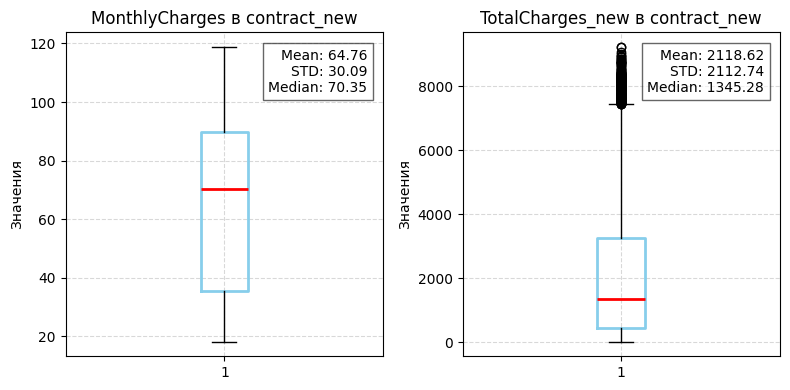

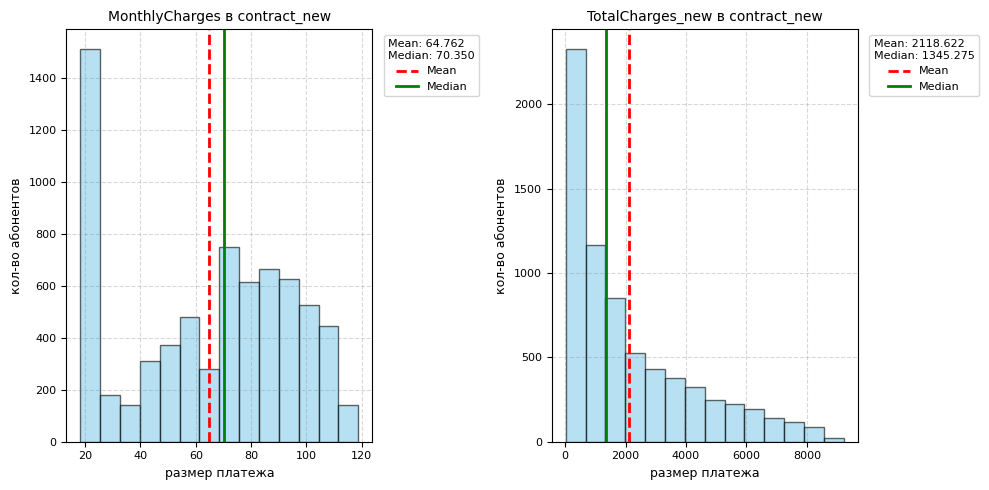

In [43]:
#построим боксплоты для количественных признаков
num_col = contract_new.select_dtypes(include='float').columns.to_list()
datasets = [
    (contract_new, num_col, 'contract_new')
]

for df, cols, name in datasets:
    plot_boxplots(df, cols, name, plot_size=(4,4), n_cols=2)

# построим гистограммы для признаков TotalCharges_new и MonthlyCharges
datasets = [contract_new]
names = ['contract_new']
cols = [num_col]

plot_multiple_histograms(
    dataframes_list=datasets,
    columns_list=cols,
    dataset_names_list=names,
    figsize=(10, 5),
    title_fontsize=10,
    axis_fontsize=9,
    ylabel_name = 'кол-во абонентов',
    xlabel_name = 'размер платежа',
    tick_fontsize=8,
    bar_color='skyblue',
    grid_color='grey',
    n_cols=2)  

**Вывод о данных на основе анализа расходов абонентов:**

**признак `MonthlyCharges`(расходы абонента за месяц)**

- среднее значение признака `MonthlyCharges` - 64.762
- медиана признака `MonthlyCharges` - 70.350
- минимальное значение признака `MonthlyCharges` - 18.250
- максимальное значение признака `MonthlyCharges` - 118.750

В месяц абоненты «ТелеДома» платят от `18.250` до `118.750` рублей в месяц. Средняя месячная плата составляет - `64.762` рубля, медиана месячного платежа - `70.350`. Распределение незначительно смещено влево, так как медиана выше среднего. 

Половина всех клиентов платит от `35.5` до `89.85` рублей в месяц. Расброс данных большой, заметна доля клиентов с низкими ежемесячными платежами. Большие чеки связаны с дополнительными услугами(проверим это отдельно).

**признак `TotalCharges_new`(общие расходы абонента)**

- среднее значение признака `TotalCharges_new` - 2118.622
- медиана значений признака `TotalCharges_new` - 1345.275
- минимальное значение признака `TotalCharges_new` - 19.050
- максимальное значение признака `TotalCharges_new` - 9221.380
- есть группа договорова с очень большими общими чеками(общие расходы выше 7500)

1. Общие расходы абонентов «ТелеДома» составляют от `19.050` до `9221.380` рублей. Среднее значение общих расходов - `2118.622` рубля, медиана составлет `1345.275`. Общие расходы у половины клиентов составляют от `439.745` до `3239.318` рублей(разница почти в 7 раз!). Разброс данных очень большой, распределение заметно смещено вправо(среднее заметно больше медианы). Есть клиенты с очень большими расходами (у 25%  суммарные расходы  > `3239.318`), они тянут среднее значения вверх.

2. Дорогоры по общим платежам разбиваются на три основные группы: договоры с маленьким чеком(менее `3000`), договоры со средним чеком(`3000–7500`), и договоры с больши чеком(свыше `7500`)

3. Клиенты с низкими общими расходами (min -`19.050`) вероятно новые абоненты. Значение их суммарных расходов сопоставимо с минимальным значением ежемесячного платежа(`18.250`).

Чтобы учесть выявленные закономерности, можно создать новые признаки: 

- `avg_monthly` - средний месячный платеж(`TotalCharges_new`/`duration`)
- `trend_monthly` - отклонение среднего месячного платежа от текущего месячного платежа(`MonthlyCharges` - `avg_monthly`)
- признак `trend_сharges` - с категориями динамики ежемесячных платежей(упали, стабильные, выросли)
- признак `pred_total` - предсказанные общие платежи (`MonthlyCharges`*`duration`)
- признак `total_diff`- разница между текущими общими платежами и предсказанными(`TotalCharges_new` - `MonthlyCharges`*`duration`)

Проверим нашу гипотезу о том, что низкие общие расходы у новых абонентов. Создадим новый признак, содержащий информацию о длительности действующих договоров. Учтем, что информация в договорах актуальна на 1 февраля 2020 года. 

In [46]:
# возьмем дату последнего обновления данных
# известно, что информация о договорах актуальна на 1 февраля 2020 года
cutoff_date = pd.to_datetime("2020-02-01")

# подсчитаем длительность в месяцах 
contract_new['duration'] = ((contract_new['EndDate_filled'] - contract_new['BeginDate_new'])
                          .dt.days)
# выведем на экран первые пять значений нового признака duration(длительность договора)
print("Первые пять значений нового признака duration(длительность договора в днях): ")
display(contract_new['duration'].head())
print(f"\nМинимальная длительность договора: {contract_new['duration'].min()} месяцев. Максимальная длительность договора: {contract_new['duration'].max()} месяцев")

Первые пять значений нового признака duration(длительность договора в днях): 


0      31
1    1036
2     123
3    1371
4     153
Name: duration, dtype: int64


Минимальная длительность договора: 0 месяцев. Максимальная длительность договора: 2314 месяцев


Посмотрим на распределение длительности договоров с оператором.

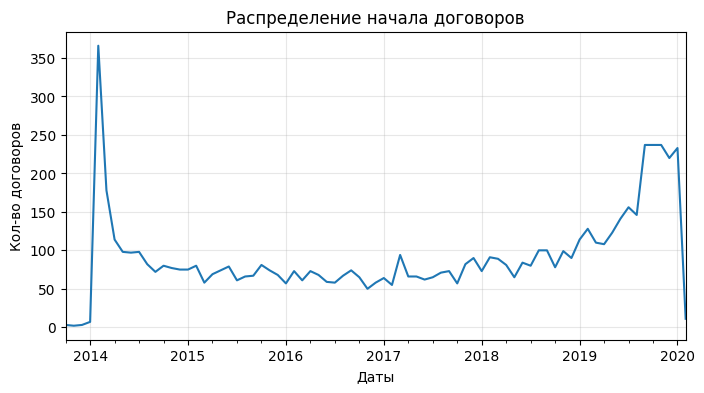

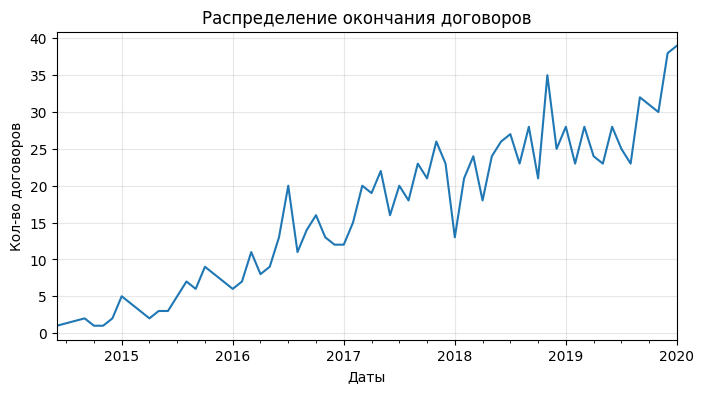

In [48]:
# посмотрим распределение длительности договоров с оператором
plt.figure(figsize=(8,4))
contract_new['BeginDate_new'].dt.to_period("M").value_counts().sort_index().plot(kind="line")
plt.title("Распределение начала договоров")
plt.xlabel("Даты")
plt.ylabel("Кол-во договоров")
plt.grid(True, alpha=0.3)
plt.show()

# посмотрим распределение длительности договоров с оператором
# для визуализации используем признак с незаполненными NaT(просто удалим пропуски)
plt.figure(figsize=(8,4))
contract_new['EndDate_new'].dropna().dt.to_period("M").value_counts().sort_index().plot(kind="line") 
plt.title("Распределение окончания договоров")
plt.xlabel("Даты")
plt.ylabel("Кол-во договоров")
plt.grid(True, alpha=0.3)
plt.show()

**Вывод на основе анализа распределения договоров по датам их начала:** 

- на графике виден резкий пик в 2014 году, это говорит о притоке клиентов(причины могут быть самые разные: активное продвижение на рынке, старт бизнеса, особенности предоставленных данных)
- после 2015 года количество новых договоров снижается и стабилизируется между 50-100 договоров
- в конце 2019 года снова виден рост(причина роста также может быть связана с разными факторами: от особеноостей предоставленных данных, до активной рекламной компании)
  
У оператор связи «ТелеДом» были периоды активного роста клиентской базы (2014 год и 2019 год), а в промежутке - стабильный скромнй приток клиентов. 

**Вывод на основе анализа распределения договоров по датам их окончания:** 

- на графике хорошо заметна тенденция роста числа расторгнутых договоров с 2015 по 2019 годы. Вероятно, заглюченные ранее договоры заканчиваются и клиенты уходят
- колебания на графике могут также показывать, что клиенты заключали договоры с фиксированным сроком (в наших данных об этом косвенно свидетельствует признак `Type`, хранящий данные о типах оплаты договора (раз в год, раз в два года или ежемесячно).

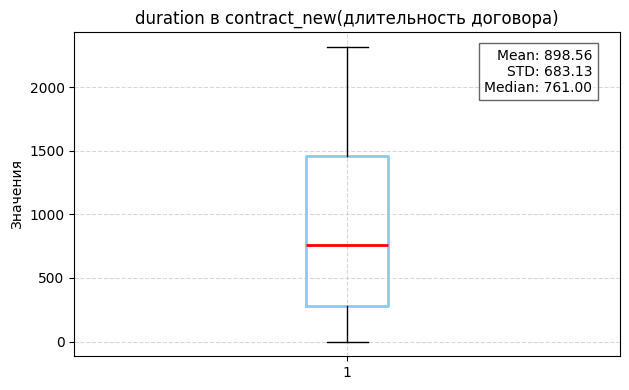

In [50]:
# построим боксплот для признака duration(длительность договора)
plot_boxplots(
    data=contract_new,
    columns=['duration'],
    dataset_name='contract_new(длительность договора)'
)

Дополнительно оценим числовые характеристики признака `duration`.

In [52]:
# посмотрим числовые характеристики признака duration
contract_new['duration'].describe()

count   7043.000
mean     898.556
std      683.131
min        0.000
25%      276.000
50%      761.000
75%     1461.000
max     2314.000
Name: duration, dtype: float64

**Вывод на основе анализа длительности договоров:**

- средняя длительность договора: `898 дней`
- медиана длительности договора: `761 день`. 
- стандартное отклонение очень большое - `683 дней`
- `50%` клиентов не расторгают договор от `276–1461` дней
- минимальная длительность договора - `0 дней` (это мли есть клиенты, которые заключили договор и сразу расторгли или особенности данных)
- максимальная длительность договора - `2314 дней` — это верхняя граница, привязанныя к дате среза (01.02.2020). Это самые лояльные клиенты.

Разброс длительности договоров очень большой. Много коротких договоров (абоненты уходят в первые месяцы), но есть и лояльные клиенты, не расторгающие договор годами. 

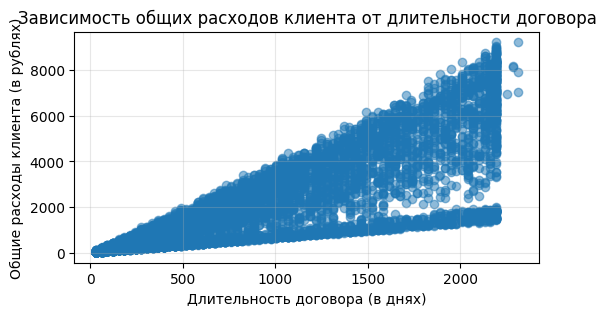

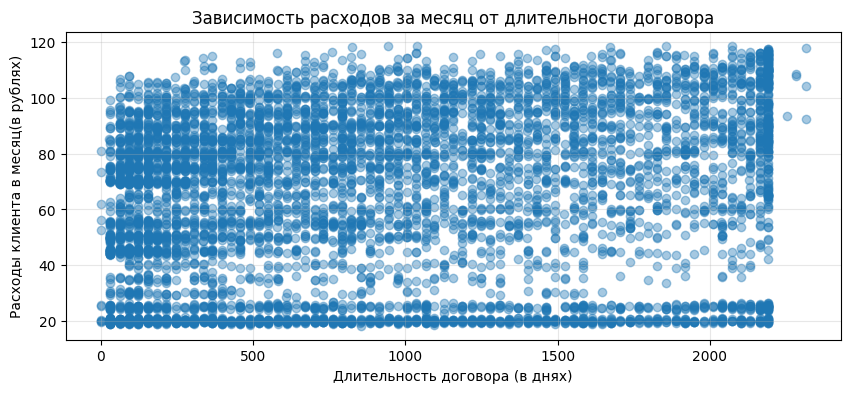

In [54]:
# отрисуем scatterplot для оценки связи между длительностью договора/общих расходов клиента
plt.figure(figsize=(6,3))
plt.scatter(contract_new['duration'], contract_new['TotalCharges_new'], alpha=0.5)
plt.title("Зависимость общих расходов клиента от длительности договора")
plt.xlabel("Длительность договора (в днях)")
plt.ylabel("Общие расходы клиента (в рублях)")
plt.grid(True, alpha=0.3)
plt.show()

# отрисуем scatterplot для длительности договора/расходов клиента в месяц
plt.figure(figsize=(10,4))
plt.scatter(contract_new['duration'], contract_new['MonthlyCharges'], alpha=0.4)
plt.title("Зависимость расходов за месяц от длительности договора")
plt.xlabel("Длительность договора (в днях)")
plt.ylabel("Расходы клиента в месяц(в рублях)")
plt.grid(True, alpha=0.3)
plt.show()

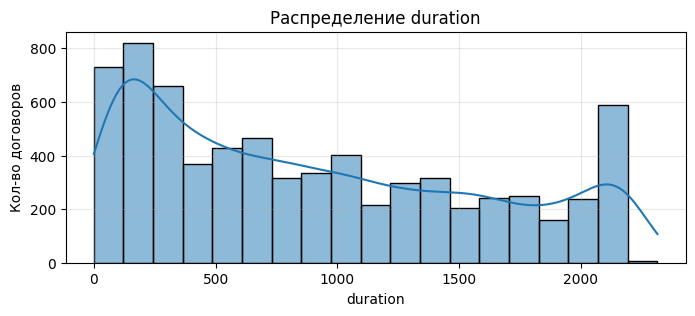

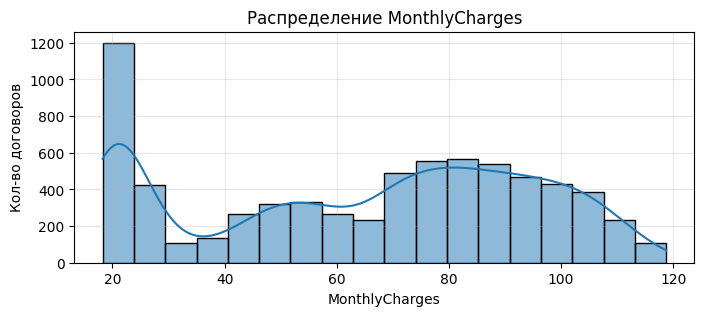

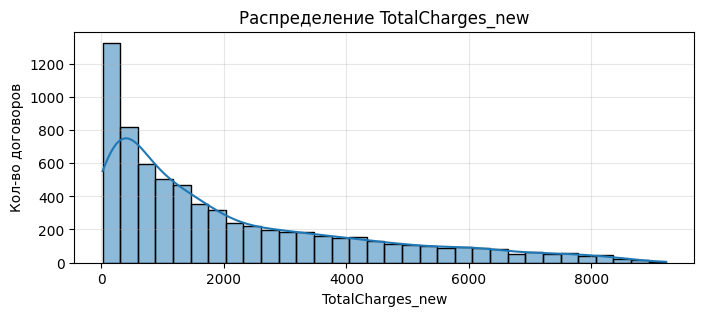

In [55]:
num_cols = ["duration", 'MonthlyCharges', 'TotalCharges_new']
for col in num_cols: 
    plt.figure(figsize=(8,3))
    plt.title("Распределение {}".format(col))
    ax = sns.histplot(contract_new[col], kde=True)
    plt.xlabel(col)
    plt.ylabel("Кол-во договоров")
    plt.grid(True, alpha=0.3)
    plt.show()

**Выводы на основе анализа зависимости общих расходов клиента от длительности договора:**

- на графике видно четкую линейную зависимость, что логично, ведь чем дольше длится контракт, тем выше суммарные расходы клиента (общие расходы ~ расходы за месяц × число месяцев)
- что общие расходы заметнее растут у клиентов, чьи ежемесячные траты выше

Длительность договора напрямую влияет на общую сумму, зависимость почти линейная. Отличия объясняются разными тарифами (разброс у ежемесячный платежей, как мы оценили ранее, довольно большой: от 18.250 до 118.750  рублей)

**Выводы на основе анализа зависимости ежемесячных расходов клиента от длительности договора:**

- заметны единичные наблюдения с самой большой длительностью договора и высокими ежемесячными платежами (> 90)
- чем долшье клиент в компании, тем выше у него ежемесячные расходы(подключает доп услуги)
- видно отдельную группу договоров с длительностью > 2000 дней
- видно небольшое скопление у нижних значений. Вероятно, это говорит о том,  что часть клиентов выбирает минимальный тариф и остается на нем весь договор.
- наблюдения (особенно в течение первого года) разделяются по группам. Видно три плотных группы с промежутками между ними(промежуточные группы, вероятно - тариф+допфункции).

**Можно выделить три основнее группы тарифов:**
   - низкие ежемесячные платежи - <=25
   - базовые ежемесячные платежи - 40-60
   - высокие ежемесячные платежи - >70 

Построим график для бинарного категориального признака `PaperlessBilling`(получает ли абонент электронный расчётный лист) датафрейма `contract_new`. Используем для построения графиков кастомную функцию `plot_cat`.

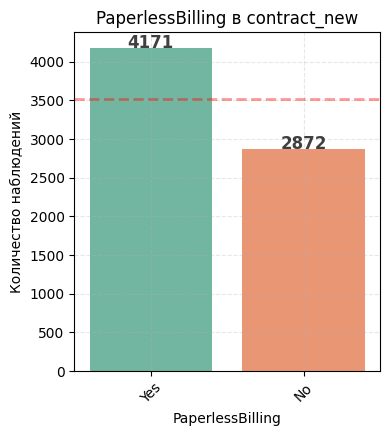

In [58]:
# построим графики для бинарного категориального признака PaperlessBilling датафрейма contract_new
plot_cat(data=contract_new, columns=['PaperlessBilling'], dataset_name='contract_new', n_cols=1)

- опция `PaperlessBilling` подключена у 4171 клиента, это 60% всех договоров

Это важный признак. Выставление электронных счетов предполагает, что клиенту сообщают о необходимости оплаты (через их электронную почту или онлайн-аккаунт). Такие счета оплачивают обычно быстрее, чем бумажные платежки. В теории это может сократить ко-во просроченных платежей, сделать взаимодействие с клиентом комфортнее. Интересно посмотреть, как связан `PaymentMethod` и `PaperlessBilling`, и как это вляиет на лояльность клиента(остается/уходит).

Построим с помощью кастомной функции `bar_cat` графики (barplot) для категориальных признаков `Type`(тип оплаты) и `PaymentMethod`(тип платежа).

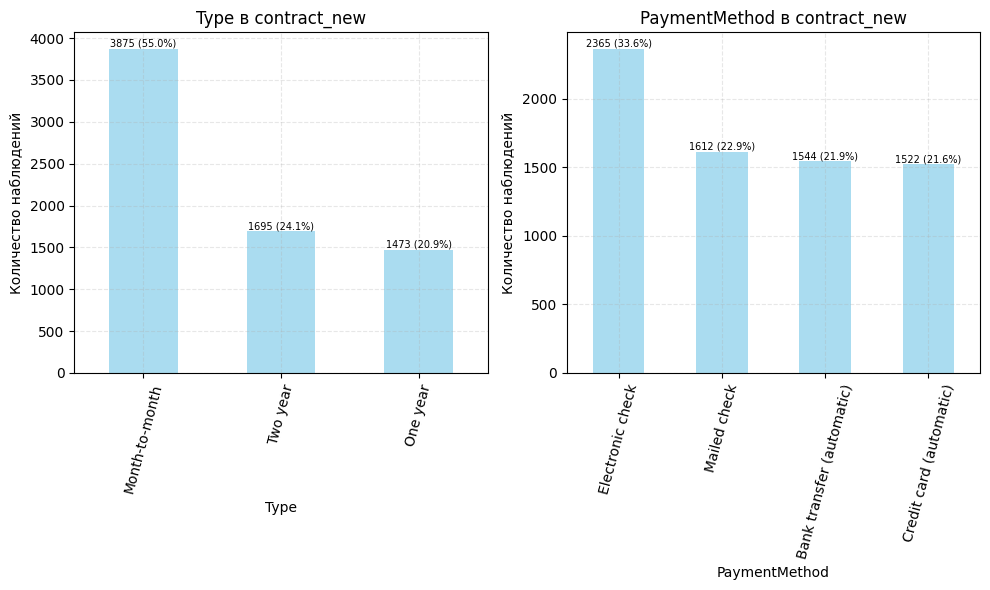

In [61]:
# построим график для категориального признака Type
bar_cat(contract_new, ['Type', 'PaymentMethod'], "contract_new", n_cols=2, annotation_fontsize=7)

**Вывод на основе анализа категориальных признаков:** 

**`PaperlessBilling`(получает ли абонент электронный расчетный лист)**:
- 4171 абонент (~59%) из 7043 абонентов получает электронный расчётный лист
- 2872 абонентов (~41%) из 7043 абонентов не получают электронный расчётный лист

**`Type`(тип оплаты)**:
- 3875 (55%) абонентов оплачивают договор раз в месяц
- 1695 (24.1%) абонентов оплачивают договор сразу за 2 года
- 1473 (20.9%) абонента оплачивают договор сразу за год

**`PaymentMethod`(тип платежа)**:
- у 2365 (33.6%) абонентов тип платежа - `Electronic check`
- у 1612 (22.9%) абонентов тип платежа - `Mailed check`
- у 1544 (21.9%)абонентов тип платежа - `Bank transfer (automatic)`
- у 1522 (21.6%) абонентов тип платежа - `Credit card (automatic)`

1. У половины абонентов (55%) договор с ежемесячной оплатой. Косвенно это может говорить о том, что эти клиенты находятся в зоне риска(могут расторгнуть договор), но чтобы утверждать это у нас пока мало данных.

2. Больше половины абонентов (~59%) получают электронный расчетный лист. 

Это важный признак. Выставление электронных счетов предполагает, что клиенту сообщают о необходимости оплаты (через их электронную почту или онлайн-аккаунт). Такие счета оплачивают обычно быстрее, чем бумажные платежки. В теории это может сократить ко-во просроченных платежей, сделать взаимодействие с клиентом комфортнее. Интересно посмотреть, как связан PaymentMethod и PaperlessBilling, и как это вляиет на лояльность клиента(остается/уходит)

3. Самые популярные типы платежа у абонентов `Electronic check`(33.6%), у остальных типов платежей - от 22 до 23%. Важно посмотреть, как влияет на лояльность клиента автоматическая оплата счета(`Bank transfer (automatic)`/`Credit card (automatic)`).

Посмотрим на распределения признака `is_active`(1-договор активен, 0-завершен).

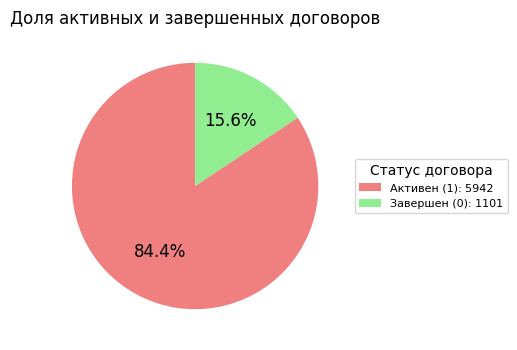

In [64]:
# отрисуем pie chart для целевого признака is_active
# подсчитаем распределение, чтобы вывести на графике
counts = contract_new['is_active'].value_counts()
labels = ['Активен (1)','Завершен (0)']
colors = ['lightcoral', 'lightgreen']

plt.figure(figsize=(4,4))
wedges, texts, autotexts = plt.pie(
    counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12}
)

# добавим легенду с абослютными значениями на график 
plt.legend(
    wedges,
    [f"{label}: {count}" for label, count in zip(labels, counts)],
    title="Статус договора",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=8
)

plt.title("Доля активных и завершенных договоров")
plt.show()

**Вывод на основе анализа доли активных и завершенных договоров:** 

 - 84.4% договоров (5942 из 7043) активно
 - завершенных договоров всего 15.6% (1101 из 7043 договоров)

Есть дисбаласн в классах целевой переменной.

Анализ данных об активных договорах говорит о том, что клиенты нечасто расторгают договор. 

**Вывод на основе EDA и предобработки признаков датасета `contract_new`, содержащего информацию о договоре:**

-----

1. Проверили данные на пропуски:
   - явных пропусков не обнаружили, но нашли 'невидимые' строки(состоящие только из пробелов) среди значений признака `TotalCharges`
3. Проверили корректность определения типов данных и исправили ошибки:
   - привели значения признака `TotalCharges` к типу данных `float` с учетом обнаруженных 'невидимых' строк
   - привели значения признака `BeginDate` и `EndDate` к типу данных `datetime`
4. Проверили данные на полные дубликаты:
   - полных дубликатов в данных не нашли;
5. Проверили уникальные значения категориальных признаков:
   - явных проблем не выявили
6. заполнили пропуски в `EndDate` после приведения к типу данных `datetime`. Пропуски возникли из-за того, что в `EndDate` действующие договоры маркировались заглушкой `No`. Пропуски заполнили датой `2020-02-01` (по информации от заказчика информация о договорах актуальна на 1 февраля 2020 года)
7. Создали новые признаки:
   - `is_active`(1-договор активен, 0-завершен) - это бинарный признак, который содержит информацию о том, действует или завершен договор с клиентом. `is_active` мы выделили из признака `EndDate`, содержащего данные о датах окончания действия договора. Чтобы определить действующие договоры, мы использовали особенности предоставленных данных: незавершенные договоры в `EndDate` были помечены `No`.
   - `duration` - этот признак хранит информацию о сроке договора. Информацию мы получили из разности признаков `BeginDate` и `EndDate`, хранящих информацию о начале и окончании договора.

**В ходе исследовательского анализа данных выявили особенности поведения абонентов:**
1.  `~59%`абонентов получает электронный расчетный лист
2. `84.4%` договоров (5942 из 7043) активны. Завершенных договоров всего `15.6%` (1101 из 7043);
3. рост числа расторгнутых договоров зафиксирован с 2015 по 2019 год;
4.  у оператора связи «ТелеДом» были периоды активного роста клиентской базы (2014 год и 2019 год), а в промежутке - стабильный скромный приток клиентов;
5.  разброс длительности договоров очень большой. Много коротких договоров, но есть и лояльные клиенты, не расторгающие договор годами: средняя длительность договора: `898 дней`, `50%` клиентов не расторгают договор в диапазоне от `276–1461` дней, максимальная длительность договора - `2314 дней`.
6.  в месяц абоненты «ТелеДома» платят от `18.250` до `118.750` рублей. Средняя месячная плата составляет - `64.762` рубля, медиана месячного платежа - `70.350`. Половина всех клиентов платит от `35.5` до `89.85` рублей в месяц. Расброс данных большой, заметна доля клиентов с низкими ежемесячными платежами. Большие чеки веротяно связаны с дополнительными услугами(проверим это отдельно);
7.  общие расходы абонентов «ТелеДома» составляют от `19.050` до `9221.380` рублей. Среднее значение общих расходов - `2118.622` рубля, медиана составлет `1345.275`. Общие расходы у половины клиентов составляют от `439.745` до `3239.318` рублей(разница почти в 7 раз!). Разброс данных очень большой. Есть клиенты с очень большими расходами (у `25%`  суммарные расходы  > `3239.318`), они тянут среднее значения вверх. Клиенты с низкими общими расходами (min -`19.050`) вероятно новые абоненты. Значение их суммарных расходов сопоставимо с минимальным значением ежемесячного платежа(`18.250`);
8. договоры по ежемесячным платежам можно условно разделить на три плотных группы (низкие ежемесячные платежи - <=25, базовые ежемесячные платежи - 40-60, высокие ежемесячные платежи - >70 ). Между этими группами есть наблюдения - это веротяно договоры с базовым тарифов + доп услуги 
9.  длительность договора напрямую влияет на общие расходы абонентов, зависимость почти линейная. Незначительные колебания объясняются разными тарифами (разброс у ежемесячный платежей довольно большой: от `18.250` до `118.750`  рублей;
10. у половины абонентов (`55%` или `3875` клиентов) договор с ежемесячной оплатой. У `1695` (`24.1%`) абонентов тип оплаты `Two year`. У `1473` (`20.9%`) абонентовтип оплаты `One year`;
11. Больше половины абонентов (~59%) получают электронный расчетный лист.
Это важный признак. Выставление электронных счетов предполагает, что клиенту сообщают о необходимости оплаты (через их электронную почту или онлайн-аккаунт). Такие счета оплачивают обычно быстрее, чем бумажные платежки. В теории это может сократить ко-во просроченных платежей, сделать взаимодействие с клиентом комфортнее. Интересно посмотреть, как связан `PaymentMethod` и `PaperlessBilling`, и как это вляиет на лояльность клиента(остается/уходит)
12. Самые популярные типы платежа у абонентов `Electronic check`(33.6%), у остальных типов платежей - от 22 до 23%. Важно посмотреть, как влияет на лояльность клиента автоматическая оплата счета(`Bank transfer`(automatic)/`Credit card`(automatic))

**С учетом обнаруженных закономерностей стоит создать новые признаки:**
- `avg_monthly` - средний месячный платеж(`TotalCharges_new`/`duration`)
- `trend_month` - отклонение среднего месячного платежа от текущего месячного платежа(`MonthlyCharges` - `avg_monthly`)
- `trend_ratio` - отношения `MonthlyCharges` к `avg_monthly`(средний ежемесячный платеж)
- `trend_groups` - с категориями динамики ежемесячных платежей(упали, стабильные, выросли)
- `pred_total` - предсказанные общие платежи (`MonthlyCharges`*`duration`)
- `total_diff`- разница между текущими общими платежами и предсказанными(`TotalCharges_new` - `MonthlyCharges`*`duration`)

#### EDA признаков датасета `personal_new`, содержащего персональные данные клиента

In [69]:
#выведем первые пять строк датасета personal_new
personal_new.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


Посмотрим, у скольких абонентов есть статус пенсионер(признак `SeniorCitizen`).

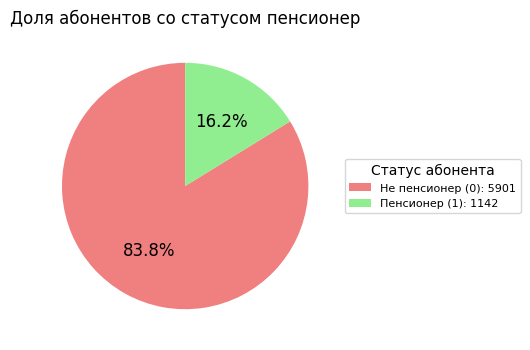

In [71]:
# отрисуем pie chart для признака SeniorCitizen
# подсчитаем распределение, чтобы вывести на графике
counts = personal_new['SeniorCitizen'].value_counts()
labels = ['Не пенсионер (0)', 'Пенсионер (1)']
colors = ['lightcoral', 'lightgreen']

plt.figure(figsize=(4,4))
wedges, texts, autotexts = plt.pie(
    counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12}
)

# добавим легенду с абослютными значениями на график 
plt.legend(
    wedges,
    [f"{label}: {count}" for label, count in zip(labels, counts)],
    title="Статус абонента",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=8
)

plt.title("Доля абонентов со статусом пенсионер")
plt.show()

-  лишь у 16.2% абонентов есть статус пенсионер(1142 абонента из 7043)

Построим графики для категориальных признаков датасета `personal_new`. Используем для построения графиков кастомную функцию `plot_cat`.

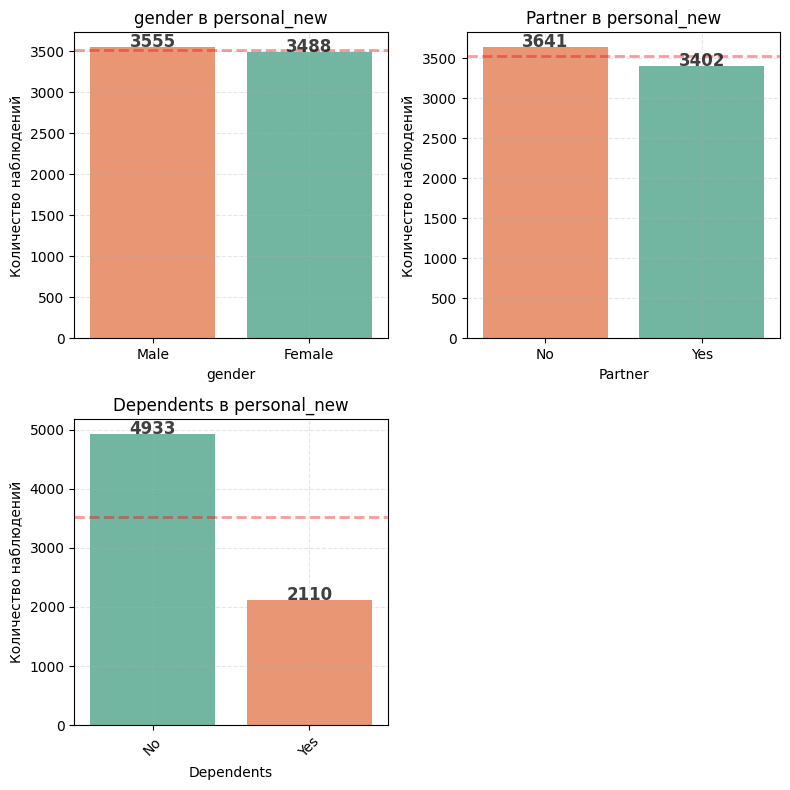

In [74]:
# построим графики для категориальных признаков датасета  personal_new
binary_cat = personal_new.drop(columns=['SeniorCitizen', 'customerID']).columns.tolist()

plot_cat(data=personal_new, columns=binary_cat, dataset_name='personal_new')

**Вывод на основе анализа бинарных категориальных признаков датасета `personal_ new`:**

1. признак `gender`(пол):
   - абоненты по признаку `gender` распределены почти равномерно(`3555` мужчин, `3488` женщин)
2. признак `Partner`(есть ли у абонента супруг или супруга):
   - абоненты по признаку `Partner` распределены почти поровну с небольшим перевесом в сторону абонентов, у которых нет партнера - у `3641` абонента нет партнера, а у `3402` есть партнер
3. признак `Dependents`(есть ли у абонента дети):
   - у `70%` абонентов(`4933` человека) есть дети, у `30%` детей нет(`2110` абонентов).

**Вывод на основе EDA признаков датасета `personal_new`, содержащего персональные данные клиента**

---

В датасета `personal_new` содержатся персональные данные клиентов. У среднестатистического абонента оператора связи «ТелеДом» есть дети, есть партнер и нет статуса пенсионера: 
- абоненты по гендеру распределены почти равномерно(3555 мужчин, 3488 женщин)
- по наличию партнеров абоненты распределены почти поровну  - у 3641 абонента нет партнера, а у 3402 есть партнер
- у 70% абонентов(4933 человека) есть дети, у 30% детей нет(2110 абонентов)
- лишь у 16.2% абонентов есть статус пенсионер(1142 абонента из 7043)

#### EDA признаков датасета `internet_new`, содержащего информацию об интернет-услугах

In [78]:
#выведем первые пять строк датасета internet_new
internet_new.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


Построим графики для бинарных категориальных признаков датасета `internet_new`. Используем для построения графиков кастомную функцию `plot_cat`.

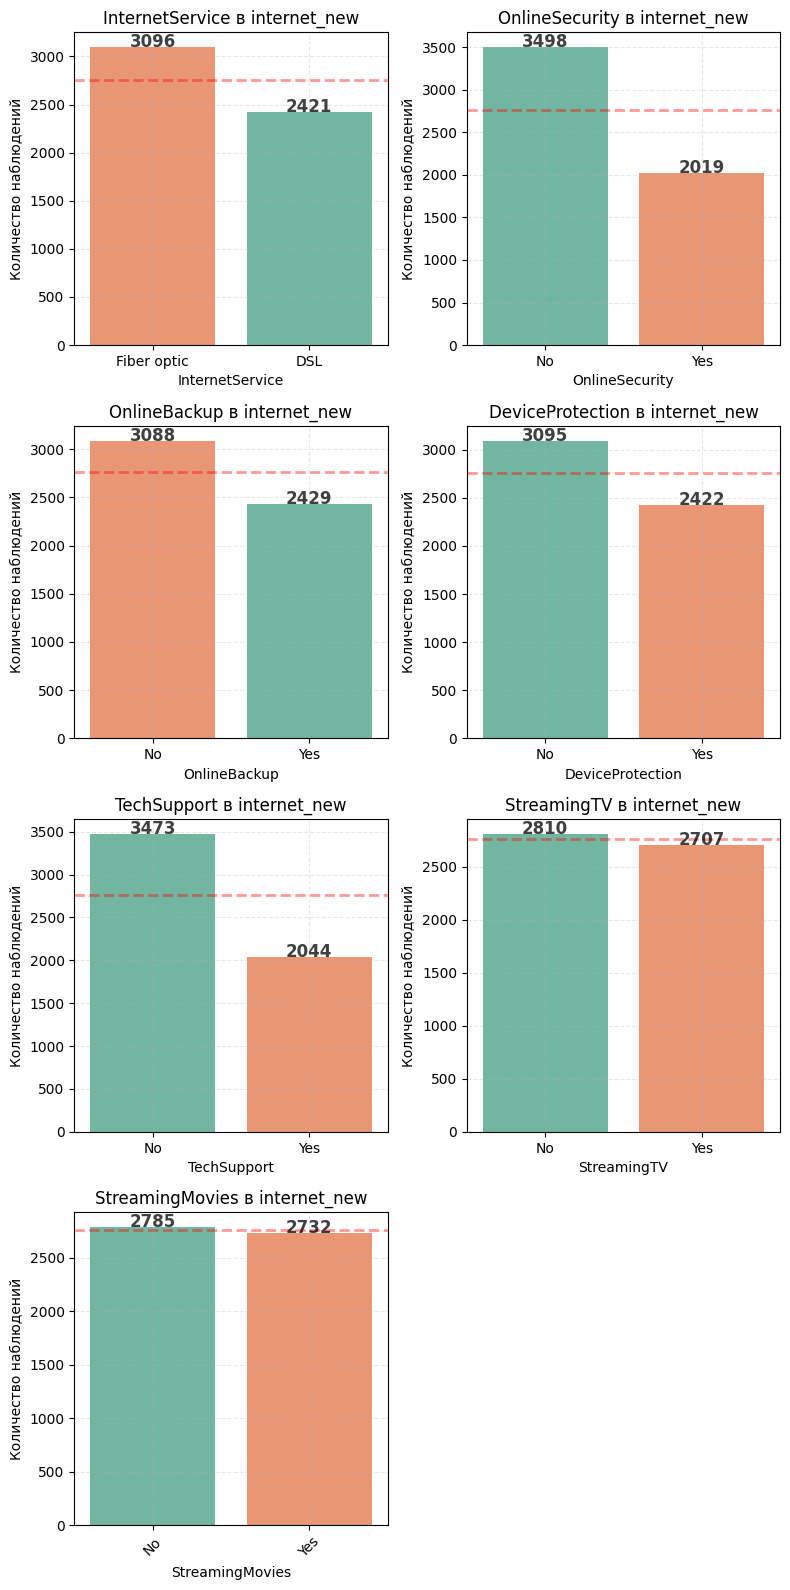

In [80]:
# построим графики для категориальных признаков датасета internet_new
binary_cat = internet_new.drop(columns=['customerID']).columns.tolist()

plot_cat(data=internet_new, columns=binary_cat, dataset_name='internet_new')

По информации из [открытых источников](https://ya.ru/neurum/c/tehnologii/q/v_chem_raznica_mezhdu_fiber_i_dsl_internet_cf207998?ysclid=mg3icpnvsl561115680), у Fiber optic(оптоволоконная связь) есть ряд преимуществ перед DSL(цифровая абонентская линия): 
- `Fiber optic`: стабильный быстрый интернет, идеально для стриминга видео с высоким разрешением, онлайн-игр, поддержка множества устройст
- `DSL` - скорость ниже и может падать из-за помех, не справляется со стримингом с высоким разрешением

Это стоит учесть, так как тип интернет-подключения (`Fiber optic` и `DSL`) влияет на стоимость тарифа(можно подключить много доп услуг), и на удовлетворенность пользователя услугой(качество соединения и тд).

**Вывод на основе анализа признаков датасета `internet_new`, содержащего информацию об интернет-услугах:**

-----

Информация о дополнительных услугах есть только для 5517 из 7043 абонентов

1. признак **`InternetService`**(тип подключения: через телефонную линию (DSL, от англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (Fiber optic):
   - информация об услуге `InternetService` есть для 
   - у `3096` абонентов абонентов тип подключения `Fiber optic`
   - у `2421` абонентов тип подключения `DSL`
3. признак **`OnlineSecurity`**(блокировка небезопасных сайтов):
   - у `3498` абонентов не подключена услуга
   - у `2019` абонентов услуга блокировка небезопасных сайтов подключена
4. признак **`DeviceProtection`**(антивирус):
   - у `3095` не подключена услуга
   - у `2422` абонентов услуга антивирус подключена
5. признак **`OnlineBackup`**(облачное хранилище файлов для резервного копирования данных):
   - у `3088` абонентов услуга не подключена
   - у `2429` абонентов услуга подключена
6. признак **`TechSupport`**(выделенная линия технической поддержки):
   - у `3473` абонентов услуга не подключена
   - у `2044` абонентов подключена услуга выделенная линия технической поддержки
7. признак **`StreamingTV`**(стриминговое телевидение):
   - у `2810` абоненентов услуга не подключена
   - у `2707` абонентов услуга подключена
   - `StreamingTV` - на втором месте по популярности среди дополнительных услуг
8. признак **`StreamingMovies`**(каталог фильмов):
   - у 2785 абонентов услуга не подключена
   - у 2732 абонентов услуга подключена
   - `StreamingMovies` - самая популярная у абонентов допуслуга

Самыми популярными дополнительными услугами у абонентов оператора связи «ТелеДом» являются стриминговое телевидение(`StreamingTV`) и каталог фильмов(`StreamingMovies`). Самыми непопулярными услугами у абонентов можно считать `OnlineSecurity`(блокировка небезопасных сайтов подключена у 2019 абонентов) и `TechSupport`(выделенная линия технической поддержки подключена у 2044 абонентов).

В данных есть информация только о 5517 из 7043 абонентов. 

В дальнейшей работе стоит учесть, что тип интернет-подключения (`Fiber optic` и `DSL`) может сильно влиять на размер тарифа(можно подключить много доп услуг), и на удовлетворенность пользователя услугой(качество соединения и тд).

**Стоит создать признаки признаки:**
- содержащий информацию о том, подключены ли у абонента интернет-сервисы
- признак со счетчиком подключенных интернет-сервисов (0-6)

#### EDA признаков датасета `phone_new`, содержащего информацию об услугах телефонии

In [84]:
#выведем первые пять строк датасета internet_new
phone_new.head()

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


Построим график для бинарного категориального признака датасета `phone_new`. Используем для построения графиков кастомную функцию `plot_cat`.

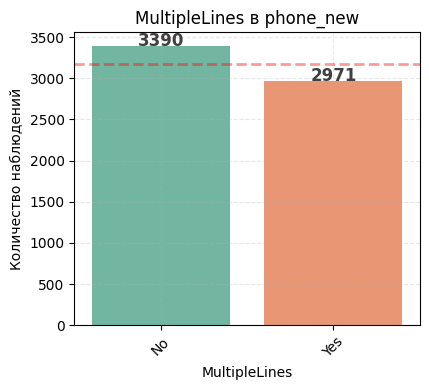

In [86]:
# построим график для бинарного категориального признака датасета phone_new
binary_cat = phone_new.drop(columns=['customerID']).columns.tolist()

plot_cat(data=phone_new, columns=binary_cat, dataset_name='phone_new')

**Вывод на основе анализа признаков датасета `phone_new`, содержащего информацию об услугах телефонии:**

Датасет `phone_new` содержит 6361 наблюдений. 

1. признак `MultipleLines`(подключение телефона к нескольким линиям одновременно):
   - у 3390 абонентов нет подключения телефона к нескольким линиям одновременно
   - 2971 абонентов услуга подключена

Рапределение почти равномерное. 

2. Нужно создать признак `has_phone` с информацией о том, подключена ли убонента стационарная телефонная связь.

### Общий вывод по итогам предобработки и исследования данных



-----

Заказчик предоставил нам данные в четырех файлах. В датасетах `contract_new`(информация о договоре) и `personal_new`(персональные данные клиента) содержится `7043` записей, в датасете `internet_new`(информация об интернет-услугах) - `5517` записей, а в `phone_new`(информация об услугах телефонии) - `6361` запись. Во всех четырех датасетах есть столбец `customerID`, который содержит уникальный код клиента.

**В ходе предобработки исправили**:
- нашли "невидимые строки"(содержащие пробелы) в признаке `TotalCharges`, а затем привели признак к корректному типу данных `float`
- привели к типу данных datetime признаки `EndDate` и `BeginDate`
- заполнили в `EndDate` пропуски, образовавшиеся после приведения признака к типу datetime. Использовали для заполнения пропусков дату среза(янформация о договорах актуальна на 1 февраля 2020 года)

**В ходе предобработки создали новые признаки**: 
- `is_active` (1-договор активен, 0-договор завершен). Признак выделили из `EndDate`. Незавершенные в `EndDate`договоры были помечены заглушкой `No`
- `duration`(длительность договора в месяцах). Признак получили из разности между началом договора(`BeginDate`) и окончанием договора(`EndDate`)

**В ходе предобработки определили таргет**
- определили таргет в нашей задаче - `is_active`(1-договор активен, 0-договор завершен)

**Какие признаки создать после объединения данных**:
- `avg_monthly` - средний месячный платеж(`TotalCharges_new`/`duration`)
- `trend_month` - отклонение среднего месячного платежа от текущего месячного платежа(`MonthlyCharges` - `avg_monthly`)
- `trend_ratio` - отношения `MonthlyCharges` к `avg_monthly`(средний ежемесячный платеж)
- `trend_groups` - с категориями динамики ежемесячных платежей(упали, стабильные, выросли)
- `pred_total` - предсказанные общие платежи (`MonthlyCharges`*`duration`)
- `total_diff`- разница между текущими общими платежами и предсказанными(`TotalCharges_new` - `MonthlyCharges`*`duration`)
- `has_phone` - подключена ли абонента стационарная телефонная связь
- `has_internet` - подключен ли абонента интернет

**Итоги предварительного EDA:**

1. **`contract_new`**:
- датасет `contract_new` содержит `7043` наблюдений
- `~59%`абонентов получает электронный расчетный лист
- `84.4%` договоров активны. Завершенных договоров всего `15.6%` (1101 из 7043);
- разброс длительности договоров очень большой. Много коротких договоров, но есть и лояльные клиенты, не расторгающие договор годами: средняя длительность договора: `898 дней`, `50%` клиентов не расторгают договор в диапазоне от `276–1461 дней`, максимальная длительность договора - `2314 дней`.
- в месяц абоненты «ТелеДома» платят от `18.250` до `118.750` рублей. Средняя месячная плата составляет - `64.762`, медиана месячного платежа - `70.350`. Половина всех клиентов платит от `35.5` до `89.85` в месяц. Расброс данных большой, заметна доля клиентов с низкими ежемесячными платежами. Большие чеки веротяно связаны с дополнительными услугами(проверим это отдельно);
- общие расходы абонентов «ТелеДома» составляют от `19.050` до `9221.380`. Среднее значение общих расходов - `2118.622`, медиана составлет `1345.275`. Общие расходы у половины клиентов составляют от `439.745` до `3239.318` (разница почти в 7 раз!). Разброс данных очень большой. Есть клиенты с очень большими расходами (у `25%`  суммарные расходы  > `3239.318`), они тянут среднее значения вверх. Клиенты с низкими общими расходами (min -`19.050`) вероятно новые абоненты. Значение их суммарных расходов сопоставимо с минимальным значением ежемесячного платежа(`18.250`);
- длительность договора напрямую влияет на общие расходы абонентов, зависимость почти линейная. Незначительные колебания объясняются разными тарифами (разброс у ежемесячный платежей довольно большой: от `18.250` до `118.750`  рублей;
- у половины абонентов (`55%` или `3875` клиентов) договор с ежемесячной оплатой. У `1695` (`24.1%`) абонентов тип оплаты `Two year`. У `1473` (`20.9%`) абонентовтип оплаты `One year`;
- Больше половины абонентов (~59%) получают электронный расчетный лист.

12. Самые популярные типы платежа у абонентов `Electronic check`(33.6%), у остальных типов платежей - от 22 до 23%. Важно посмотреть, как влияет на лояльность клиента автоматическая оплата счета(`Bank transfer`(automatic)/`Credit card`(automatic))

2. **`internet_new`**:
 - датасет `internet_new` содержит `5517` наблюдений
 - тип интернет-подключения `Fiber optic` у `3096` абонентов, `DSL` - у `2421` абонентов 
 - тип интернет-подключения вероятно сильно влияет на стоимость тарифа(можно подключить много доп услуг), и на удовлетворенность пользователя услугой(качество соединения и тд)
 - самыми популярными дополнительными услугами у абонентов являются стриминговое телевидение(`StreamingTV`) и каталог фильмов(`StreamingMovies`). Самыми непопулярными услугами у абонентов можно считать `OnlineSecurity`(блокировка небезопасных сайтов подключена у 2019 абонентов) и `TechSupport`(выделенная линия технической поддержки подключена у 2044 абонентов).

3. **`personal_new`**: 
- датасет `personal_new` содержит `7043` наблюдений
- абоненты по признаку `gender` распределены почти равномерно(`3555` мужчин, `3488` женщин)
- абоненты по признаку `Partner` распределены почти поровну с небольшим перевесом в сторону абонентов, у которых нет партнера - у `3641` абонента нет партнера, а у `3402` есть - - у `70%` абонентов(`4933` человека) есть дети, у `30%` детей нет(`2110` абонентов)
  
4. **`phone_new`**:
- датасет `phone_new` содержит 6361 наблюдений
- у 2971 абонентов подключена услуга `MultipleLines`(подключение телефона к нескольким линиям одновременно)

## Объединение данных

Заказчик предоставил данные в четырех файлах. В датасетах `contract_new`(информация о договоре) и `personal_new`(персональные данные клиента) содержится `7043` записей, в датасете `internet_new`(информация об интернет-услугах) - 5517 записей, а в `phone_new`(информация об услугах телефонии) - `6361` запись. Во всех четырех датасетах есть столбец `customerID`, который содержит код клиента. Объединять датасеты будем по ключу `customerID`. 

In [92]:
# объединим contract и personal
df = contract_new.merge(personal_new, on="customerID", how="inner")

# добавим интернет-услуги
df = df.merge(internet_new, on="customerID", how="left")

# добавим телефонию
df = df.merge(phone_new, on="customerID", how="left")

# проверим размер объединенного датасета
print(df.shape)

# выведем первые пять строк датасета
df.head()

(7043, 23)


,customerID,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges_new,BeginDate_new,is_active,EndDate_new,EndDate_filled,duration,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,Month-to-month,Yes,Electronic check,29.850,31.040,2020-01-01,1,NaT,2020-02-01,31,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,One year,No,Mailed check,56.950,2071.840,2017-04-01,1,NaT,2020-02-01,1036,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,Month-to-month,Yes,Mailed check,53.850,226.170,2019-10-01,1,NaT,2020-02-01,123,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,One year,No,Bank transfer (automatic),42.300,1960.600,2016-05-01,1,NaT,2020-02-01,1371,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,Month-to-month,Yes,Electronic check,70.700,353.500,2019-09-01,1,NaT,2020-02-01,153,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


После объединения в таблице образовались пропуски. Выведем на экран кол-во пропусков в итоговой таблице.

In [94]:
print(f'Кол-во пропусков в объединенном датасете: ')
df.isna().sum()

Кол-во пропусков в объединенном датасете: 


customerID             0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges_new      11
BeginDate_new          0
is_active              0
EndDate_new         5942
EndDate_filled         0
duration               0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64

Выведем наблюдения с пропусками в `TotalCharges_new`(общие расходы абонента)

In [96]:
# выведем наблюдения с пропусками в TotalCharges_new
contract_new[contract_new['TotalCharges_new'].isna()]

,customerID,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges_new,BeginDate_new,is_active,EndDate_new,EndDate_filled,duration
488,4472-LVYGI,Two year,Yes,Bank transfer (automatic),52.550,NaN,2020-02-01,1,NaT,2020-02-01,0
753,3115-CZMZD,Two year,No,Mailed check,20.250,NaN,2020-02-01,1,NaT,2020-02-01,0
936,5709-LVOEQ,Two year,No,Mailed check,80.850,NaN,2020-02-01,1,NaT,2020-02-01,0
1082,4367-NUYAO,Two year,No,Mailed check,25.750,NaN,2020-02-01,1,NaT,2020-02-01,0
1340,1371-DWPAZ,Two year,No,Credit card (automatic),56.050,NaN,2020-02-01,1,NaT,2020-02-01,0
3331,7644-OMVMY,Two year,No,Mailed check,19.850,NaN,2020-02-01,1,NaT,2020-02-01,0
3826,3213-VVOLG,Two year,No,Mailed check,25.350,NaN,2020-02-01,1,NaT,2020-02-01,0
4380,2520-SGTTA,Two year,No,Mailed check,20.000,NaN,2020-02-01,1,NaT,2020-02-01,0
5218,2923-ARZLG,One year,Yes,Mailed check,19.700,NaN,2020-02-01,1,NaT,2020-02-01,0
6670,4075-WKNIU,Two year,No,Mailed check,73.350,NaN,2020-02-01,1,NaT,2020-02-01,0


Продолжительность договоров у всех наблюдений с пропусками в `TotalCharges_new`, равна нулю - это новые пользователи с действующими договорами. То есть пропуски в `TotalCharges_new` равны 0. Заполним пропуски нулями, если гипотеза подтвердится. 

Чтобы исключить ошибку в логике заполнения пропусков в `TotalCharges_new`(общие расходы абонента), дополнительно проверим, что в `TotalCharges_new` накапливается сумма на момент среза, а не хранится сумма за весь договор для абонентов у которых `Type`(тип оплаты) == `Two year` или `One year`, а не `Month-to-month`.

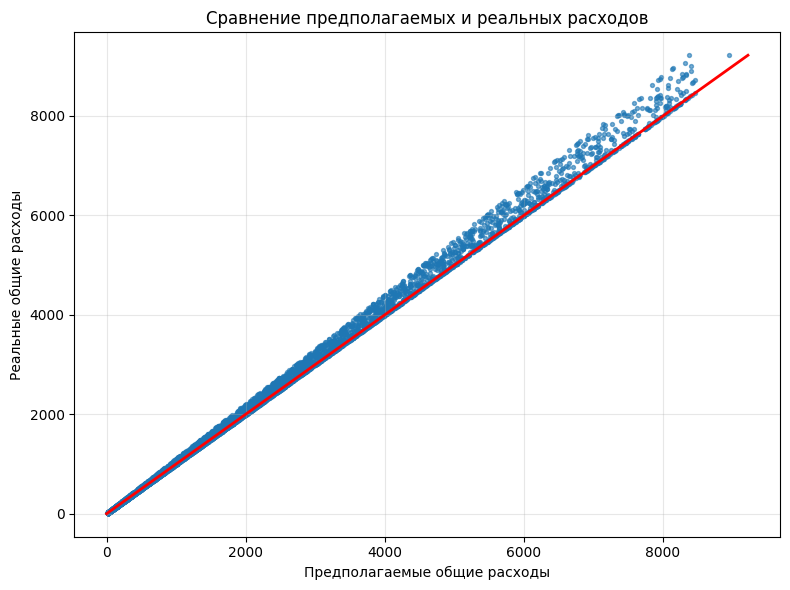

In [98]:
# проверим, что в TotalCharges_new накапливается сумма на момент среза
# рассчитаем итоговую сумму, умножив MonthlyCharges на duration(срок действия договора)
days_in_month = 365.25 / 12  # учтем високосные года

df["months_duration"] = df["duration"] / days_in_month
df["pred_total"] = df["MonthlyCharges"] * df["months_duration"]

plt.figure(figsize=(8,6))
plt.scatter(df["pred_total"], df["TotalCharges_new"], s=8, alpha=0.6)

min_v = np.nanmin([df["pred_total"].min(), df["TotalCharges_new"].min()])
max_v = np.nanmax([df["pred_total"].max(), df["TotalCharges_new"].max()])
plt.plot([min_v, max_v], [min_v, max_v], color="red", linewidth=2)

plt.xlabel("Предполагаемые общие расходы")
plt.ylabel("Реальные общие расходы")
plt.title("Сравнение предполагаемых и реальных расходов")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

На графике видно, что `TotalCharges` незначительно отличается от предполагаемых расходов, подсчитанных с использованием `MonthlyCharges`(расходы за месяц) и `duration`(длительность договора в месяцах). Разброс значений можно объяснить тем, что пользователи добавляют или отключают услуги.

Проверим, что для пользователей с`duration`(длительность договора в месяцах) == 1 и `Type`(тип оплаты) == `One year`, `TotalCharges` будет ~ `MonthlyCharges`, а не `MonthlyCharges`*12.

In [100]:
# отфильтруем данные
diff = 0.15  # +- 4/5 дней
check_charges = df[(df["Type"] == "One year") & df["months_duration"].between(1 - diff, 1 + diff)].copy()


# подсчитаем долю совпадений с TotalCharges_new MonthlyCharges
charges_equal = (check_charges["TotalCharges_new"].round(2) == check_charges["MonthlyCharges"].round(2)).mean()
print(f"\nДоля совпадений TotalCharges_new == MonthlyCharges: {charges_equal:.3f}")

# подсчитаем разницу и выведем информацию на экран
check_charges["diff"] = check_charges["TotalCharges_new"] - check_charges["MonthlyCharges"]
check_charges[["customerID", "MonthlyCharges", "TotalCharges_new", "diff"]].head(10)


Доля совпадений TotalCharges_new == MonthlyCharges: 0.250


,customerID,MonthlyCharges,TotalCharges_new,diff
222,6469-MRVET,20.200,20.200,0.000
1168,5562-BETPV,19.650,19.650,0.000
1286,8985-OOPOS,74.100,74.840,0.740
1654,2967-MXRAV,18.800,19.740,0.940
2113,7607-QKKTJ,95.000,103.550,8.550
2993,2239-CFOUJ,20.400,21.620,1.220
4767,1064-FBXNK,19.850,21.440,1.590
6149,3069-SSVSN,25.850,26.370,0.520


Доля полных совпадений `0.25`. Разницу `TotalCharges_new` и `MonthlyCharges` для других абонентов с годовым договором и сроком действия договора 1 месяц незначительна. Запоним пропуски в `TotalCharges_new` 0, так как срок действия договора(`duration`) у всех наблюдений с пропусками в `TotalCharges_new` равен 0(это новые пользователи, с которых плату за месяц еще не списали).

In [102]:
# заполним пропуски в TotalCharges_new значением 0
df["TotalCharges_new"] = df["TotalCharges_new"].fillna(0)

print(f'\nКол-во пропусков в TotalCharges_new после заполнения:{df["TotalCharges_new"].isna().sum()}')


Кол-во пропусков в TotalCharges_new после заполнения:0


Обработаем пропуски в признаке `InternetService`(тип подключения). Сейчас у части наблюдений в `InternetService` значение `NaN` (1526 пропусков из 7043 наблюдений). Нам известно, что подключение к Интернету может быть двух типов: через телефонную линию (`DSL` — «цифровая абонентская линия») или оптоволоконный кабель (`Fiber optic`). Предположим, что у абонентов, для которых тип подключения не указан, интернет не подключен. Косвенно отсутствие интернета подтверждается тем, что во всех признаках из датасета internet_new - 1526 пропусков. Заполним пропуски в `InternetService` заглушкой `No internet service`. 

Перед заполнением пропусков `InternetService` проверим, если интернет не подключен (InternetService - NaN после объединения таблиц), то и в остальных колонках, хранящих информаци об интернет-услугах (`OnlineSecurity`, `StreamingTV`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingMovies`) тоже нет значений.

In [105]:
# создадим список интернет-сервисов (кроме InternetService)
internet = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

# отфильтруем наблюдения, где InternetService - NaN
filter_InternetService = df["InternetService"].isna()
InternetService_set = df.loc[filter_InternetService, internet]

# подсчитаем, есть ли непустые значения
nan_counts = InternetService_set.notna().sum()

print("Количество строк с NaN в InternetService:", filter_InternetService.sum())
print(f"\nНепустые значения в интернет-услугах для пустых строк в InternetService:\n\n{nan_counts}")

# выведем результаты проверки
if nan_counts.sum() == 0:
    print("\nДля всех клиентов без интернета услуги тоже пустые")
else:
    print("\nНужно проверить: ")
    print(df.loc[filter_InternetService & InternetService_set.notna().any(axis=1), ["customerID", "InternetService"] + internet])

Количество строк с NaN в InternetService: 1526

Непустые значения в интернет-услугах для пустых строк в InternetService:

OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

Для всех клиентов без интернета услуги тоже пустые


Подтвердили гипотезу, что для всех наблюдений с NaN в InternetService, все значения в соответствующих записях других интернет-услугах тоже пустые. Теперь заполним пропуски в `InternetService` заглушкой `No internet service`.

In [107]:
# заполним пропуски в `InternetService` заглушкой `No internet service`
df["InternetService"] = df['InternetService'].fillna("No internet service")

# проверим, корректно ли отработала замена
print(f'\nКол-во пропусков в InternetService после заполнения:{df["TotalCharges_new"].isna().sum()}')


Кол-во пропусков в InternetService после заполнения:0


Проверим, для всех ли признаков из датасета `internet_new`(информация об интернет-услугах), верно: если `InternetService`==`No internet service`, то дополнительные интернет-услуги не подключены(NaN).

In [109]:
# список интернет-сервисов
internet = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

# отфильтруем клиентов без интернета
no_internet = df["InternetService"] == "No internet service"

# проверим, есть ли строки не NaN
mistake_internet = df.loc[no_internet, internet].notna().any(axis=1)

print("Всего клиентов без интернета:", no_internet.sum())
print("Несоответствий:", mistake_internet.sum())

# выведем несоответствия, если нашлись
if mistake_internet.sum() > 0:
    print("\nПримеры несоответствий:")
    print(df.loc[no_internet & mistake_internet, ["customerID","InternetService"] + internet].head())

Всего клиентов без интернета: 1526
Несоответствий: 0


Подтвердили, что для во всех интернет-услугах `NaN`, если `InternetService`==`No internet service` Заполним заглушкой `No internet service` пропуски в интернет-услугах.

In [111]:
# заполним заглушкой "No internet service" пропуски в интернет-услугах
internet = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

for item in internet:
    df.loc[df["InternetService"] == "No internet service", item] = "No internet service"

# проверим, корректно ли отработал код
nan_counts = df[internet].isna().sum()

print(f"Количество строк с NaN в InternetService:\n\n{nan_counts}")

Количество строк с NaN в InternetService:

OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


Признак `MultipleLines` содержит информацио о подключении телефона к нескольким линиям одновременно и принимает значения: "Yes"/"No". После объединения таблиц в колонке `MultipleLines` появились пропуски. Оператор связи "ТелеДом" предоставляет два типа услуг: стационарную телефонную связь и интернет. Предположим, что у абонентов с пропусками в  `MultipleLines` услуга "стационарная телефонная связь" не подключена.

Заполним пропуски в признаке `MultipleLines` заглушкой "No phone service".

In [113]:
# заполним пропуски в признаке MultipleLines заглушкой "No phone service"
df["MultipleLines"] = df["MultipleLines"].fillna("No phone service")

# проверим, корректно ли отработал код
nan_counts = df["MultipleLines"].isna().sum()

print(f"Количество строк с NaN в MultipleLines: {nan_counts}")

Количество строк с NaN в MultipleLines: 0


Проверим, что в объединенной таблице не осталось пропусков.

In [115]:
# Создадим бинарные признаки `has_internet`( 1 если интернет подключен, 0 если нет) и `has_phone` (1 если телефон подключен, 0 если нет). 

# создадим признак has_internet
df["has_internet"] = (df["InternetService"] != "No internet service").astype(int)

# создадим признак has_phone
df["has_phone"] = (df["MultipleLines"]!= "No phone service").astype(int)

# проверим распределение
print(df["has_internet"].value_counts())
print(df["has_phone"].value_counts())

has_internet
1    5517
0    1526
Name: count, dtype: int64
has_phone
1    6361
0     682
Name: count, dtype: int64


In [116]:
# проверим кол-во пропусков в объединенной таблице
# уберем служебный признак EndDate_new, удалять его пока не будем, он нам может потребоваться
print(f"Кол-во пропусков в объедененной таблице:\n{df.drop(columns='EndDate_new').isna().sum()}") 
print(f"\nРазмер объедененной таблицы:\n{df.shape}")

Кол-во пропусков в объедененной таблице:
customerID          0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges_new    0
BeginDate_new       0
is_active           0
EndDate_filled      0
duration            0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
months_duration     0
pred_total          0
has_internet        0
has_phone           0
dtype: int64

Размер объедененной таблицы:
(7043, 27)


**Вывод по итогам объединения таблиц и заполнения пропусков**

-----

1. **Объединение датасетов**:
- заказчик предоставил данные в четырех файлах. В датасетах `contract_new`(информация о договоре) и `personal_new`(персональные данные клиента) было `7043` записей, в датасете `internet_new`(информация об интернет-услугах) - 5517 записей, а в `phone_new`(информация об услугах телефонии) - `6361` запись. Во всех четырех датасетах есть столбец `customerID` с уникальным кодом клиента. Датасеты объединили по ключу `customerID`.
  
2. **Заполнение пропусков в объединенной таблице**:
   - после объединения таблиц в единых датасет появились пропуски в признаках, хранящих информацию об интернет-услугах(данные из датасета `internet_new`) и об услугах телефонии(данные из датасета `phone_new`):
   - пропуски в признаке `MultipleLines` из датасета `phone_new` заполнили заглушкой `"No phone service"`. Следовали логике, что если отсутствует информация о типе подключения, то услугу "Стационарную телефонную связь" пользователь не подключил. При принятии решения учли, что оператор связи «ТелеДом» предоставляет две основные услуги: "стационарная телефонная связь" и "интернет". То есть у пользователя может быть подключена одна из услуг;
   - пропуски в признаке `InternetService` заполнили заглушкой `"No internet service"`. При принятии решения учли, что оператор связи «ТелеДом» предоставляет две основные услуги: "стационарная телефонная связь" и "интернет". То есть у пользователя может быть подключена одна из услуг. Это подтверждается и тем, что для всех наблюдений с NaN в `InternetService`, все значения в соответствующих записях других интернет-услугах тоже пустые.
   - пропуски в признаках с информацией об интернет-услугах (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) заполнили заглушкой `"No internet service"`;
   - пропуски в `TotalCharges_new`(общие расходы абонента) заполнили 0. Руководствовались обнаруженной в ходе EDA закономерностью - продолжительность договоров у всех наблюдений с пропусками в `TotalCharges_new` равна нулю, то есть это новые пользователи и общие расходы у них  еше не накопились. Для этих абонентов `TotalCharges_new` == 0. 

## Исследовательский анализ и предобработка данных объединенного датафрейма

In [119]:
# выведем первые пять строк объединенного датасета 
df.head()

,customerID,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges_new,BeginDate_new,is_active,EndDate_new,EndDate_filled,duration,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,months_duration,pred_total,has_internet,has_phone
0,7590-VHVEG,Month-to-month,Yes,Electronic check,29.850,31.040,2020-01-01,1,NaT,2020-02-01,31,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No phone service,1.018,30.402,1,0
1,5575-GNVDE,One year,No,Mailed check,56.950,2071.840,2017-04-01,1,NaT,2020-02-01,1036,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,34.037,1938.405,1,1
2,3668-QPYBK,Month-to-month,Yes,Mailed check,53.850,226.170,2019-10-01,1,NaT,2020-02-01,123,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,4.041,217.611,1,1
3,7795-CFOCW,One year,No,Bank transfer (automatic),42.300,1960.600,2016-05-01,1,NaT,2020-02-01,1371,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No phone service,45.043,1905.324,1,0
4,9237-HQITU,Month-to-month,Yes,Electronic check,70.700,353.500,2019-09-01,1,NaT,2020-02-01,153,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,5.027,355.387,1,1


Создадими новые признаки по итогам EDA датасетов до создания объединенной таблицы.

**Новые признаки**:
- `avg_monthly` - средний месячный платеж(`TotalCharges_new`/`duration`)
- `trend_month` - отклонение среднего месячного платежа от текущего месячного платежа(`MonthlyCharges` - `avg_monthly`)
- `trend_ratio` - отношения `MonthlyCharges` к `avg_monthly`(средний ежемесячный платеж)
- `trend_groups` - с категориями динамики ежемесячных платежей(упали, стабильные, выросли)
- `pred_total` - предсказанные общие платежи (`MonthlyCharges`*`duration`)
- `total_diff`- разница между текущими общими платежами и предсказанными(`TotalCharges_new` - `MonthlyCharges`*`duration`)
- `has_phone` - подключена ли абонента стационарная телефонная связь
- `has_internet` - подключен ли абонента интернет
- `service_type`(тип связи) со значениями `has_phone`, `has_internet`, `has_both`
- `has_add_service`- подключены ли интернет-услуги. Будем использовать признаки с информацией об интернет-услугах(значения 0 - нет допсервисов/1-есть допсервисы)
- `add_service_count`- сколько дополнительных услуг подключено у абонента (значения от 0 до 6)
- `is_fixed` - если есть годовой или двухлетний контракт

In [121]:
# подсчитаем средний месячный платеж для новых контрактов с  duration ==0, передадим размер MonthlyCharges
df["avg_monthly"] = np.where(
    df["duration"] > 0,
    df["TotalCharges_new"] / df["duration"],
    df["MonthlyCharges"]
)

# вычислим отклонение текущей ставки от предсказанной
df["trend_month"] = df["MonthlyCharges"] - df["avg_monthly"]
df["trend_ratio"] = df["MonthlyCharges"] / df["avg_monthly"]

eps = 5.0
delta = pd.to_numeric(df["trend_month"], errors="coerce")

df["trend_groups"] = np.select(
    [delta < -eps, delta > eps],
    ["decreased", "increased"],
    default="stable"
)

# создадим признак с прогнозными общими доходами
df["pred_total"] = df["MonthlyCharges"] * df["duration"]
# создадим признак с разницей между текущими общими платежами и предсказанными общими платежами
df["total_diff"] = df["TotalCharges_new"] - df["pred_total"]

# создадим признак has_internet ( 1 если интернет подключен, 0 если нет)
df["has_internet"] = (df["InternetService"] != "No internet service").astype(int)

# создадим признак has_phone (1 если телефон подключен, 0 если нет)
df["has_phone"] = (df["MultipleLines"]!= "No phone service").astype(int)

# создадим признак service_type
df["service_type"] = df.apply(get_service_type, axis=1)

# создадим признак add_service_count
internet_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

mapping = {"Yes": 1, "No": 0, "No internet service": 0}
for c in internet_cols:
    df[c] = df[c].map(mapping).fillna(0).astype(int)

df["add_service_count"] = df[internet_cols].sum(axis=1)

# создадим бинарный признак для фиксированного срока договора (1) или нет (0)
df["is_fixed"] = df["Type"].isin(["One year", "Two year"]).astype(int)


# выведем на экран новые признаки 
new_contract_cols = ["pred_total", "total_diff", 
                     "trend_groups", "avg_monthly", 
                     "trend_month", "trend_ratio",
                     "has_internet", "has_phone",
                     "add_service_count", "service_type",
                     "is_fixed"
                    ]
df[new_contract_cols].head()

,pred_total,total_diff,trend_groups,avg_monthly,trend_month,trend_ratio,has_internet,has_phone,add_service_count,service_type,is_fixed
0,925.350,-894.310,increased,1.001,28.849,29.812,1,0,1,internet_only,0
1,59000.200,-56928.360,increased,2.000,54.950,28.477,1,1,2,both,1
2,6623.550,-6397.380,increased,1.839,52.011,29.286,1,1,2,both,0
3,57993.300,-56032.700,increased,1.430,40.870,29.579,1,0,3,internet_only,1
4,10817.100,-10463.600,increased,2.310,68.390,30.600,1,1,0,both,0


Сделаем разбивку по ежемесячным платежам сроком до 24 месяцев(для чистоты измерений) договоров без доп интернет-услуг, MultipleLines с разбивкой по InternetService и Type. Попробуем поймать разницу в базовых тарифах для договоров только с интернетом и только со стационарной телефонной связью. 

In [123]:
print('\nДоговоры только c интернетом без доп услуг\n')
internet_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

base_df = df[
    (df[internet_cols].eq(0).all(axis=1)) &
    (df["MultipleLines"] == "No") &
    (df["InternetService"].isin(["DSL", "Fiber optic"])) &
    (df["duration"] <= 730)
]

# сводка по InternetService × Contract
grouped_contract = (
    base_df.groupby(["InternetService", "Type"])["MonthlyCharges"]
           .agg(["count", "mean", "median", "min", "max"])
           .sort_index()
)

display(grouped_contract)

# сводная таблица средних значений 
pivot_mean_internet = base_df.pivot_table(
    index="InternetService",
    columns="Type",
    values="MonthlyCharges",
    aggfunc="mean"
).sort_index()

display(pivot_mean_internet )

print('\nДоговоры только со стационарным телефоном\n')
# посмотрим на договоры с телефонией, без интернета
base_df = df[
    (df["MultipleLines"] == "Yes") &
    (~df["InternetService"].isin(["DSL", "Fiber optic"]))
]

# сводка по типу договора (Type / Contract)
grouped_contract = (
    base_df.groupby("Type")["MonthlyCharges"]
           .agg(["count", "mean", "median", "min", "max"])
           .sort_index()
)

display(grouped_contract)

# средний чек по типу договора
pivot_mean_phone = base_df.pivot_table(
    index="Type",
    values="MonthlyCharges",
    aggfunc="mean"
).sort_index()

display(pivot_mean_phone)


Договоры только c интернетом без доп услуг



count   mean  median    min    max
InternetService Type                                              
DSL             Month-to-month    157 44.996  45.000 42.900 46.600
                One year            4 44.112  44.200 43.450 44.600
Fiber optic     Month-to-month    205 70.059  70.050 67.750 71.800

Type,Month-to-month,One year
InternetService,,
DSL,44.996,44.112
Fiber optic,70.059,NaN



Договоры только со стационарным телефоном



,count,mean,median,min,max
Type,,,,,
Month-to-month,46,25.001,25.025,23.150,26.450
One year,64,24.897,24.800,23.300,26.900
Two year,232,24.985,25.025,22.950,26.500


,MonthlyCharges
Type,
Month-to-month,25.001
One year,24.897
Two year,24.985


Кол-во договоров с интернетом, без допфункций и MultipleLines с типом платежей(год и более) ничтожно мало. Это нужно изучить подробнее. При этом ежемесячные платежи для годовых контрактов чуть дешевле для `DSL`. Для `Fiber optic` для договоров длительностью 24 месяца годовых контрактов даже не нашлось. На весь датасет договоров с базовым интернетом всего 12. 

Получается, базовый интернет тариф (для `DSL` или `Fiber optic`) с ежемесячными платежами - от 43 до 72.

Большинство договоров только с телефонией  - с типом договора на два года(`Two year`). Месячный договор на телефонию немного дешевле для двухлетних контрактов.

Отловим договоры, которые закончились раньше срока. Возьмем договоры на два года или год, соотносим из с абсолютным сроком - 12 или 24 месяца. Отбираем уже законченные договоры с нужными типами.  Высчитываем ожидаемое время (12 или 24)законченные договоры и отбирем те договоры, где `duration` меньше ожидаемой продолжительности. Признак будем использовать только для исследования, чтобы избежать утечки целевой переменной.

Из EDA датасета `contract_new` знаем, что у `55%` абонентов (`3875` клиентов) договор с ежемесячной оплатой. У `24%`(`1695`) абонентов - тип оплаты `Two year`. У `21%`(`1473`) абонентовтип - тип оплаты `One year`. Суммарное кол-во договоров `Two year`+`One year` - `45%`(`3168`)

In [126]:
fixed_types = {"One year": 12, "Two year": 24}
threshold_days = 10  # зона +-10 дней

df = df.copy()

# соберем маски для данных (договор завершен+нужные сроки контрактов)
mask_fixed = df["Type"].isin(fixed_types)                
mask_ended = df["EndDate_new"].notna()                   

# создадим признак с датой ожидаемого конца контракт (начало договора+срок договора(12, 24 месяца))
df["expected_end_date"] = pd.NaT
df.loc[mask_fixed, "expected_end_date"] = df.loc[mask_fixed].apply(
    lambda x: (x["BeginDate_new"] + pd.DateOffset(months=fixed_types[x["Type"]])
               if pd.notna(x["BeginDate_new"]) else pd.NaT), axis=1
)

# выделим договоры с досрочным расторжением: 
cond_early = (
    df["EndDate_new"] < (df["expected_end_date"] - pd.Timedelta(days=threshold_days))
)

# создадим признак с данными досрочно расторгнутых договоров на год/два года (1 если ранний разрыв, иначе 0; для остальных — NaN)
df["early_terminated"] = np.where(
    mask_fixed & mask_ended & cond_early, 1,
    np.where(mask_fixed & mask_ended, 0, np.nan)
).astype("float")  

# проверим, корректно ли собрались данные
n_all = len(df)
n_fixed = mask_fixed.sum()
n_fixed_ended = (mask_fixed & mask_ended).sum()
vc_fixed = df.loc[mask_fixed & mask_ended, "early_terminated"].value_counts()

# выведем на экран
print(f"Всего записей: {n_all}")
print(f"Кол-во договоров с  One year, Two year: {n_fixed}")
print(f"Завершенных с One year, Two year: {n_fixed_ended}")
print("Распределение среди завершенных договоров с One year, Two year:")
print(vc_fixed.sort_index())  

Всего записей: 7043
Кол-во договоров с  One year, Two year: 3168
Завершенных с One year, Two year: 694
Распределение среди завершенных договоров с One year, Two year:
early_terminated
0.000    578
1.000    116
Name: count, dtype: int64


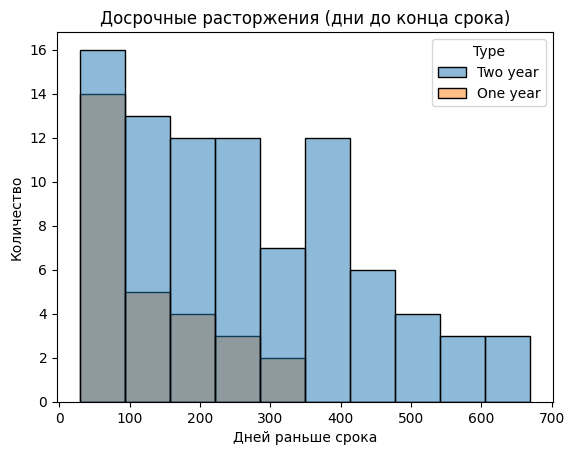

In [127]:
# создадим новый признак - за сколько дней до конца договора клиент расторг контракт
# возьмем только фиксированные и завершенные
mask_fixed = df["Type"].isin(["One year", "Two year"])
mask_ended = df["EndDate_new"].notna()

df.loc[mask_fixed & mask_ended, "days_before"] = (
    df.loc[mask_fixed & mask_ended, "expected_end_date"]
    - df.loc[mask_fixed & mask_ended, "EndDate_new"]
).dt.days

# отрисуем график для досрочных
sns.histplot(
    data=df[df["early_terminated"]==1],
    x="days_before", hue="Type", bins=10, kde=False
)
plt.title("Досрочные расторжения (дни до конца срока)")
plt.xlabel("Дней раньше срока")
plt.ylabel("Количество")
plt.show()

1. Расторгнутых контрактов с типом договора `One year`/`Two year` - 4%(ничтожно мало)
2. Клиенты уходят раньше чаще в начале срока

Построим матрицу корреляций phik_matrix, что оценить корреляцию между признаками объединенного датасета.

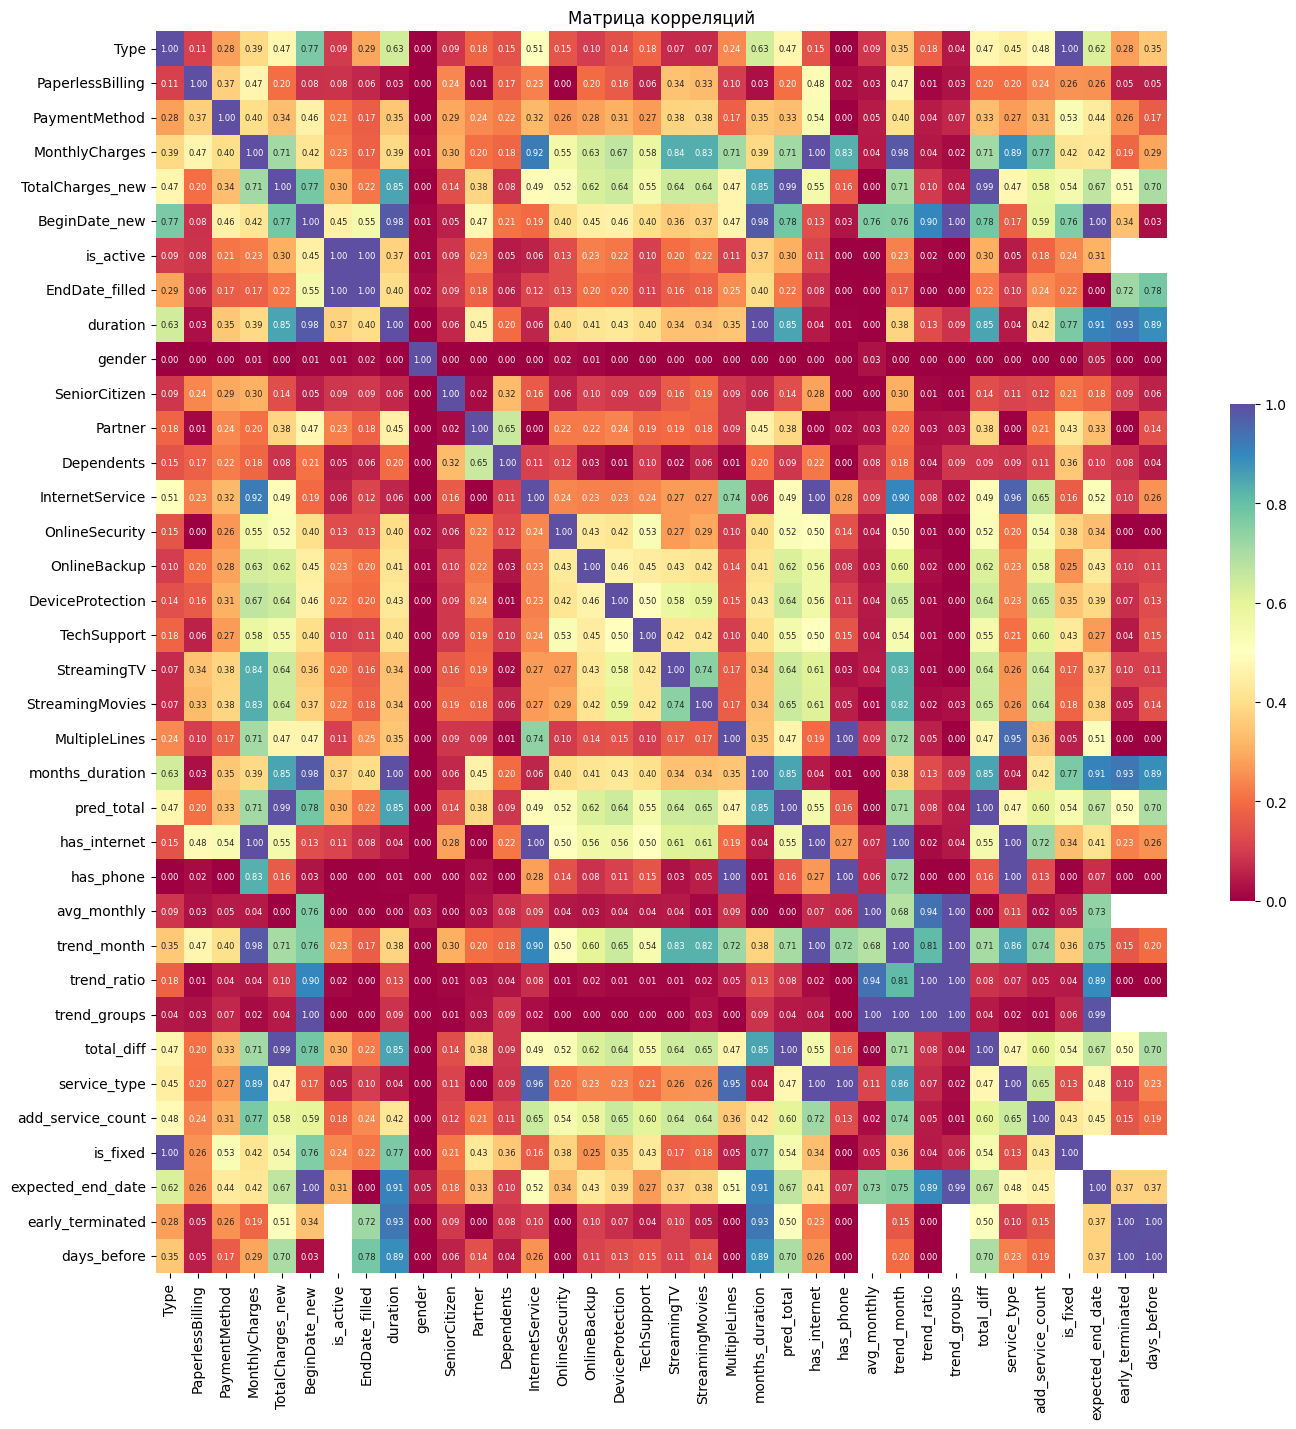

In [130]:
# зададим список колонок для передачи методу phik_matrix
# выделим непрерывные числовые признаки (исключим бинарные 0/1)
num_cols = df.drop(columns=['customerID']).select_dtypes(include=[np.number]).columns.tolist()
binary_num = [c for c in num_cols if df[c].dropna().nunique() == 2]
interval_cols = [c for c in num_cols if c not in binary_num]

# подсчитаем phik 
phi_k = df.drop(columns=['customerID','EndDate_new', ]).phik_matrix(interval_cols=interval_cols)   # значения в [0, 1]

# визуализируем тепловую карту phik 
fig_w = max(8, 0.4 * len(phi_k.columns))
fig_h = max(6, 0.4 * len(phi_k.index))

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    phi_k,         
    cmap="Spectral",
    vmin=0, vmax=1,
    annot=True, fmt=".2f", 
    annot_kws={"size": 6},
    cbar_kws={"shrink": .4}
)
plt.title("Матрица корреляций")
plt.tight_layout()
plt.show()

**Вывод на основе анализа матрицы корреляции**

1. **самая сильная связь между признаками**:
   - между `is_active` и всеми признаками, производными от длительности договора/досрочно завершенных договорах
   - `is_active`/`EndDate_filled` - это логично, используя данные из `EndDate_filled` мы и создали признак `is_active`. Удалим признак `EndDate_filled`
   - `has_internet`/все признаки с информацией об интернет-услугах. Если есть интернет, есть интернет услуги. Нет интернета - нет и интернет услуг. Стоит удалить колонки с информацией о подключенных интернет услугах и создать признак, содержащий информацию о том, подключены ли интернет-услуги.
3. **средняя связь между признаками**:
   - `MonthlyCharges`/`InternetService`(~0.6) - ежемесячная плата зависит от наличия и типа интернета
   - `TotalCharges`/`MonthlyCharges`(~0.5) - чем больше ежемесячная плата, тем выше итоговые расходы
   - `TotalCharges`/`duration`(~0.7) - чем дольше длится контракт, тем большеобщие расходы клиента
   - `Type`/`BeginDate_new`(~0.77)- разные типы оплаты были популярыне в разное время (интересная зависимость, может быть связана с политикой компании). У `Type` также сильная связь с `duration`. Стоит оставить только признак `duration` и удалить `BeginDate_new`, чтобы не было утечки данных. 
   - `is_active`/`duration`(~0.5) - действующие контракты чаще у клиентов с большей длительностью договоров
4. **слабая связь между признаками**:
   - `PaymentMethod`/`PaperlessBilling`(~0.3) - клиенты, выбравшие электронный расчетный лист, выбрали и определенный тип оплаты 
   - `Dependents`/`Partner`(~0.3) - дети есть чаще у клиентов с партнерами
   - `SeniorCitizen`/`is_active`(~0.2) - клиенты со статусом пенсионер чуть чаще расторгают контракты
5. **почти отсутствие связи с другими признаками**:
   -  `gender` 

**нужно удалить признаки:**
   - `EndDate_new` - служебный + утечка целевого признака
   - `EndDate_filled` - утечка целевого признака
   - `gender` - распределение полов почти равное, связь с другими признаками почти отсутствует
   - `days_before` - служебный + утечка целевого признака
   - `early_terminated` - служебный + утечка целевого признака
   - `expected_end_date` - служебный + утечка целевого признака
   - `has_internet`- избыточный + высокая корреляция
   - `has_phone`- избыточный + высокая корреляция

Посмотрим на связи между признаками для `duration`, `Type`, `MonthlyCharges`,`PaperlessBilling`.

Оценим распределение по классам целевой переменной `is_active`(договор завершен) для числовых признаков: `MonthlyCharges`(расходы за месяц) и `duration`(продолжительность договора в месяцах).

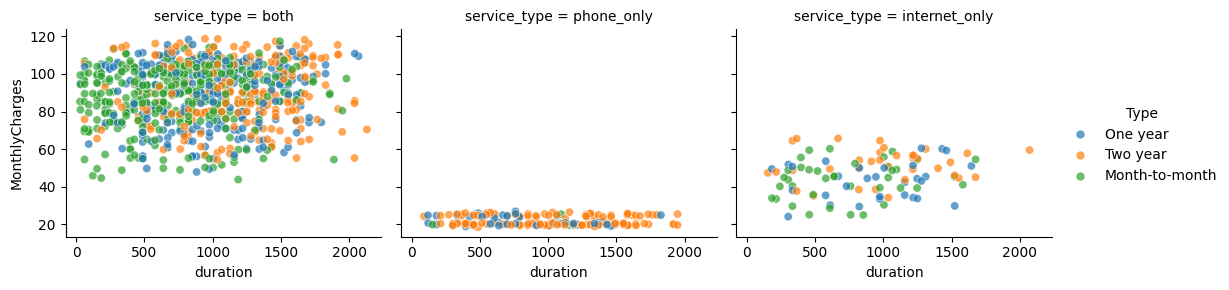

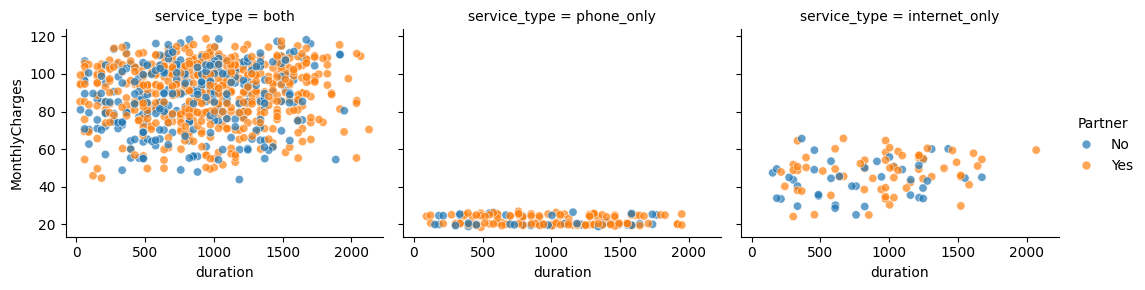

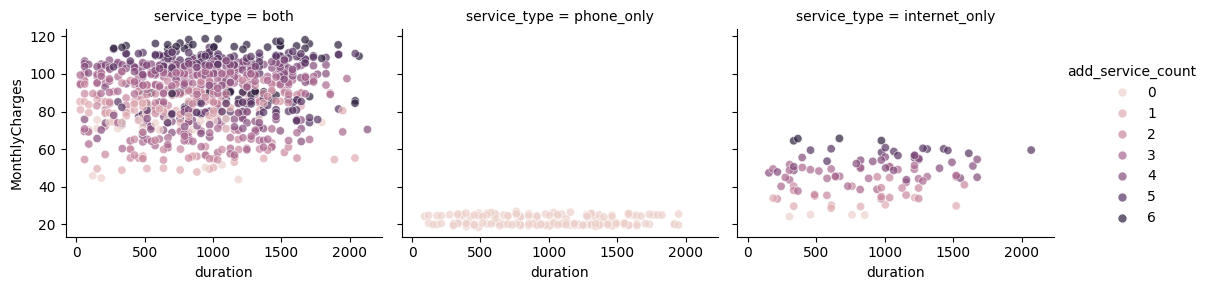

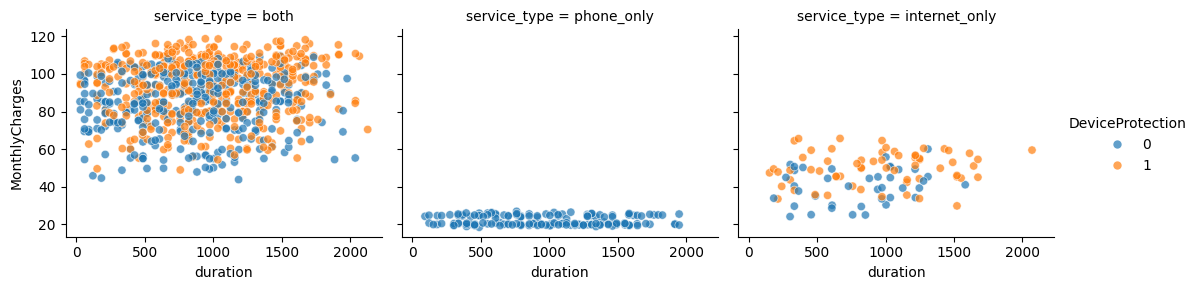

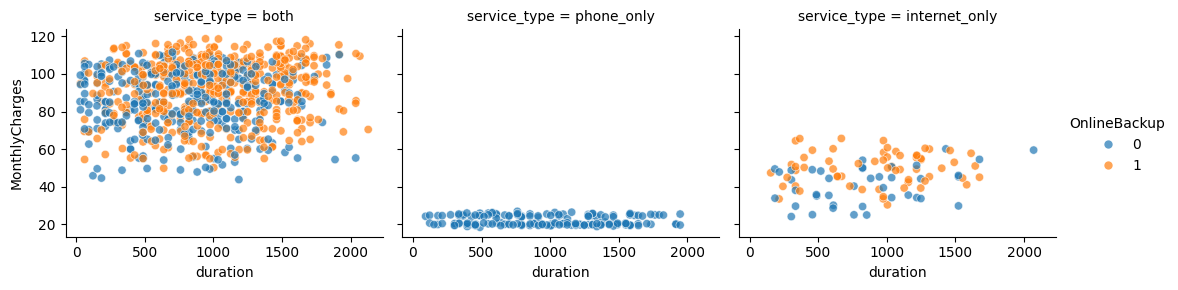

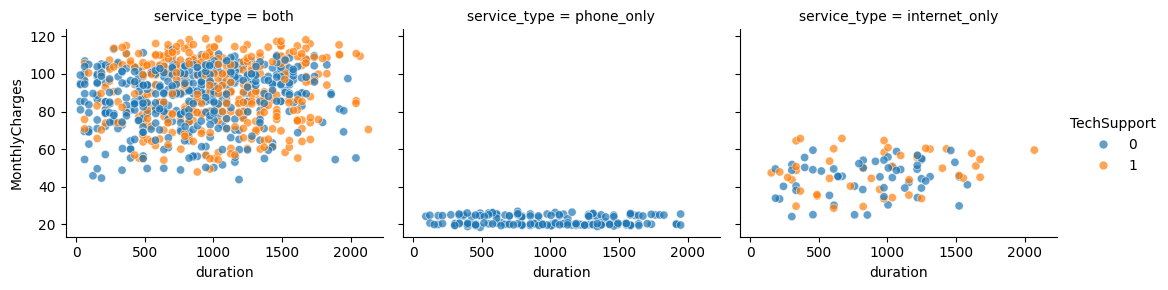

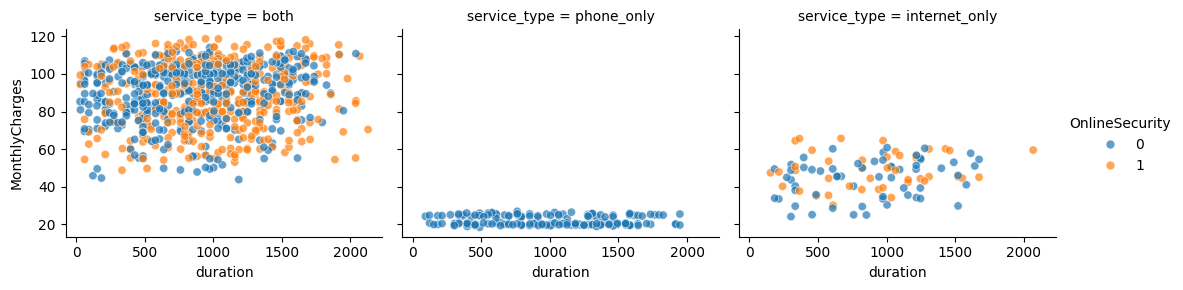

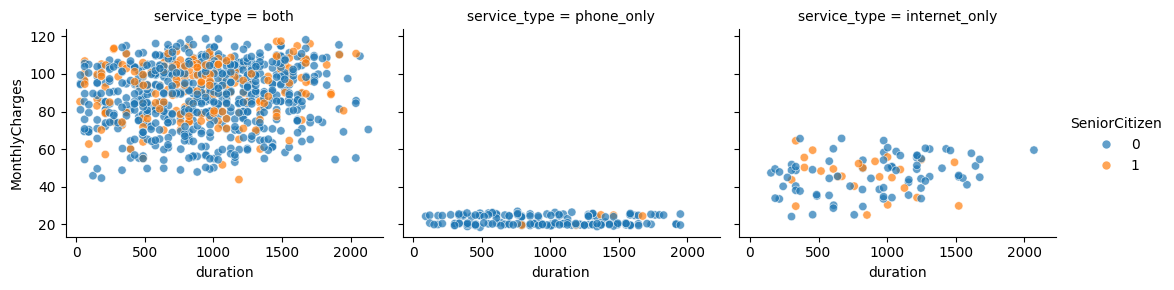

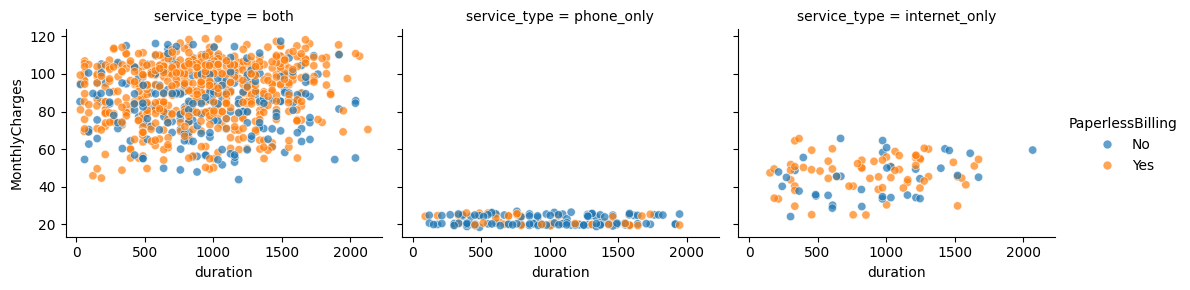

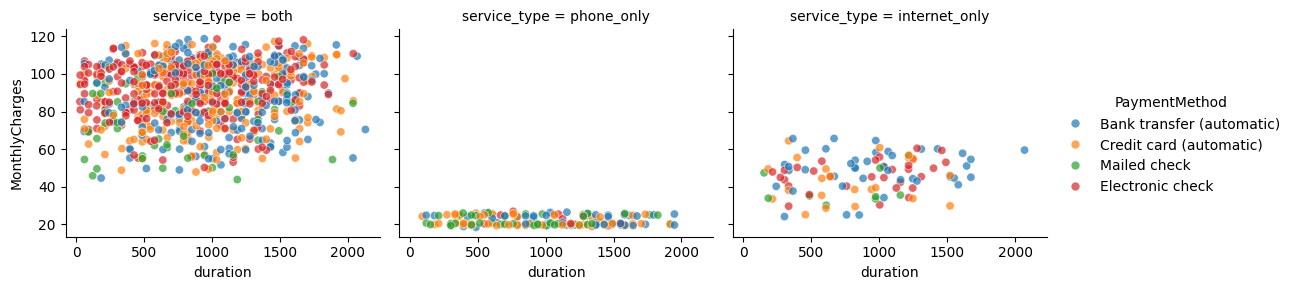

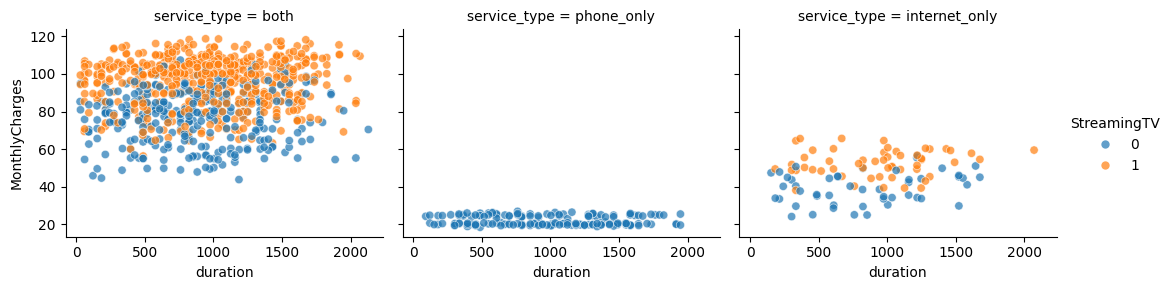

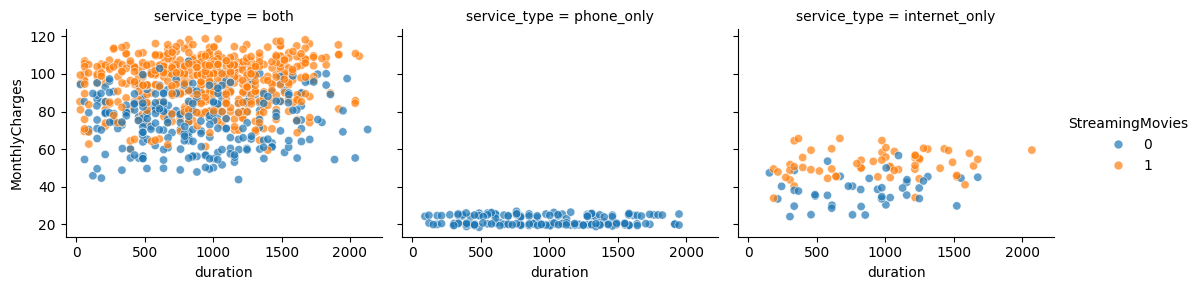

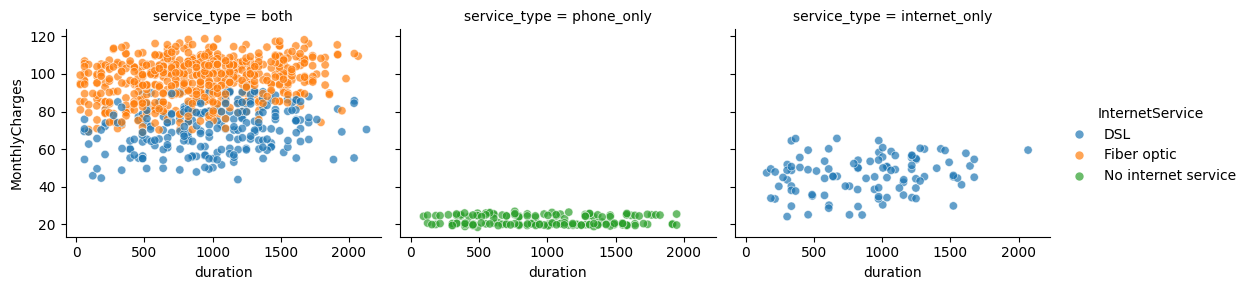

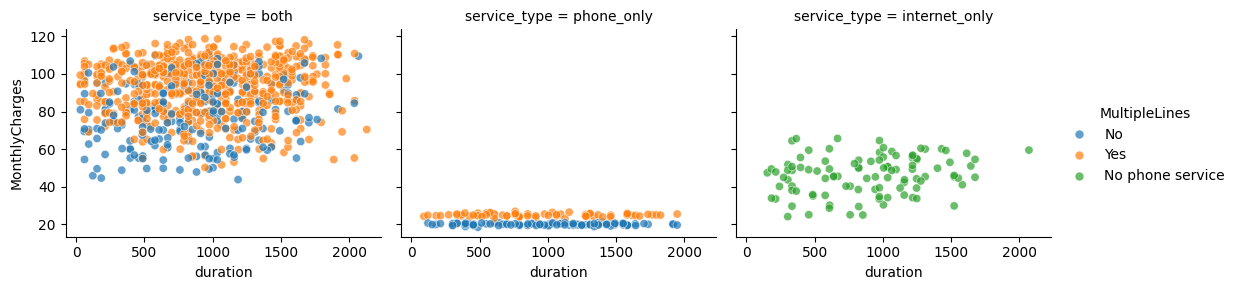

In [134]:
# отрисуем графики для завершенных договоров
not_active = df[df['is_active'] == 0].copy()
cols=["Type", "Partner", "add_service_count", "DeviceProtection", 
      "OnlineBackup", "TechSupport", "OnlineSecurity", 'SeniorCitizen',
      "PaperlessBilling", "PaymentMethod", "StreamingTV", 
      "StreamingMovies", "InternetService", "MultipleLines"
     ]
for col in cols:
    sns.relplot(
    data=not_active,
    x="duration", y="MonthlyCharges", hue=col,
    col="service_type", col_wrap=3, kind="scatter", alpha=0.7, height=3, aspect=1.2
    )
    plt.show()

**среди завершенных договоров с `phone_only`**:
 - базовый тариф с минимальными платежами. Ежемесячный тариф не меняется со временем
 - договоров `month_to_month` почти нет, большинство договоров -`Two year`
 - наличие партнера никак не влияет на ежемесячные платежи и длительность договора
 - статус `SeniorCitizen` у единиц (надо проверить активных)
 - у большиснтва `PaperlessBilling` не оформлен
 - `Electronic check` получает меньшинство, у многих `Mailed check`
 - кол-во договоров с  `MultipleLines` - примерно половина, у договоров с подключенным `MultipleLines` ежемесячные платежи немного выше

**среди завершенных договоров с `internet_only`**:
 - статус `SeniorCitizen` у меньшинства
 - `PaperlessBilling` оформлен у большинства
 - мало `Mailed check`. Много `Electronic check` и автоплатежей
 - `InternetService` - только `DSL`

**среди завершенных договоров с `both`:**
- абонентов с партнерами чуть больше
- у большинства подключено больше 3 сервисом. Много договоров с 6 доп услугами. Ежемесячные платежи у таких самые высокие
- у большинства подключены доп сервисы защиты(`OnlineSecurity` и др)
- у большинства `PaperlessBilling`
- у большинства оформлен сервис `StreamingTV` и `StreamingMovies` у таких договоров самые высокие ежемесячные платежи
- у большинства `InternetService` - `Fiber optic` и ежемесячные платежи у договоров с `Fiber optic` -`65-120`. В то время, как у большинства договоров с `DSL` - `от 50 до 90`.
- у большинства подключена `MultipleLines`

Можно учесть большой вклад стриминговых сервисов в ежемесячный тариф - создать признак счетчик стриминговых сервисов.

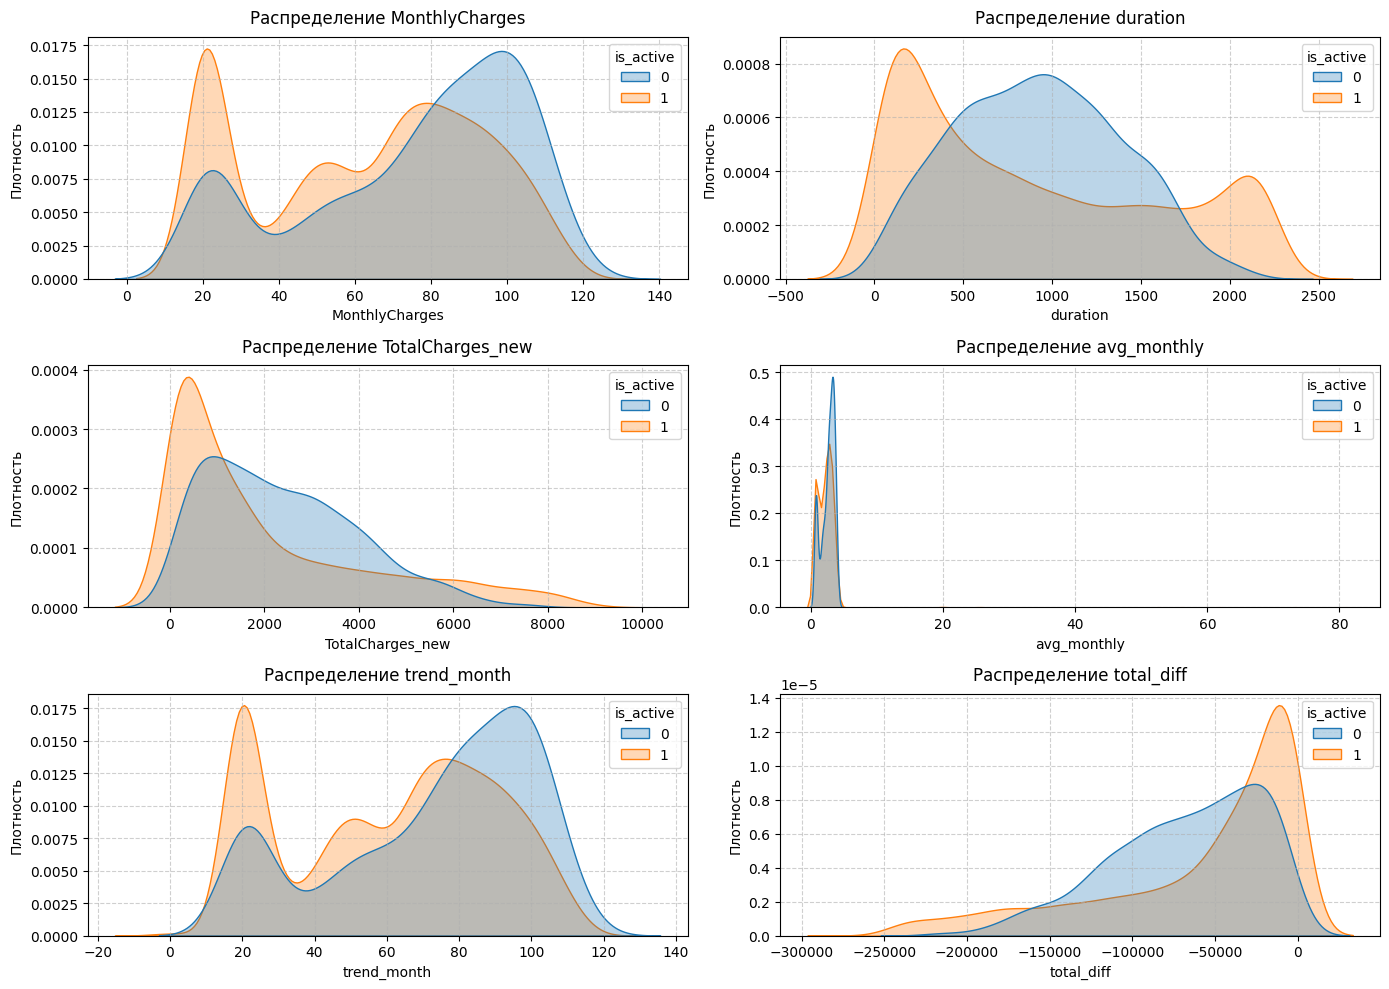

In [136]:
plot_distributions(data=df, columns=["MonthlyCharges", "duration", "TotalCharges_new", "avg_monthly", 
                                     "trend_month", "total_diff"], 
                   hue_col='is_active', 
                   figsize=(14, 10), height=4.3, aspect=1.6)

**Вывод на основе анализа распределения ежемесячных платежей(`MonthlyCharges`), общих расходов(`TotalCharges_new`) и длительности договора(`duration`) по классам целевой переменной `is_active`**:

1. `MonthlyCharges`/`is_active`:
   - чаще договоры расторгают клиенты с минимальными ежемесячными платежами и платежами более 80 в месяц. То есть риск расторжения выше у клиентов с низкими и высокими платежами
   - кол-во расторгнутых договоров уменьшается с ростом 
2. `TotalCharges_new`/`is_active`:
   - кол-во расторгнутых договоров уменьшается с накоплением общих расходов
   - больше всего расторгнутых договоров в средней зоне - в диапазоне от ~300 - ~5000
3. `duration`/`is_active`:
   - Кол-во расторгнутых договоров растет начиная с 12 месяцев. Как вариант, это абоненты у которых был годовой контракт. Кол-во расторгнутых договоров растет до 30 месяцев, а затем мниэается практически до нуля. То есть клиенты с длительными договорами(лояльные) крайне редко расторгают договор. Самые преданные клиенты - клиенты с длительностью договора более 70 месяцев(более 6 лет).
  
Договор чаще всего расторгают клиенты с платежами более 80 в месяц. В зоне риска также клиенты с минимальными ежемесячными платежами. Чаще всего договор расторгают клиенты с небольшими накопленными доходами, что логично, ведь общие расходы зависят от длительности договора. Чем дольше клиент на договоре, тем выше у него общие расходы. Кол-во расторгнутых договоров выше всего у договоров длительность (~12-42 месяцев). 

Проанализируем распределение признаков для разных классов `is_active`.

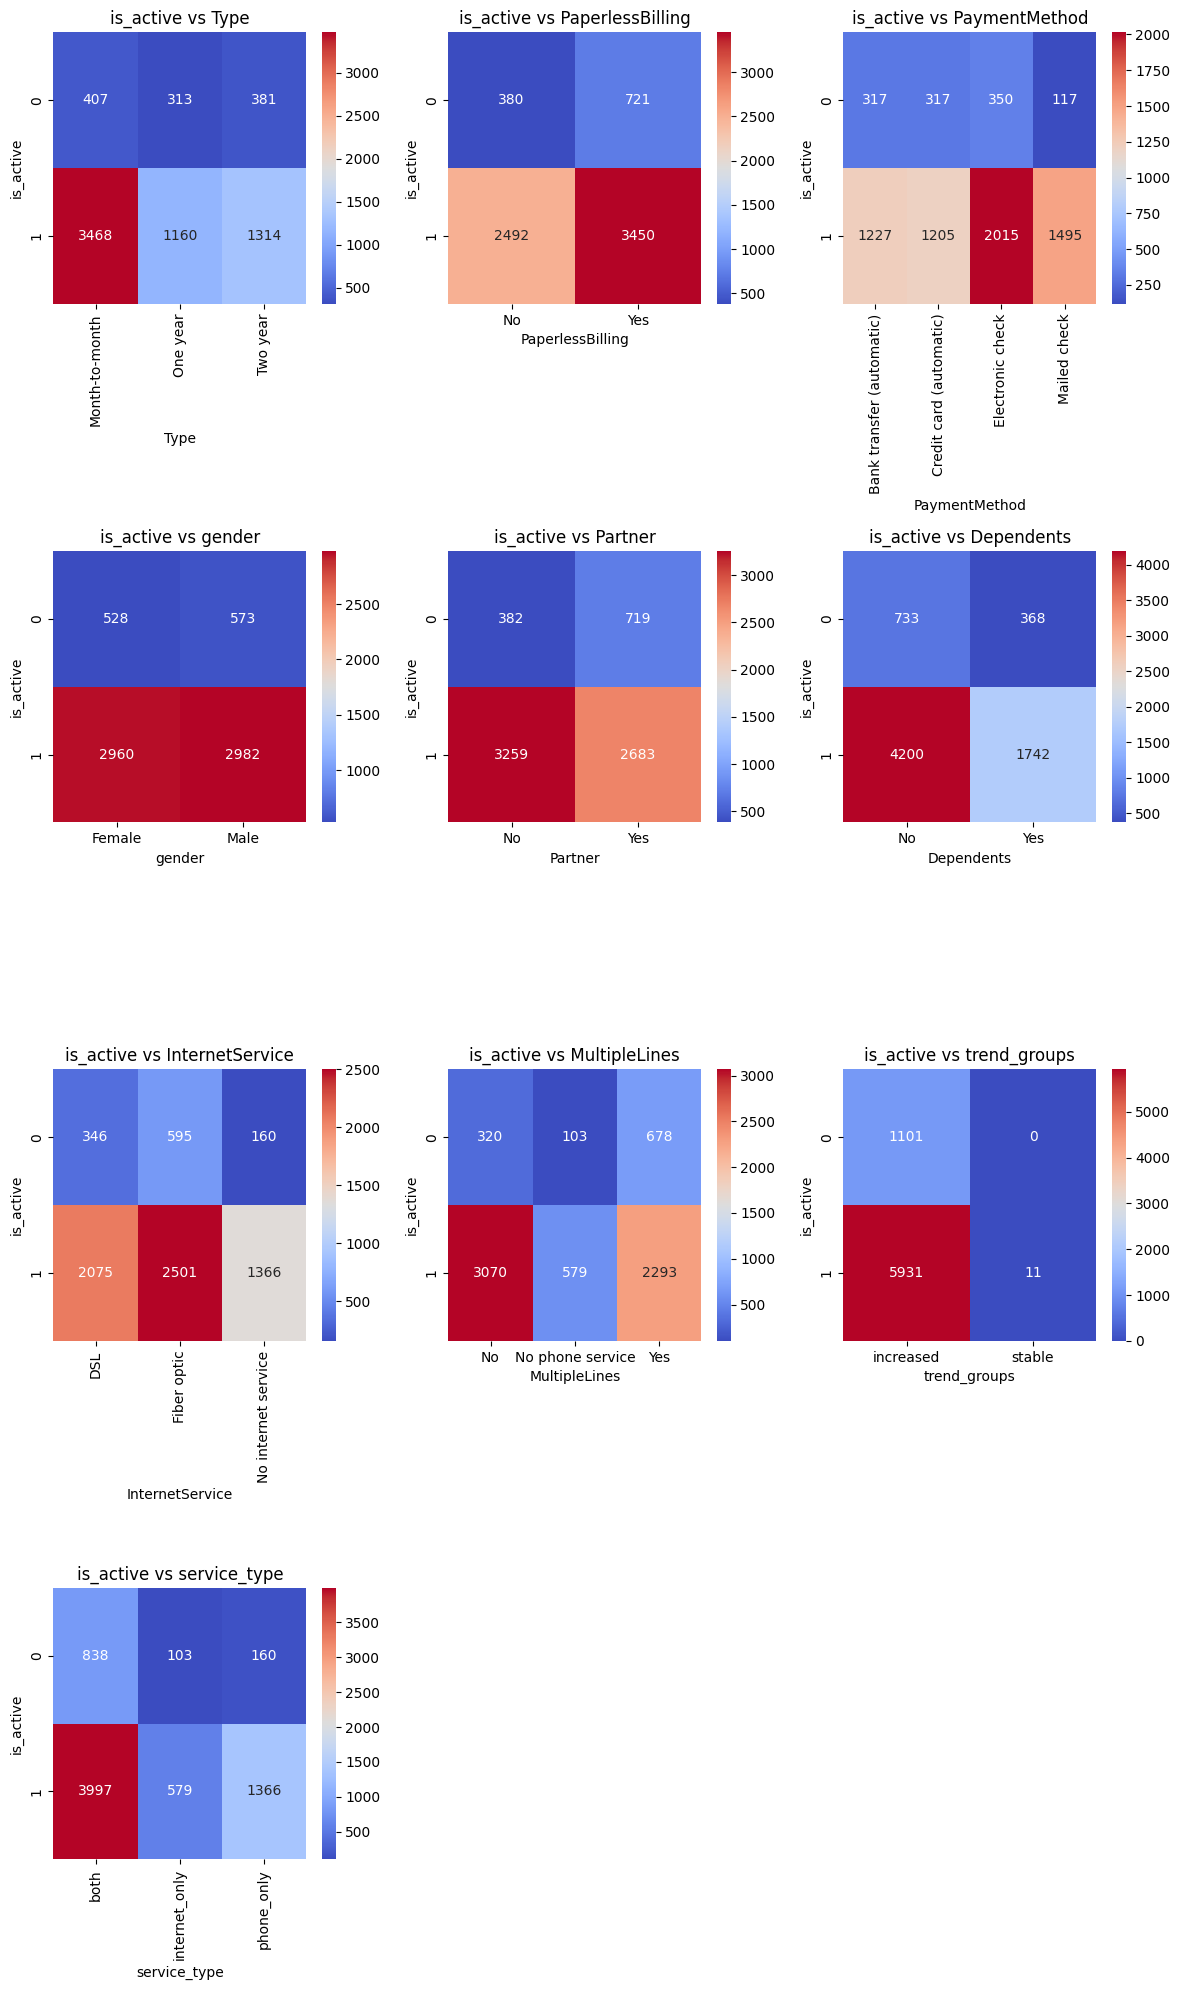

In [139]:
# построим тепловую карту зависимостей между таргетом и категориальными фичами
cat_col = df.select_dtypes(include='object').drop(columns=['customerID']).columns.to_list()
plot_heatmap(df, 'is_active', cat_col, n_cols=3)

**Вывод на основе распределения категориальных признаков по классам целевой переменной `is_active`(завершен договор/действует)**

------
1. **`has_phone`/`is_active`**:
   - у большинства расторгнутых договоров нет услуги стационарная телефонная связь 
2. **`has_internet`/`is_active`**:
   - в большинстве расторгнутых договоров нет услуги интернет
3. **`Dependents`, `Partner`/`is_active`**:
   - договор чаще расторгают абоненты без партнеров и детей
4. **`PaymentMethod`/`is_active`**:
   - расторгнутых  договоров больше среди абонентов со способом оплаты с `Electronic check`. Клиенты с `Bank transfer (automatic)` и `Credit card (automatic)` удерживатся лучше. То есть автоматизация платежей позволяет удержать клиента.
5. **`PaperlessBilling`/`is_active`**:
   - расторгнутых больше среди абонентов, которые не получают электронный расчетный лист. Веротяно, это более консервативные пользователи, им сложно сменить оператора
6. **`Type`/`is_active`**:
   - чаще всего договор расторгают пользователи с типом оплату `Month-to-month`. То есть долгосрочный контракт удерживает клиента
7. **`MultipleLines`/`is_active`**:
   - чаще всего разговор расторгают пользователи, у которых есть подключение телефона к нескольким линиям одновременно
8. **`SeniorCitizen`/`is_active`**:
   - пенсионеры чаще расторгают договор
9. **`InternetService`/`is_active`**:
   - чаще договор расторгают клиенты с DSL 
11. **`интернет-услуги`**:
   - чаще уходят клиенты у которых нет дополнительных услуг
12.  **`gender`/`is_active`**
   - распредление по классам целевой переменной почти одинаковое. мужчины чуть чаще расторгают договор(`femaleм-48%,` male`-52% от расторгнутых) 

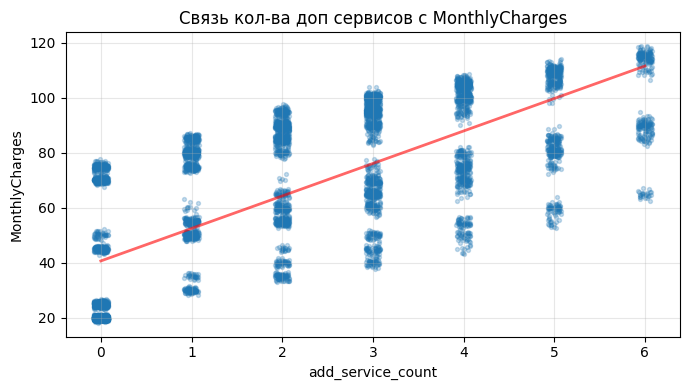

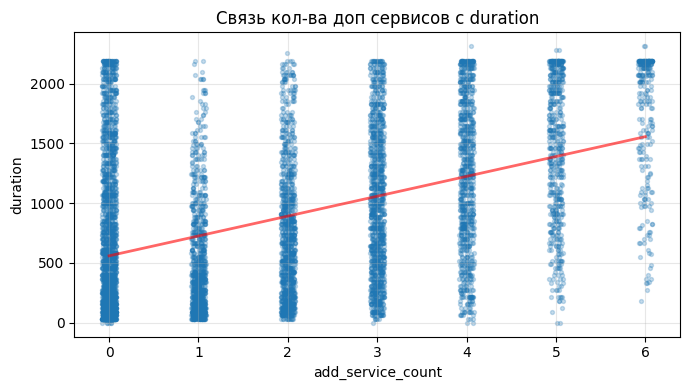

In [141]:
# визуализируем связь признаков "MonthlyCharges", "TotalCharges_new", "duration" с `is_active`
service_col = ["MonthlyCharges", "duration"]
for item in service_col:
    plot_scatter_with_trend(df, count_col="add_service_count", value_col=item,
                        title=f"Связь кол-ва доп сервисов c {item}")

**Вывод на основе визуализации связи размера ежемесячных платежей от кол-ва подключенных интернет-услуг** 

1. **`MonthlyCharges` и кол-во доп услуг**: 
Между кол-вом подключенных интернет-услуг и размером ежемесячного платежа существует явная положительная зависимость: чем больше подключено услуг, тем выше платеж. Линия тренда это отлично показывает. 

На графике также видно, что MonthlyCharges разбивается на три группы:

- меньше 30: вероятно, минимальный тариф (без дополнительных услуг);
- 30–80: тарифы с базовыми сервисами + часть дополнительных опций;
- больше 80: дорогие тарифы с полным пакетом услуг;

Вероятно, оператор связи «ТелеДом» продает тарифы с фиксированной ценой, к ним уже подключатся дополнительные сервисы/услуги

Чем больше дополнительных услуг подключили абоненту, тем выше вероятность, что клиент попадет в группу с дорогими тарифами
Это объясняет ранее выявленную связь между наличием дополнительных услуг и оттоком клиентов. Может оказаться, что клиенту включают как можно больше услуг и он уходит.

2. **`TotalCharges_new` и кол-во доп услуг**:
   - Между кол-вом подключенных интернет-услуг и размером ежемесячного платежа зависимость как для `MonthlyCharges`(что логично, так как `TotalCharges_new`~`MonthlyCharges`*`duration`)
4. **`duration` и кол-во доп услуг**:
   - зависимость положительная, но менее выраженная, чем для `TotalCharges_new`,`MonthlyCharges`. Вероятно, у лояльных клиентов с долгим договором накопилось много доп сервисов

В ходе анализа распределния признаков обнаружилось, что `MonthlyCharges` разбивается на три группы. Вероятно, это связано с тем, что оператор предлагает разные тарифы. Создадим новый признак, чтобы учесть тарифы оператора. Базовый тариф - `low`, стандарный тариф - `medium`, и самый дорогой, премиальный тариф `high`. Для разбивки на кластеры будем использовать `KMeans`. 

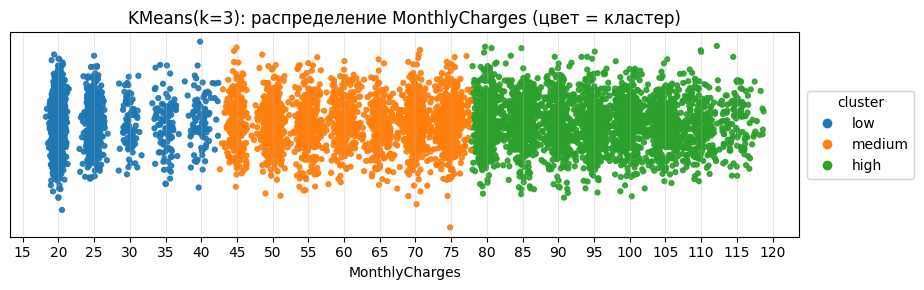

0       low
1    medium
2    medium
3       low
4    medium
Name: tariff, dtype: object

tariff
high      2912
medium    2239
low       1892
Name: count, dtype: int64

In [144]:
# создадим новый признак с тарифами, используем кастомную функцию с KMeans
df["tariff"] = plot_kmeans_monthlycharges(df)
display(df["tariff"].head())
df["tariff"].value_counts()

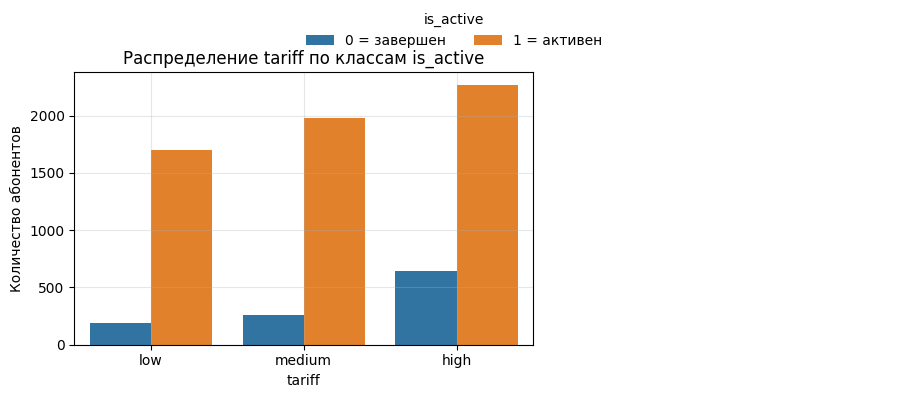

In [145]:
# визуализируем распределени значений признака tariff по классам целевой переменной is_active
cols = ["tariff"]
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes = axes.ravel()

for i, c in enumerate(cols):
    ax = axes[i]
    sns.countplot(data=df, x=c, hue="is_active", hue_order=[0, 1], ax=ax)
    ax.set_title(f"Распределение {c} по классам is_active")
    ax.set_xlabel(c)
    ax.set_ylabel("Количество абонентов")
    ax.grid(True, alpha=0.3)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# удалим пустые оси, если есть
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

# соберем легенда 
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(handles, ["0 = завершен", "1 = активен"], title="is_active",
           loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

**Вывод на основе визуализации связи кол-ва доп услуг, ежемесячных платежей с разбиваками по "Type", "PaymentMethod", "InternetService"** 

1. **`MonthlyCharges`/`add_service_count` (разбивка по `PaymentMethod`)**:
   - **`Electronic check`**: клиенты с электронным чеком чаще всего платят больше при подключении доп сервисов. Вероятно поэтому у этой категории PaymentMethod так много расторгнутых договоров
   - **`Mailed check`**: средние платежи ниже, чем при электронном чеке
   - **`Bank transfer (automatic)`, `Credit card (automatic)`**: платежи растут стабильно и линейно вместе с кол-вом услуг. Примем эта группа клиентов платит меньше, чем абоненты с `Electronic check` при одинаковом числе услуг. Можно сделать вывод, что автоплатеж связан с меньшим риском расторжения договора

2. **`MonthlyCharges`/`add_service_count` (разбивка по `InternetService`)**:
 - **`DSL`**: уровень MonthlyCharges растет умеренно: от ~40 при 0 услугах до ~80 при 6 услугах. Веротяно, тарифы `DSL` ограничены, так как цены ниже, чем у `Fiber optic`
 - **`Fiber optic`**: начальные тарифы выше, чем у `DSL` (~70 при 0 услугах), а при 6 услугах доходят до ~110. То есть ежеменсячные платежи сильно растут за счет доп услуг у клиентов с `Fiber optic`. Эта повышает риск расторжения договора 
 
3. **`MonthlyCharges`/`add_service_count` (разбивка по `Type`)**:
   - **`Month-to-month`**: ежемесячный платеж при 0 услугах выше (25–30), чем у `One year`,`Two year`. Платеж растет очень сильно и при 6 услугах средний чек почти близок к максимуму (~110–115). При этом разброс размеров платежей очень большой.
   - **`One year`**: стартовые ежемесячные платежи ниже (20–25), а рост более плавный по сравнению с `Month-to-month`
   - **`Two year`**: низкие стартовые платежи (~20 при 0 услугах). При 6 услугах средний чек ~90–95, что меньше, чем у других типов контрактов. То есть даже при большом числе услуг счет меньше, чем у помесячных и годовых клиентов.

Риск расторжения выше у договоров с типом платежа `Electronic check`, типом подключения`Fiber optic` и типом оплаты `Month-to-month`.

**Итоговый портрет абонента из группы риска(высокая веротяность расторгнуть договор)**

---

**проблемные признаки**:
- тип контракта `Month-to-month`
- способ оплаты `Electronic check`
- получает электронный расчетный лист
- есть партнер, но нет детей
- есть статус пенсионера
- тип услуг: `DSL` (для бюджетных клиентов), `Fiber optic` (при большом числе доп услуг)
- дополнительные интернет-услуги: риск расторжения повышается как при 0 услуг (клиента не вовлекли), так и при 4–6 услуг (высокие платежи/возможно навязанные услуги)
- платежи: высокий `MonthlyCharges` и высокий `TotalCharges`

**Наиболее высокий риск расторжения договора у групп абонентов**:
- `Month-to-month` + много доп услуг (>=4) + высокий `MonthlyCharges`
- `Electronic check` + много доп услуг
- `Fiber optic` + много доп услуг
- `SeniorCitizen` + высокий `MonthlyCharges`
- `Partner == Yes` + `Dependents == No`

**Причины расторжения контракта:**
   
Можно предположить, что чаще всего контракт расторгают по двум основным причинам:
- оператор связи «ТелеДом» не смог удержать клиента(`Month-to-month`, `DSL`, нет доп интернет-услуг, базовая телефония, низкие/средние платежи)
- клиент уходит из-за высоких счетов/слишком большого кол-ва включенных в тариф опций(`Month-to-month` + `Fiber optic` + `Electronic check` + много доп услуг = высокий `MonthlyCharges`)

**Когда абоненты чаще всего расторгают договор:**
- часть абонентов уходит быстро, в первые месяцы после подключения(пик расторжений договора в диапазоне 0–10 мес)
- часто уходят "старые" клиенты с дительностью договора 40–60+ месяцев. У них высокие `TotalCharges` и много доп услуг 

С учетом обнаруженных связей создадим признаки: 
- `Fiber_many_adds`(сочетание типа интернет-сервиса и кол-ва доп услуг) - чтобы учесть, что для `Fiber optic` чек сильно растет и становится максимальным при большом числе услуг
- `Partner_yes_no_dep`(сочетание наличия партнера и детей) - чтобы учесть группу риска есть партнер+нет детей
- `Risk_mtm_manyadds_highcharge` - для группы Month-to-month + много доп услуг + высокий MonthlyCharges
- `Risk_elcheck_manyadds` - для группы абонентов Electronic check + много доп услуг
- `Сharge_per_duration` - (отношение `MonthlyCharges` к `duration`) - чтобы учесть, как меняются ежемесячные платежи в зависимости от длительности договора
- `PaymentMethodAuto` - для договоров, где тип платежа: `Bank transfer (automatic)`, `Credit card (automatic)`
- `PaymentMethodEcheck` - для договоров, где тип платежа: `Electronic check`

In [149]:
# cоздадим новые признаки

# создадим новые признаки PaymentMethodAuto` и `PaymentMethodEcheck`
df["PaymentMethodEcheck"] = (df["PaymentMethod"] == "Electronic check").astype(int)
df["PaymentMethodAuto"] = df["PaymentMethod"].isin(
    ["Bank transfer (automatic)", "Credit card (automatic)"]
).astype(int)
df["PaymentMethodEcheck"].head()

# зададим порог большого чека 
high_charge = 98.55
                               
# Month-to-month + много доп. услуг + высокий MonthlyCharges
df["Risk_mtm_manyadds_highcharge"] = (
    (df["Type"] == "Month-to-month") &
    (df["add_service_count"] >= 4) &
    (df["MonthlyCharges"] >= high_charge)
).astype(int)

# Electronic check + много доп. услуг
df["Risk_elcheck_manyadds"] = (
    (df["PaymentMethod"] == "Electronic check") &
    (df["add_service_count"] >= 4)
).astype(int)

check_cols = [
    "Risk_mtm_manyadds_highcharge",
    "Risk_elcheck_manyadds"
]

# выведем пять строк для новых признаков
df[check_cols].head()

# InternetService и add_service_count 
df["Fiber_many_adds"] = ((df["InternetService"] == "Fiber optic") & 
                           (df["add_service_count"] >= 4)).astype(int)

# Partner и Dependents
df["Partner_yes_no_dep"] = ((df["Partner"] == "Yes") & (df["Dependents"] == "No")).astype(int)
df['Charge_per_duration'] = df['MonthlyCharges'] / (df['duration'].clip(lower=1))

# проверим, корректно ли создадись новые признаки
cols_new = [ 
    "Fiber_many_adds", 
    "Partner_yes_no_dep",
    "Risk_elcheck_manyadds",
    "Risk_mtm_manyadds_highcharge",
    'Charge_per_duration',
    "PaymentMethodEcheck",
    "PaymentMethodAuto"
]
df[cols_new].head()

,Fiber_many_adds,Partner_yes_no_dep,Risk_elcheck_manyadds,Risk_mtm_manyadds_highcharge,Charge_per_duration,PaymentMethodEcheck,PaymentMethodAuto
0,0,1,0,0,0.963,1,0
1,0,0,0,0,0.055,0,0
2,0,0,0,0,0.438,0,0
3,0,0,0,0,0.031,0,1
4,0,0,0,0,0.462,1,0


В ходе исследовательского анализа и предобработки данных объединенного датафрейма мы создали новые признаки:

1. `Fiber_many_adds`(сочетание типа интернет-сервиса и кол-ва доп услуг) - чтобы учесть, что для `Fiber optic` чек сильно растет и становится максимальным при большом числе услуг
2. `Partner_yes_no_dep`(сочетание наличия партнера и детей) - чтобы учесть группу риска есть партнер+нет детей
3. `add_service_count`, содержащий информацию о том, сколько дополнительных услуг подключено у абонента (значения от 0 до 6)
4. `service_type`(тип связи) со значениями `has_phone`, `has_internet`, `has_both`
5. `Risk_mtm_manyadds_highcharge` - для группы `Month-to-month` + много доп услуг + высокий `MonthlyCharges`
6. `Risk_elcheck_manyadds` - для группы абонентов `Electronic check` + много доп услуг
7. `Сharge_per_duration` - (отношение `MonthlyCharges` к `duration`) - чтобы учесть, как меняются ежемесячные платежи в зависимости от длительности договора
8. `tariff` - разбивка на тарифы по MonthlyCharges с помощью KMeans со значениями: `low`, `medium`, `high`

Удалим колонки, которые нам больше не потребуются: 
   - `customerID`
   - `EndDate_filled` - риск утечки
   - `BeginDate_new`- риск утечки
   -  все признаки с информацией об интернет-услугах(`DeviceProtection`, `OnlineSecurity`, `OnlineBackup`, `TechSupport`, `StreamingTV`, `StreamingMovies`) - избыточные
   - `gender`- не несет ценной информации
   - `EndDate_new` - служебный + утечка целевого признака
   - `BeginDate_new`(избыточный?)
   - `gender` - распределение полов почти равное, связь с другими признаками почти отсутствует
   - `days_before` - служебный + утечка целевого признака
   - `early_terminated` - служебный + утечка целевого признака
   - `expected_end_date` - служебный + утечка целевого признака
   - `has_internet`- избыточный + высокая корреляция
   - `has_phone`- избыточный + высокая корреляция

In [152]:
# удалим ненужные колонки из датафрейма
col_to_drop = ["customerID","EndDate_filled", 
                "BeginDate_new", "TotalCharges_new", 
                "EndDate_new", "days_before", 'gender',
                "early_terminated", "expected_end_date", 
                "has_internet", "has_phone",
                "DeviceProtection", "OnlineSecurity", 
                "OnlineBackup", "TechSupport", 
                "StreamingTV", "StreamingMovies"]

df.drop(columns=col_to_drop, inplace=True)

# выведем на экран размер датасета
print("размер датасета: ",df.shape)

# проверим, нет ли пропусков
print(f"\nРазмер объедененной таблицы:\n{df.shape}")
# выведем на экран первые пять строк датасета
df.head()

размер датасета:  (7043, 29)

Размер объедененной таблицы:
(7043, 29)


,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,is_active,duration,SeniorCitizen,Partner,Dependents,InternetService,MultipleLines,months_duration,pred_total,avg_monthly,trend_month,trend_ratio,trend_groups,total_diff,service_type,add_service_count,is_fixed,tariff,PaymentMethodEcheck,PaymentMethodAuto,Risk_mtm_manyadds_highcharge,Risk_elcheck_manyadds,Fiber_many_adds,Partner_yes_no_dep,Charge_per_duration
0,Month-to-month,Yes,Electronic check,29.850,1,31,0,Yes,No,DSL,No phone service,1.018,925.350,1.001,28.849,29.812,increased,-894.310,internet_only,1,0,low,1,0,0,0,0,1,0.963
1,One year,No,Mailed check,56.950,1,1036,0,No,No,DSL,No,34.037,59000.200,2.000,54.950,28.477,increased,-56928.360,both,2,1,medium,0,0,0,0,0,0,0.055
2,Month-to-month,Yes,Mailed check,53.850,1,123,0,No,No,DSL,No,4.041,6623.550,1.839,52.011,29.286,increased,-6397.380,both,2,0,medium,0,0,0,0,0,0,0.438
3,One year,No,Bank transfer (automatic),42.300,1,1371,0,No,No,DSL,No phone service,45.043,57993.300,1.430,40.870,29.579,increased,-56032.700,internet_only,3,1,low,0,1,0,0,0,0,0.031
4,Month-to-month,Yes,Electronic check,70.700,1,153,0,No,No,Fiber optic,No,5.027,10817.100,2.310,68.390,30.600,increased,-10463.600,both,0,0,medium,1,0,0,0,0,0,0.462


Проверим нет ли мультиколлинеарности между признаками, построим матрицу корреляций.

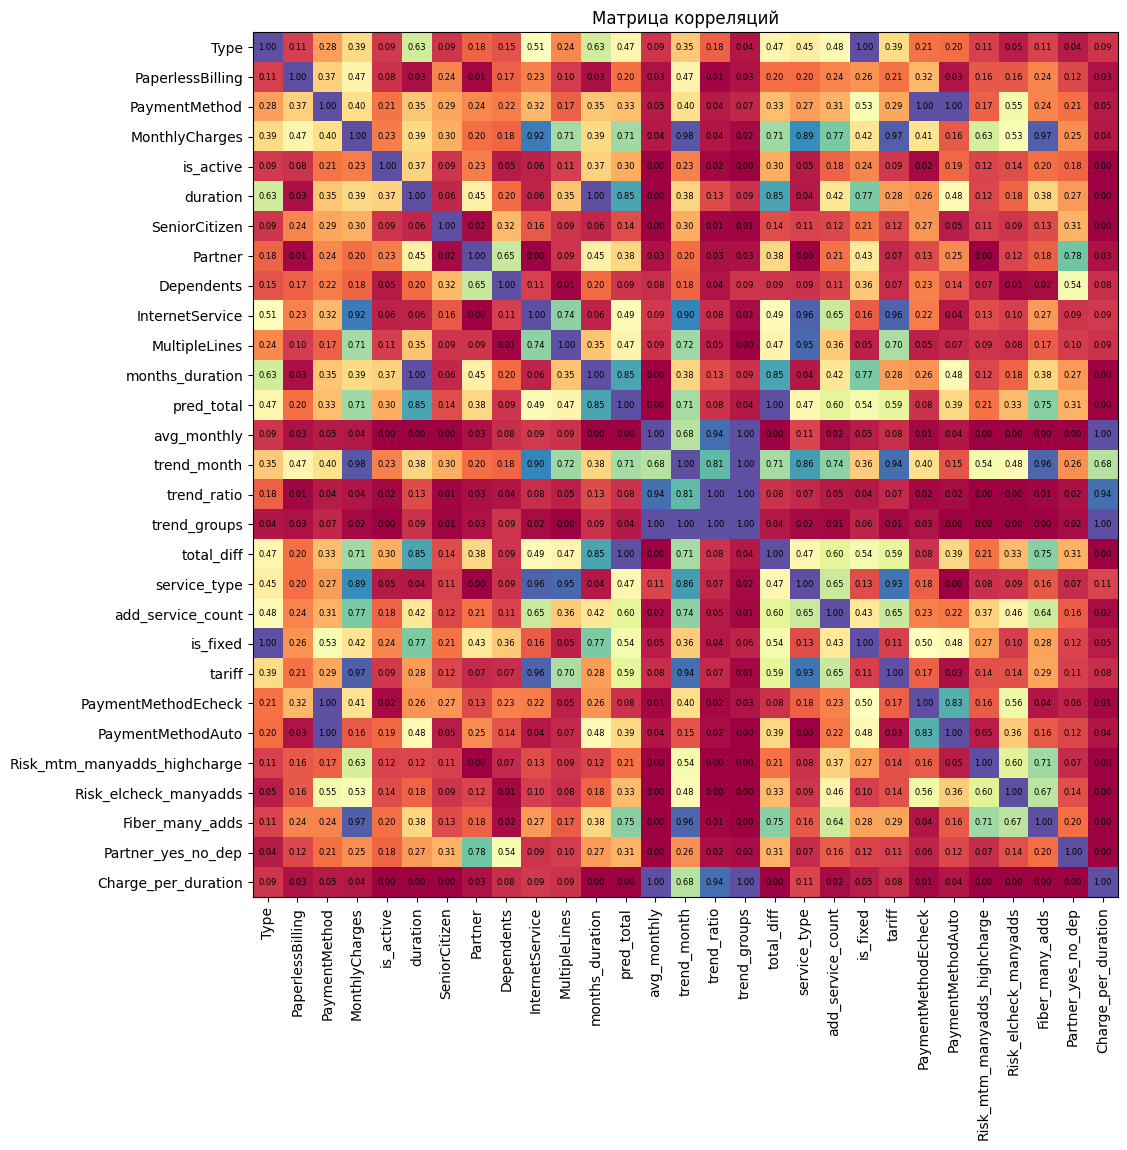

In [154]:
# зададим список колонок для передачи методу phik_matrix
# выделим непрерывные числовые признаки (исключим бинарные 0/1)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
binary_num = [c for c in num_cols if df[c].dropna().nunique() == 2]
interval_cols = [c for c in num_cols if c not in binary_num]

# подсчитаем phik 
phi_k = df.phik_matrix(interval_cols=interval_cols)   

# визуализируем тепловую карту phik 
fig_w = max(5, 0.4 * len(phi_k.columns))
fig_h = max(5, 0.4 * len(phi_k.index))

plt.figure(figsize=(fig_w, fig_h))
im = plt.imshow(phi_k.values, vmin=0, vmax=1, cmap='Spectral', interpolation='nearest')
plt.title('Матрица корреляций')

plt.xticks(ticks=np.arange(len(phi_k.columns)), labels=phi_k.columns, rotation=90)
plt.yticks(ticks=np.arange(len(phi_k.index)), labels=phi_k.index)

for i in range(len(phi_k.index)):
    for j in range(len(phi_k.columns)):
        value = phi_k.values[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.2f}", ha='center', va='center', color='black', fontsize=6)
            
plt.tight_layout()
plt.show()

Проверим итоговую таблицу на дубликаты.

In [156]:
# проверим итоговую таблицу на полные дубликаты
check_duplicates(df, data_name="df")

# удалим дубликаты
df = df.drop_duplicates()

# проверим, что все дубликаты удалены
check_duplicates(df, data_name="df")

# выведем размер датасета
print(f"Размер датасета после удаления дубликатов: {df.shape}")

Количество полных дубликатов в df: 13
Количество полных дубликатов в df: 0
Размер датасета после удаления дубликатов: (7030, 29)


## Подготовка данных

Разделим данные на тренировочную и тестовую выборки. Стратифицируем по таргету, учтем дисбалланс в классах таргета `is_active`(84.37% - договор действует/ 15.63% - договор действует).

In [159]:
# выделим таргет и признаки 
y = df['is_active']
X = df.drop(columns=['is_active'])

# проверим размер y, X
print(f"размер X:{X.shape}, размер y: {y.shape}")

размер X:(7030, 28), размер y: (7030,)


In [160]:
# разделим данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

#вывем размер тренировочной и тестовой выборок
print(f"размер X_train:{X_train.shape} \nразмер y_train:{y_train.shape}\nразмер X_test:{X_test.shape}\nразмер y_test{y_test.shape}")

размер X_train:(5272, 28) 
размер y_train:(5272,)
размер X_test:(1758, 28)
размер y_test(1758,)


Создадим препроцессор для масштабирования и кодирования признаков. 

В нашем датасете есть признаки категориальные и числовые признаки.

1. **Категориальные признаки:**
   - `Type` - (`Month-to-month`, `One year`, `Two year`)
   - `PaperlessBilling` - (`Yes`/`No`)
   - `PaymentMethod` - (`Electronic check`, `Mailed check`, `Bank transfer (automatic)`, `Credit card (automatic)`)
   - `Partner` -  (`Yes`/`No`)
   - `Dependents` - (`Yes`/`No`)
   - `InternetService` - (`DSL`, `Fiber optic`, `No internet service`)
   - `service_type` - (`internet_only`, `phone_only`, `both`)
     
2. **Количественные признаки**:
   
**Непрерывные+**: 
   - `MonthlyCharges` — непрерывный
   - `duration` — длительность (целочисленный, непрерывный)
   - `add_service_count` — (значения 0-6)
   - `Charge_per_duration`— непрерывный
     
**Бинарные(0/1)**: 
   - `SeniorCitizen`
   - `Risk_mtm_manyadds_highcharge`
   - `Risk_elcheck_manyadds`
   - `Fiber_many_adds`
   - `Partner_yes_no_dep`

**Как будем масштабировать и кодировать признаки:**

**Количественные признаки**:
- для создания модели будет использовать `CatBoost` и `RandomForest`, поэтому кодирование количественных признаков не требуется

**Категориальные признаки:**
- для **CatBoost** кодировать качественные признаки не требуется, просто передадим список категориальных признаков
- для **RandomForest** используем `OHE`(OneHotEncoder)

Масштабировать признаки для `CatBoost` и `RandomForest` не требуется.

In [162]:
# соберем категориальные и количественные признаки для передачи моделям 
cat_cols = [
    'Type', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Partner',
    'Dependents', 'InternetService', 'MultipleLines', 'trend_groups',
    'service_type', 'is_fixed', 'tariff', 'PaymentMethodEcheck',
    'PaymentMethodAuto', 'Risk_mtm_manyadds_highcharge',
    'Risk_elcheck_manyadds', 'Fiber_many_adds', 'Partner_yes_no_dep'
]

num_cols = [
    'MonthlyCharges', 'duration', 'pred_total', 'avg_monthly',
    'trend_month', 'trend_ratio', 'total_diff', 'add_service_count',
    'Charge_per_duration'
]

# выведем на экран списки фичей 
print(f"Список категориальных признаков для передачи моделям: {cat_cols}")
print(f"\nСписок количественных признаков для передачи моделям: {num_cols}")

# создадим cv
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Список категориальных признаков для передачи моделям: ['Type', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'MultipleLines', 'trend_groups', 'service_type', 'is_fixed', 'tariff', 'PaymentMethodEcheck', 'PaymentMethodAuto', 'Risk_mtm_manyadds_highcharge', 'Risk_elcheck_manyadds', 'Fiber_many_adds', 'Partner_yes_no_dep']

Список количественных признаков для передачи моделям: ['MonthlyCharges', 'duration', 'pred_total', 'avg_monthly', 'trend_month', 'trend_ratio', 'total_diff', 'add_service_count', 'Charge_per_duration']


## Обучение моделей машинного обучения

В нашем проекте мы решаем задачу бинарной классификации - предсказания значения тагрета `is_active`(0-разговор растогнут, 1-договор действует). Для создания модели для прогноза оттока клиентов оператора свази «ТелеДом» мы будем использовать `CatBoost` и `RandomForest`. Для оценки модели будет использовать метрику `accuracy`. По требованию заказчика `accuracy` на тестовой выборке должна быть не менее `0.85`.

Для подбора гиперпараметров будем использовать `RandomizedSearchCV`.

Как базлайн будем использовать `Dummy Regressor` со стратегией `mean`.

### Модель RandomForest

Random Forest устойчив к выбросам и линейной зависимости между признаками, хорошо справляется со сложными нелинейными зависимостями.

Перед передачей модели закодируем категориальные признаки с помощью `OHE`(OneHotEncoder).

In [167]:
# соберем препроцессор для RandomForest
preproc_rf = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
        ("num", "passthrough", num_cols),  
    ],
    remainder="drop"
)

# инициализируем модель
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight=None
)

# соберем пайплайн
rf_pipe = Pipeline([
    ("prep", preproc_rf),
    ("rf", rf)
])

# зададим гиперпараметры
param_dist_rf = {
    "rf__n_estimators": [1000],
    "rf__max_depth": [5,10],
    "rf__min_samples_split": [4,5],
    "rf__min_samples_leaf": [1,2],
    "rf__max_features": [None]
}
# соберем метрики, которые хотим проверить
scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist_rf,
    n_iter=8,                
    scoring=scoring,
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    refit="accuracy"
)

t0 = time.perf_counter()
random_search_rf.fit(X_train, y_train)
t_rf_search = time.perf_counter() - t0

print(f"\nRandomizedSearchCV fit time: {t_rf_search:.2f} s")
print("\nRandomForest: лучшие параметры на кросс-валидации")
print(random_search_rf.best_params_)
print("Лучший accuracy на кросс-валидации:", round(random_search_rf.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits

RandomizedSearchCV fit time: 47.09 s

RandomForest: лучшие параметры на кросс-валидации
{'rf__n_estimators': 1000, 'rf__min_samples_split': 4, 'rf__min_samples_leaf': 1, 'rf__max_features': None, 'rf__max_depth': 10}
Лучший accuracy на кросс-валидации: 0.8813


### Модель CatBoost

In [169]:
# модель
cb = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    verbose=False,
    auto_class_weights=None  
)

# гиперпараметры для CatBoost
param_dist_cb = {
    "depth": [3, 4],                     
    "learning_rate": [0.1, 0.2],    
    "iterations": [1400],        
    "l2_leaf_reg": [3, 5]             
}

# подсчитаем оптимальное кол-во итераций 
n_candidates = (
    len(param_dist_cb["depth"])
    * len(param_dist_cb["learning_rate"])
    * len(param_dist_cb["iterations"])
    * len(param_dist_cb["l2_leaf_reg"])
)
# зададим дипазон для n_iter, желаемым поставим 80
n_iter = min(80, n_candidates)

random_search_cb = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_dist_cb,
    n_iter=n_iter,
    scoring="accuracy",  
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True
)

random_search_cb.fit(X_train, y_train, **{"cat_features": cat_cols})

print("CatBoost: лучшие параметры на кросс-валидации")
print(random_search_cb.best_params_)
print("Лучший accuracy:", round(random_search_cb.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
CatBoost: лучшие параметры на кросс-валидации
{'learning_rate': 0.2, 'l2_leaf_reg': 3, 'iterations': 1400, 'depth': 4}
Лучший accuracy: 0.9165


**Вывод на основе обучения моделей** 

Для создания модели для прогноза оттока клиентов оператора свази «ТелеДом» мы будем использовать `CatBoost` и `RandomForest`. Для оценки модели использовали метрику `accuracy`. 
Для подбора гиперпараметров будем использовать `RandomizedSearchCV`.

На кросс-валидации на трейне лучший результат показал `CatBoost`. 

**Результаты моделей:** 
 - `CatBoost` - `accuracy`: 0.9122
 - `RandomForestClassifier` - `accuracy`: 0.8811
 
**лучшая модель `CatBoost` на кросс-валидации с гиперпараметрами** 
- шаг градиентного бустинга -`learning_rate`:  0.2
- регуляризация - `l2_leaf_reg`: 3
- кол-во итераций `iterations`: 1400
- глубина `depth`: 3

Сделаем предсказания на тестовой выборке.  

In [172]:
# предсказания на тестовой выборке
best_model = random_search_cb.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # вероятность положительного класса

# метрики
test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

print(f"accuracy на тесте: {test_acc:.4f}")
print(f"roc_auc на тесте: {test_auc:.4f}")

accuracy на тесте: 0.9135
roc_auc на тесте: 0.9170


На тесте модель `CatBoost` выбила `accuracy` - `0.9283`(на кросс валидации на трейне - `0.9122`). 
`roc_auc` на тесте - `0.9290`

oтчет:

              precision    recall  f1-score   support

           0       0.85      0.54      0.66       275
           1       0.92      0.98      0.95      1483

    accuracy                           0.91      1758
   macro avg       0.89      0.76      0.81      1758
weighted avg       0.91      0.91      0.91      1758



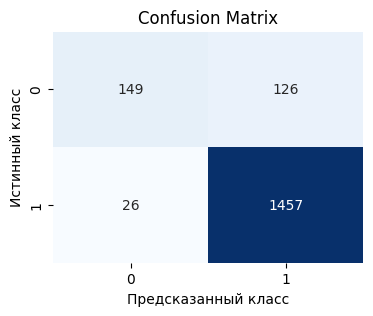

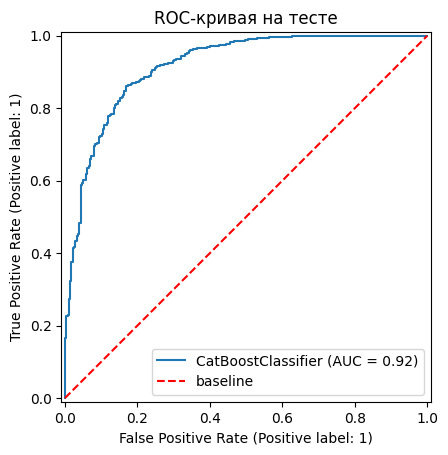

In [174]:
print("oтчет:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix")
plt.show()

# ROC кривая 
RocCurveDisplay.from_estimator(best_model, X_test, y_test)

# baseline
plt.plot([0, 1], [0, 1], "r--", label="baseline")

plt.title("ROC-кривая на тесте")
plt.legend()
plt.show()

Проанализируем важность признаков

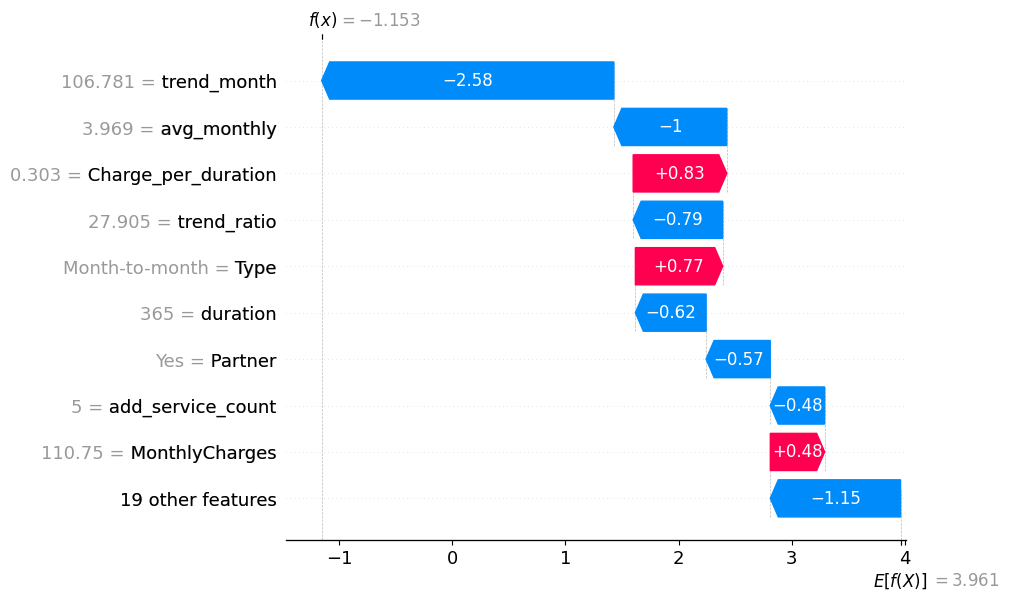

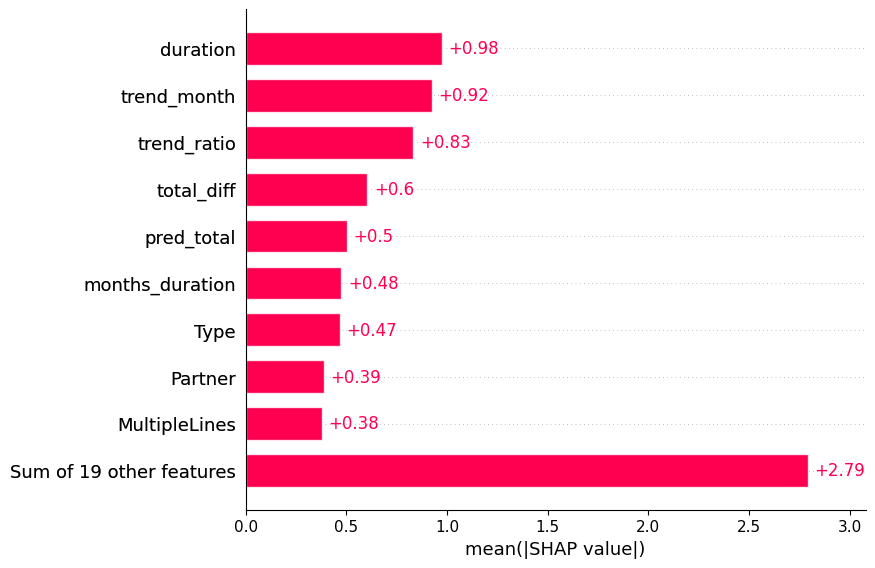

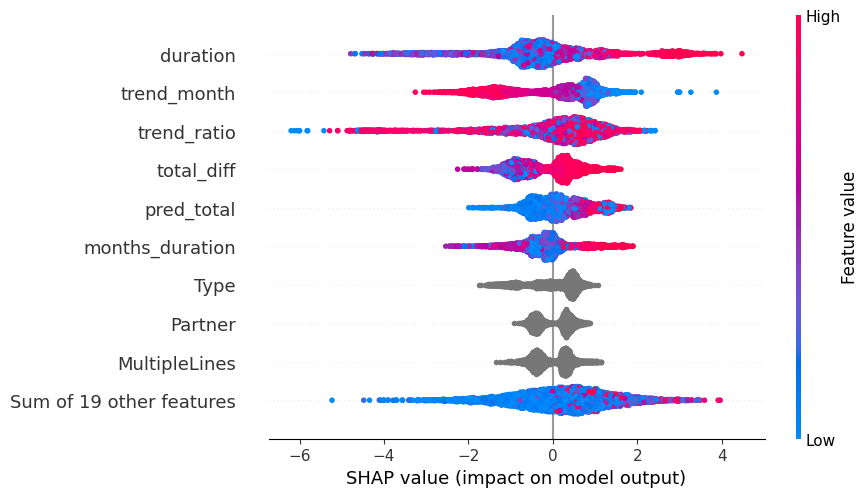

In [176]:
best_model = random_search_cb.best_estimator_

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_train)

# локальная интерпретация одной записи
shap.plots.waterfall(shap_values[0])

# глобальная интерпретация (важность признаков)
shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

**Вывод на основе важности признаков:**

Модель в основном опирается на признаки, связанные с длительностью договора и платежами:

**`duration`** - длительность договора в днях - самый важный признак. 
- чем дольше клиент остается, тем меньше вероятность оттока
 
**`trend_ratio`** - отношения `MonthlyCharges` к `avg_monthly`(средний ежемесячный платеж)
- высокие значения  — усиливают предсказание `договор активен`. Низкие значения — увеличивают риск оттока.

**`MonthlyCharges`** - ежемесячный платеж
- высокие платежи чаще смещают в сторону завершения договора

**`trend_month`** - отклонение среднего месячного платежа от текущего месячного платежа(`MonthlyCharges` - `avg_monthly`)
- большие положительные отклонения сильно влияют на предсказания. Заметные изменения - сигнал риска расторжения

**`pred_total`** - предсказанные общие платежи (`MonthlyCharges`*`duration`)
- большие накопленные расходы - снижают риск расторжения контракта

**`Partner`** - наличие партнера
- отсутствие партнера увеличивает риск расторжения контракта

**`avg_monthly`** - средний месячный платеж(`TotalCharges_new`/`duration`)
- высокие значения увеличивают риск расторжения 

**`Charge_per_duration`** - отношение `MonthlyCharges` к `duration` - как меняются ежемесячные платежи в зависимости от длительности договора
- высокие значения увеличивают риск расторжения 

**`is_fixed`** - годовой и двухлетний контракт
- фиксированные тариф снижает риск расторжения контракта

**Вывод о качестве модели на основе матрицы ошибок**

В рамках исследования нам необходимо обучить модель, которая позволит бизнесу избежать финансовых потерь и оттока абонентов. Удержание клиента - это тоже расходы. У нас нет данных, что обойдется дороже:  бонусы и скидки, чтобы удержать клиента или финасовые потери из-за расторжения договора.  Поэтому двигать трешхолд мы не будем. Оценим результаты модели с базовым трешхолдом 0.5

Лучшая модель с дефолтным трешхолдом 0.5 показывает результаты:
  - **Верные предсказания**
   
`TN`(договор завершен/договор завершен) - `168`

`TP`(действующий договор/действующий договор) - `1464`

 - **Ошибки в предсказаниях**
   
`FP`(действующий договор/договор завершен) - `107`

`FN`(договор завершен/действующий договор) - `19`

- модель сделала 126 ошибок на тестовой выборке размером 1758 наблюдений
- чаще всего модель совершает ошибки 1 рода(`FP`- `107`) - модель пропустила клиентов, которые расторгли договор. Это чревато потерями для бизнеса
- ошибок второго рода меньше(`FN`- `19`) - модель маркирует активного клиента как клиента который расторг договор. Бизнес будет зря тратиться на удержание
- из всех договоров, которые завершены, модель предсказала только `61%.`

Обучим и протестируем `DummyClassifier`, чтобы точно оценить, лучше ли наша модель бейзлайна. Выберем стратегию `stratified` - моделька будет предсказывать по распределению классов.

In [179]:
# "обучим" и протестируем `DummyClassifier`

# инициализируем модель
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)

# обучим на трейне
dummy.fit(X_train, y_train)

# сделаем предсказания на тесте
y_pred = dummy.predict(X_test)
y_proba = dummy.predict_proba(X_test)[:, 1]

# выведем метрики
print(f"accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"roc_auc: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred, digits=4))

accuracy: 0.7184
roc_auc: 0.4895
              precision    recall  f1-score   support

           0     0.1405    0.1564    0.1480       275
           1     0.8402    0.8227    0.8313      1483

    accuracy                         0.7184      1758
   macro avg     0.4904    0.4895    0.4897      1758
weighted avg     0.7308    0.7184    0.7245      1758



у `DummyClassifier` со стратегией `stratified`:

- `accuracy на тесте:` у `DummyClassifier` - 0.7270 /у `CatBoost` - 0.9283
- `roc_auc на тесте:` у `DummyClassifier` - 0.4812 / у `CatBoost` - 0.9290

Хотя `accuracy` у модели `CatBoost` всего на 0.14 выше, но `roc_auc` у `DummyClassifier` - даже хуже случайного предсказания. В нашем случае `accuracy` у безлайновой модели лучши лишь из-за сильного дисбаланса в классах целевой переменной `is_active`.

Вывод: обученная модель `CatBoost` заметно лучше `DummyClassifier`.

После обучения модели подсчитаем веротяности ухода для клиентов(насколько модель «уверена», что клиент расторгнет договор). Выделим группу риска: отсортируем абонентов по вероятности ухода и возьмем топ-10%. Визуализируем распределение клиентов из зоны риска.

In [182]:
# соберем данные для анализа ушедших клиентов
df_test = X_test.copy()
df_test["is_active"] = y_test
best_model = best_model
feature_columns = X_test.columns.tolist()

# проверим 
print(f"Размер X_test:, {X_test.shape}, Размер y_test:, {y_test.shape}")
print("Размер df_test:", df_test.shape)

# для удобства заменим таргет на churn: 1 = расторг (ушел), 0 = остался
y_true_churn = 1 - df_test["is_active"].astype(int).to_numpy()

# предскажем веротяности для классов 
proba_matrix = best_model.predict_proba(df_test[feature_columns])

# соберем все признаки с индексом класса "1" (ушел)
idx_positive = list(best_model.classes_).index(1)

# добавим в df_test вероятность churn
df_test["proba_churn"] = proba_matrix[:, idx_positive]

# выведем таблицу с данными и веротяностями
col=["proba_churn", "is_active"]
df_test[col].head()

Размер X_test:, (1758, 28), Размер y_test:, (1758,)
Размер df_test: (1758, 29)


,proba_churn,is_active
6174,0.976,1
3031,0.393,0
6664,0.415,1
4575,1.000,1
3979,0.999,1


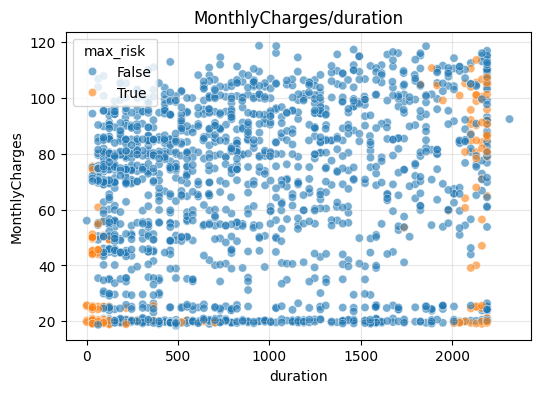

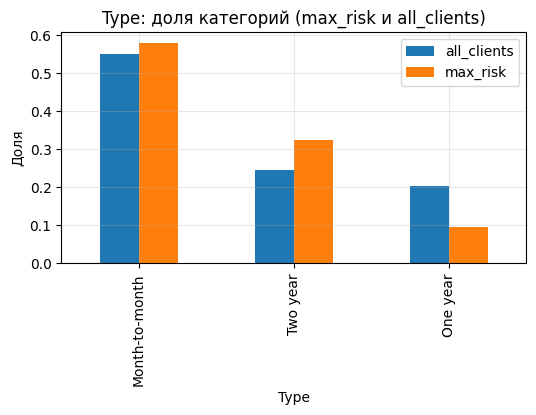

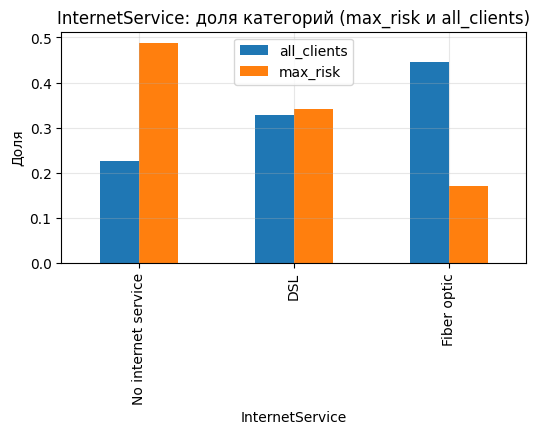

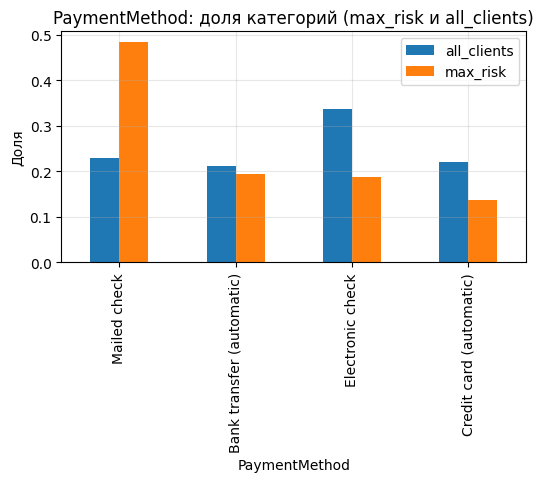

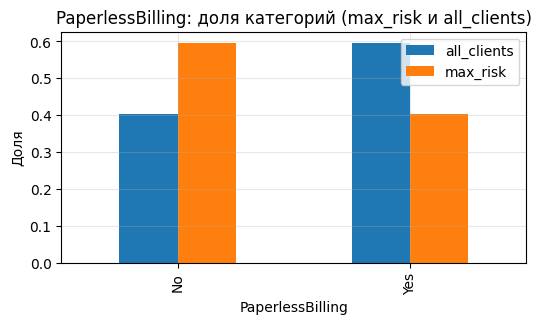

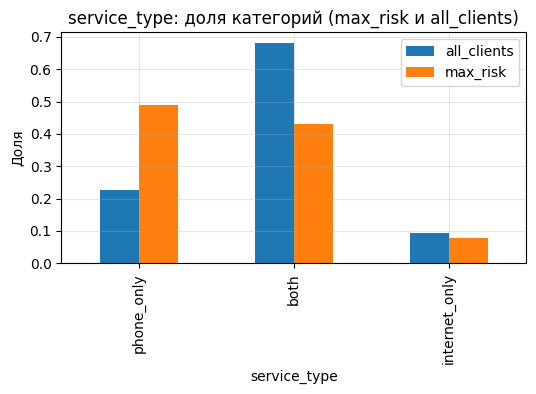

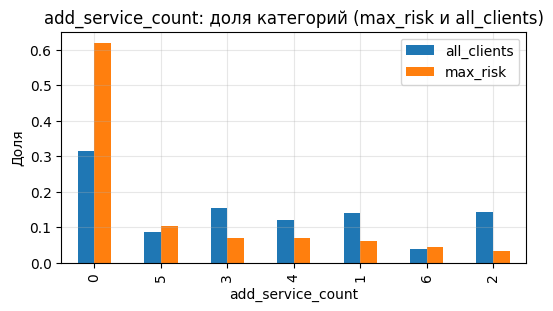

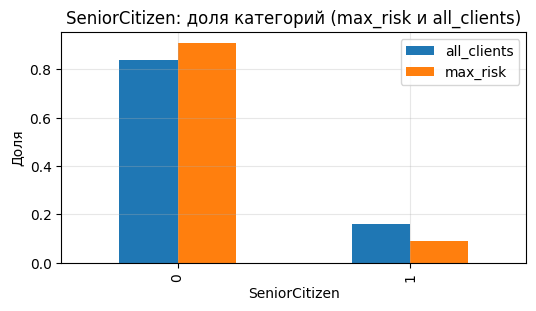

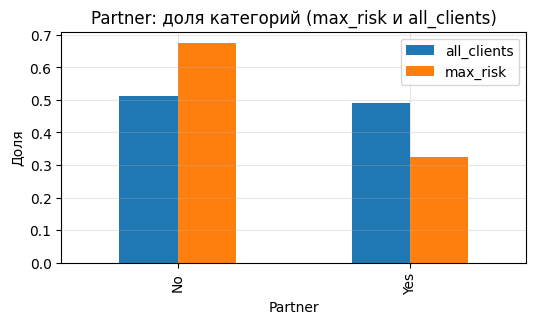

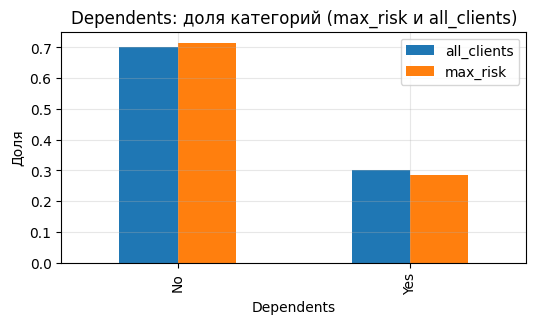

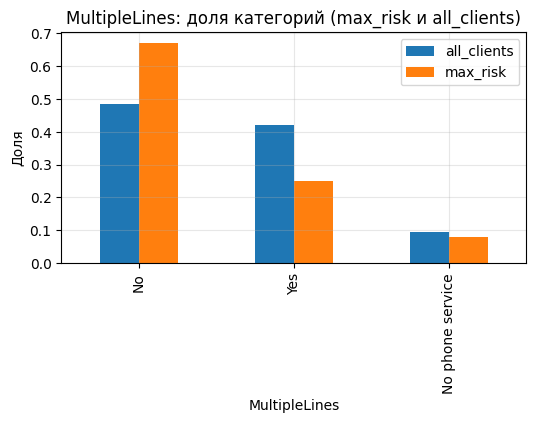

In [183]:
# зададим отсечку для группы риска - 10%  по риску ухода
k = 0.10  
threshold_top = df_test["proba_churn"].quantile(1 - k)
df_top = df_test[df_test["proba_churn"] >= threshold_top].copy()  

# построим scatterplot для MonthlyCharges/duration + max_risk
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_test, x="duration", y="MonthlyCharges",
                hue=df_test["proba_churn"] >= threshold_top, alpha=0.6)
plt.title("MonthlyCharges/duration")
plt.xlabel("duration")
plt.ylabel("MonthlyCharges")
plt.grid(True, alpha=0.3)
plt.legend(title="max_risk")
plt.show()

# визуализируем распределение в группе максимального риска и во всей выборке
cat_cols = ["Type", "InternetService", "PaymentMethod", "PaperlessBilling", 
            "service_type", "add_service_count", "SeniorCitizen", 
            "Partner", "Dependents", "MultipleLines"
           ]  
mask_top = df_test["proba_churn"] >= threshold_top

for c in cat_cols:
    comp = cat_share_compare(df_test, c, mask_top)
    comp.plot(kind="bar", figsize=(6,3))
    plt.title(f"{c}: доля категорий (max_risk и all_clients)")
    plt.ylabel("Доля")
    plt.grid(True, alpha=0.3)
    plt.show()

# Общий вывод

 1. **Цель проекта**

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. В ходе проекта мы обучим на этих данных модель для прогноза оттока клиентов.
 
2. **Информация об исходных данных и проведенной предобработки**

   **Поведение абонентов анализировали, основываясь на предоставленных табличных данных**:

- информация о договоре
- персональные данные клиента
- информация об интернет-услугах
- информация об услугах телефонии

   **В ходе предобработки данных и EDA**:
   
- проверили датафреймы на пропуски
- проверили корректность типов данных в датафреймах
- нашли "невидимые строки"(содержащие пробелы) в признаке `TotalCharges`, а затем привели признак к корректному типу данных `float`
- привели к типу данных datetime признаки `EndDate` и `BeginDate`
- выделили целевой признак `is_active` (1-договор активен, 0-договор завершен)
- разработали логику заполнения пропусков в `EndDate`, образовавшихся после приведения признака к типу datetime. Использовали для заполнения пропусков дату среза(информация о договорах актуальна на 1 февраля 2020 года)
- разработали логику заполнения пропусков образовавших после объединения таблиц
- изучили распределение признаков 
- создали новые фичи, чтобы учесть зависимости между признаками
- 
   **В ходе подготовки данных к использованию в обучении модели**:

 - кодировали категориальные признаки с помощью `OneHotEncoder` 
 - масшатбировали числовые признаки с помощью `StandardScaler` 

3. **Для поиска лучшей модели для предсказания оттока абонентов использовали**:
- `RandomForestClassifier`
- `Catboost`
    
В ходе поиска лучшей модели использовали пайплайн, а также `RandomizedSearchCV` с кросс-валидацией (`cv=5`) и метрикой `accuracy` 

С предсказанием признака `is_active`(завершен договор или действует) лучше всего справилась модель `Catboost`. 

- на кросс-валидации на трейне `Catboost`добилась `accuracy` - `0.9122`. 

- на тесте модель показала `accuracy` - `0.9283`, `roc_auc` - `0.9290`). 

**Лучшая модель `CatBoost` на кросс-валидации с гиперпараметрами** 
- шаг градиентного бустинга -`learning_rate`:  0.2
- регуляризация - `l2_leaf_reg`: 3
- кол-во итераций `iterations`: 1400
- глубина `depth`: 3

**Сравнение с бейзлайном(`DummyClassifier`)**

`roc_auc` `Catboost` почти в 2 раза лучше, результата `DummyClassifier`

**Оценка модели `CatBoost`:

- модель сделала 126 ошибок на тестовой выборке размером 1758 наблюдений
- чаще всего модель совершает ошибки 1 рода(`FP`- 107) - модель пропустила клиентов, которые расторгли договор. Это чревато потерями для бизнеса
- ошибок второго рода меньше(`FN`- 19) - модель маркирует активного клиента как клиента который расторг договор. Бизнес будет зря тратиться на удержание
- из всех договоров, которые завершены, модель предсказала только 61%.

**Ключевыми признаками для предсказания ухода абонента стали признаки связанные с длительностью и платежами:**

**`duration`** - длительность договора в днях - самый важный признак. 
- чем дольше клиент остается, тем меньше вероятность оттока
 
**`trend_ratio`** - отношения `MonthlyCharges` к `avg_monthly`(средний месячный платеж)
- высокие значения — усиливают предсказание `договор активен`. Низкие значения — увеличивают риск оттока.

**`MonthlyCharges`** - ежемесячный платеж
- высокие платежи чаще смещают прогноз в сторону завершения договора

**`trend_month`** - отклонение среднего месячного платежа от текущего месячного платежа(`MonthlyCharges` - `avg_monthly`)
- большие положительные отклонения сильно влияют на предсказания. Заметные изменения - сигнал риска расторжения

**`pred_total`** - предсказанные общие платежи (`MonthlyCharges`*`duration`)
- большие накопленные расходы - снижают риск расторжения контракта

**`Partner`** - наличие партнера
- отсутствие партнера увеличивает риск расторжения контракта

**`avg_monthly`** - средний месячный платеж(`TotalCharges_new`/`duration`)
- высокие значения увеличивают риск расторжения 

**`Charge_per_duration`** - отношение `MonthlyCharges` к `duration` - как меняются ежемесячные платежи в зависимости от длительности договора
- высокие значения увеличивают риск расторжения 

**`is_fixed`** - годовой и двухлетний контракт
- фиксированные тариф снижает риск расторжения контракта


5. **Выводы**

В зоне риска находятся абоненты, похожие на "типичного ушедшего".

**Портрет абонента из группы риска(высокая веротяность расторгнуть договор)**

- в зоне риска клиента с контрактом `Month-to-month`
- есть партнер, но нет детей
- есть статус пенсионера
- 
**проблемные признаки**:
- тип контракта `Month-to-month`
- способ оплаты `Electronic check`
- `Fiber optic` с большим кол-вом подключенных интернет-услуг (высокие платежи/возможно ненужные услуги)
- есть партнер, но нет детей
- есть статус пенсионера
- тип услуг `DSL` 
- риск расторжения вышу у абонента с договором без доп услуг (клиента не смогли вовлечь)
- высокий `MonthlyCharges` и высокий `TotalCharges`

**Наиболее высокий риск расторжения договора у групп абонентов**:
- `Month-to-month` + много доп услуг (>=4) + высокий `MonthlyCharges`
- `Electronic check` + много доп услуг
- `Fiber optic` + много доп услуг
- `SeniorCitizen` + высокий `MonthlyCharges`
- `Partner == Yes` + `Dependents == No`

**Причины расторжения контракта:**
   
Можно предположить, что чаще всего контракт расторгают по двум основным причинам:
- оператор связи «ТелеДом» не смог удержать клиента(`Month-to-month`, `DSL`, нет доп интернет-услуг, базовая телефония, низкие/средние платежи)
- клиент уходит из-за высоких счетов/слишком большого кол-ва включенных в тариф опций(`Month-to-month` + `Fiber optic` + `Electronic check` + много доп услуг = высокий `MonthlyCharges`)

**Когда абоненты чаще всего расторгают договор:**
- часть абонентов уходит быстро, в первые месяцы после подключения(пик расторжений договора в диапазоне 0–10 мес)
- часто уходят "старые" клиенты с дительностью договора 40–60+ месяцев. У них высокие `TotalCharges` и много доп услуг

**Рекомендации оператору связи (как удержать абонентов):**
----

1. **Смена контракта:**
- переводить клиентов на более долгие договоры(у договоров с `Month-to-month` высокий риск расторжения). При отказе от длительного договора - предложить договор на 1–2 месяца со скидкой. Особенно обращать внимание на снижение расходов, отказ от доп услуг/отсутствие доп услуг.
  
2. **Тарифные пакеты:**

- для клиентов с 4+ доп-услугами и высокими `MonthlyCharges` предлагать скидку на пакеты услуг и переход на `PaperlessBilling` с возможностью контролировать траты. Оптимально внедрить мониторинг трафика, чтобы пользователь получал сообщение о большом расходе трафика(нетипичном/или по лимиту заданному самим пользователем). Оптимально, дать пользователю возможность контролировать потребление и отключить лишние опции в приложении
   
3. **Способ оплаты:**

- предлагать альтернативы `Mailed check` и `Electronic check`. Сделать бонус/скидку за переход на автоплатежи. Оплату стоит сделать максимально комфортной(приложение=расшифровка всех трат, контроль за трафиком, балансом и тд)

4. **Тип интернет подключения:**

- перевод клментов с `DSL` на `Fiber Optic`. При переходе предлагать пакеты доп сервисов со скидкой, чтобы повысить удовлетворенность клиентов качеством услуги + предлагать пакеты с медиа, чтобы оценили преимущества `Fiber optic`

5. **Стационарный телефон:**

- для вовлечения абонентов предлагать подключить интернет со скидкой + бесплатная техподдержка(особенно для абонентов в возрасте) 

6. **Поддержка новых клиентов:**

- для группы риска расторжения в первые 0–10 мес — роутер в подарок, техподдержка, настройка роутера, пакет медиа сервисов (для вовлечения)

7. **Поддержка старых клиентов:**

- для группы риска (договор > 65 месяцев) большие скидки за лояльность, бесплатные опции(техподдержка, сервисы защиты). Доступ к новым функциям в числе первых, уникальные предложения доступные только этой группе пользователей

8. **Взаимодействие с соц группами:** Для клиентов без партнера, но с детьми(`Dependents`)предложить большую скидку на стриминговые сервисы